### EOF analysis (on train only data)

In [ ]:
#!/usr/bin/env python3
# ============================================================
# Combined EOF Analysis for CMIP6 ocean variables in (lat,depth)
# at fixed longitudes, INCLUDING South + North Atlantic
#
# EOFs fit on TRAIN only; PCs are projected for FULL period.
# ============================================================

import os
import glob
import re
import numpy as np
import xarray as xr
from eofs.standard import Eof
import warnings
warnings.filterwarnings("ignore")

# Prevent HDF5 file locking issues on shared filesystems
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# CONFIG
# ============================================================
MODEL   = "IPSL-CM6A-LR"      # EC-Earth3, IPSL-CM6A-LR, CESM2, MPI-ESM1-2-LR
VAR     = "so"             # thetao or so
NMODES  = 10

START_YEAR = 1850
END_YEAR   = 2014

TARGET_LONS   = [-10.0, -20.0, -30.0, -40.0, -60.0]
LON_WINDOW    = 10.0       # degrees
DEPTH_RANGE_M = (0.0, 5000.0)

# >>> NEW: Train fraction of the COMMON time axis (first X%)
TRAIN_FRACTION = 0.85  # choose 0.80–0.85 as you like

# ============================================================
# DIRECTORIES
# ============================================================
if MODEL == "EC-Earth3":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/{VAR}/"
elif MODEL == "IPSL-CM6A-LR":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/{VAR}/masked/"
elif MODEL == "CESM2":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/CESM2/{VAR}/masked/"
elif MODEL == "MPI-ESM1-2-LR":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/MPI-ESM1-2-LR/{VAR}/masked/"
else:
    raise ValueError("Unknown MODEL")

OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_{int(TRAIN_FRACTION*100)}pct/"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# UTILITIES
# ============================================================

def parse_member_label(path):
    m = re.search(r"_(r\d+i\d+p\d+f\d+)", os.path.basename(path))
    return m.group(1) if m else os.path.basename(path)

def wrap_lon(lon):
    return ((lon + 180) % 360) - 180

def standardize_latlon(ds):
    lat_var = next(v for v in ["lat", "latitude", "nav_lat"] if v in ds)
    lon_var = next(v for v in ["lon", "longitude", "nav_lon"] if v in ds)

    lat = ds[lat_var]
    lon = ds[lon_var]

    if lat.ndim == 1 and lon.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon.values, lat.values)
        ds = ds.drop_vars([lat_var, lon_var])
        ds = ds.rename_dims({lat.dims[0]: "y", lon.dims[0]: "x"})
        ds["lat2d"] = xr.DataArray(lat2d, dims=("y", "x"))
        ds["lon2d"] = xr.DataArray(lon2d, dims=("y", "x"))
        return ds

    ds = ds.swap_dims({lat.dims[0]: "y", lat.dims[1]: "x"})
    ds = ds.rename({lat_var: "lat2d", lon_var: "lon2d"})
    return ds

def get_depth_dim_and_coord(da, ds):
    if "olevel" in da.dims:
        return "olevel", ds["olevel"].values
    if "depth" in da.dims:
        return "depth", ds["depth"].values
    if "lev" in da.dims:
        z = ds["lev"].values
        if np.nanmax(z) > 10000:
            z = z / 100.0
        return "lev", z
    raise KeyError("No vertical coordinate found")

def compute_layer_thickness(z):
    z = np.asarray(z)
    dz = np.empty_like(z, dtype=float)
    dz[1:-1] = 0.5 * (z[2:] - z[:-2])
    dz[0]    = z[1] - z[0]
    dz[-1]   = z[-1] - z[-2]
    return np.abs(dz)

def extract_section_valid_ocean(da, ds, target_lon, depth_dim):
    lon2d = ds["lon2d"].values
    lat2d = ds["lat2d"].values

    lonW = wrap_lon(lon2d)
    tW   = wrap_lon(target_lon)

    valid_xy = np.isfinite(da).any(dim=("time", depth_dim)).values
    ny, nx = lonW.shape

    ix = np.full(ny, -1, dtype=int)

    for y in range(ny):
        cand = np.where(valid_xy[y])[0]
        if cand.size == 0:
            continue

        d = np.abs(lonW[y, cand] - tW)
        ok = d <= LON_WINDOW
        if not np.any(ok):
            continue

        cand = cand[ok]
        d    = d[ok]
        ix[y] = cand[np.argmin(d)]

    valid_row = ix >= 0

    sec = da.isel(x=xr.DataArray(np.where(valid_row, ix, 0), dims="y"))
    sec = sec.where(xr.DataArray(valid_row, dims="y"))

    lat_1d = np.where(valid_row, lat2d[np.arange(ny), ix], np.nan)

    return sec, lat_1d, valid_row

# ============================================================
# MAIN WORKFLOW
# ============================================================

def run_longitude(target_lon):

    print("\n" + "="*80)
    print(f"▶ Longitude {target_lon:.1f}° | MODEL={MODEL} | VAR={VAR}")
    print("="*80)

    files = sorted(glob.glob(os.path.join(IN_DIR, f"*{VAR}*_masked*.nc")))
    if not files:
        raise FileNotFoundError("No masked files found")

    sections = []
    member_labels = []

    lat_ref = z_ref = dz_ref = depth_dim_ref = None

    for i, f in enumerate(files, start=1):
        label = parse_member_label(f)
        member_labels.append(label)

        print(f"\n  → Member {i}/{len(files)}: {label}")

        ds = standardize_latlon(xr.open_dataset(f))
        da = ds[VAR]

        depth_dim, z = get_depth_dim_and_coord(da, ds)
        dz = compute_layer_thickness(z)

        da = da.sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31"))

        sec, lat1d, valid = extract_section_valid_ocean(
            da, ds, target_lon, depth_dim
        )

        keepz = (z >= DEPTH_RANGE_M[0]) & (z <= DEPTH_RANGE_M[1])
        sec = sec.isel({depth_dim: keepz})
        z_sel  = z[keepz]
        dz_sel = dz[keepz]

        good = np.isfinite(lat1d)
        sec = sec.isel(y=good)
        lat1d = lat1d[good]

        order = np.argsort(lat1d)
        sec = sec.isel(y=order)
        lat1d = lat1d[order]

        # anomaly over the full period; TRAIN solver will still be fit only on TRAIN time
        sec = sec - sec.mean("time")
        sec = sec.expand_dims(member=[label])
        sections.append(sec)

        if lat_ref is None:
            lat_ref = lat1d
            z_ref   = z_sel
            dz_ref  = dz_sel
            depth_dim_ref = depth_dim

        print(f"    Kept latitude rows: {lat1d.size}")

    print("\n▶ Aligning time across members")
    common_time = sections[0]["time"].values
    for s in sections[1:]:
        common_time = np.intersect1d(common_time, s["time"].values)

    # >>> NEW: ensure chronological order
    common_time = np.sort(common_time)

    combined = xr.concat([s.sel(time=common_time) for s in sections], dim="member")

    # SAFE renaming: avoid 'lat' name collision
    combined = combined.rename({
        "y": "lat_index",
        depth_dim_ref: "depth"
    })

    combined = combined.assign_coords(
        lat=("lat_index", lat_ref),
        depth=("depth", z_ref),
    )

    n_member = combined.sizes["member"]
    n_time   = combined.sizes["time"]
    n_lat    = combined.sizes["lat_index"]
    n_depth  = combined.sizes["depth"]

    # >>> NEW: define TRAIN time split on the common axis
    n_train = int(np.floor(TRAIN_FRACTION * n_time))
    n_train = max(2, min(n_train, n_time))  # safety
    train_time = combined["time"].values[:n_train]

    train_mask = np.zeros(n_time, dtype=bool)
    train_mask[:n_train] = True

    print(f"\n▶ Combined shape: member={n_member}, time={n_time}, lat={n_lat}, depth={n_depth}")
    print(f"▶ TRAIN_FRACTION={TRAIN_FRACTION} -> n_train={n_train}/{n_time} "
          f"(train end = {str(train_time[-1])})")

    # FULL data (for projection)
    data_full = combined.transpose("member", "time", "lat_index", "depth").values
    data2d_full = data_full.reshape(n_member * n_time, n_lat * n_depth)
    data2d_full = np.ma.masked_invalid(data2d_full)

    # TRAIN data (for fitting EOFs)
    combined_train = combined.sel(time=train_time)
    data_train = combined_train.transpose("member", "time", "lat_index", "depth").values
    data2d_train = data_train.reshape(n_member * n_train, n_lat * n_depth)
    data2d_train = np.ma.masked_invalid(data2d_train)

    print("▶ Computing EOF weights")
    w_lat = np.clip(np.cos(np.deg2rad(lat_ref)), 0, None)
    w2d   = np.sqrt(w_lat[:, None] * dz_ref[None, :])
    weights = w2d.reshape(n_lat * n_depth)

    print("▶ Solving EOFs on TRAIN only")
    solver = Eof(data2d_train, weights=weights)

    EOFs = solver.eofs(neofs=NMODES).reshape(NMODES, n_lat, n_depth)
    VF   = solver.varianceFraction()[:NMODES]

    # >>> NEW: project FULL period onto TRAIN EOFs
    # projectField returns (n_samples, neofs) where n_samples = n_member*n_time
    PCs_full_flat = solver.projectField(data2d_full, neofs=NMODES)
    PCs = np.asarray(PCs_full_flat).reshape(n_member, n_time, NMODES)

    tag = f"{abs(target_lon):04.1f}".replace(".", "p")
    hemi = "W" if target_lon < 0 else "E"
    outfile = os.path.join(OUT_DIR, f"EOF_latdepth_{VAR}_{hemi}{tag}.nc")

    print(f"▶ Writing {outfile}")

    xr.Dataset(
        {
            "EOF": (("mode", "lat_index", "depth"), EOFs),
            "PC":  (("member", "time", "mode"), PCs),
            "variance_fraction": (("mode",), VF),
            "train_mask": (("time",), train_mask),
        },
        coords={
            "mode": np.arange(1, NMODES + 1),
            "member": np.array(member_labels, dtype=object),
            "time": combined["time"].values,
            "lat": ("lat_index", lat_ref),
            "depth": ("depth", z_ref),
        },
        attrs={
            "MODEL": MODEL,
            "VAR": VAR,
            "TARGET_LON_DEG": target_lon,
            "LON_WINDOW_DEG": LON_WINDOW,
            "WEIGHTING": "sqrt(cos(lat) * dz)",
            "DEPTH_RANGE_M": f"{DEPTH_RANGE_M[0]}-{DEPTH_RANGE_M[1]}",
            "EOF_FIT": "TRAIN_ONLY",
            "TRAIN_FRACTION": float(TRAIN_FRACTION),
            "TRAIN_START": str(train_time[0]),
            "TRAIN_END": str(train_time[-1]),
        }
    ).to_netcdf(outfile)

    print(f"✓ Done longitude {target_lon:.1f}°")

# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    print(f"\n=== MODEL={MODEL} | VAR={VAR} ===")
    print(f"TARGET_LONS={TARGET_LONS}")
    print(f"LON_WINDOW={LON_WINDOW} deg")
    print(f"DEPTH_RANGE_M={DEPTH_RANGE_M}")
    print(f"TRAIN_FRACTION={TRAIN_FRACTION}")

    for lon in TARGET_LONS:
        run_longitude(lon)

    print("\n✅ All longitudes processed successfully.")


### Feature ranking with w, N and a tuning

In [ ]:
#!/usr/bin/env python3
"""
SIMPLE AMOC FEATURE RANKING + FINAL_FEATURES (TRAINVAL ONLY)
===========================================================
Outputs:
  - feature_ranking_trainval.csv  (all candidates ranked by |corr|)
  - final_features.csv            (top-N seeds expanded by ±W lags)

Notes:
- Uses PCs from train-only EOF basis files (PC should cover FULL period).
- Defines train/test split by TEST_FRAC (stable + simple).
- Ranking is computed on TRAINVAL ONLY (no leakage).
"""

import os
import numpy as np
import pandas as pd
import xarray as xr

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ----------------------------
# USER SETTINGS
# ----------------------------
MODEL  = "CESM2"  # "EC-Earth3", "IPSL-CM6A-LR", "CESM2", "MPI-ESM1-2-LR"
TARGET = "AMOC_45N_member"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Ranking/"
os.makedirs(OUTDIR, exist_ok=True)

VARS     = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES  = 10

YEAR_START = 1850
YEAR_END   = 2014

TEST_FRAC = 0.15
MAX_LAG_ALLOWED = 20  # lags 0..20 inclusive

# ranking standardization
STANDARDIZE_PC = True
STANDARDIZE_Y  = False

# final feature selection settings
N_SEEDS = 30     # like N in your save_tag
W       = 2      # like W in your save_tag
CAP_LAGS_PER_GROUP = 15  # cap per (var,lon,mode)

# ----------------------------
# HELPERS
# ----------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def corr_1d(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def load_pc(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    if "PC" not in ds:
        raise KeyError(f"'PC' not found in {f}. Variables: {list(ds.data_vars)}")

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))
    if "member" in PC.dims:
        PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_amoc():
    dsA = xr.open_dataset(AMOC_FILE)
    if TARGET not in dsA.data_vars:
        raise KeyError(f"Target '{TARGET}' not found. Available: {list(dsA.data_vars)}")

    am = dsA[TARGET].squeeze()
    if "member" in am.dims:
        am = am.mean("member")

    if "year" in am.dims:
        am_year = am
        if "time" in am_year.coords:
            am_year = am_year.drop_vars("time")
    else:
        years = extract_years(am["time"])
        am_year = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    dsA.close()
    am_year = am_year.astype(float).squeeze()
    if am_year.ndim != 1:
        raise ValueError(f"AMOC target not 1D after selection: shape={am_year.shape}")
    return am_year

def build_final_features_from_ranking(df_rank, n_seeds, W, max_lag_allowed, cap_lags_per_group=None):
    """
    Takes top n_seeds rows (seeds) and expands each seed lag by ±W.
    """
    df_top = df_rank.head(int(n_seeds)).copy()

    seeds = []
    for r in df_top.itertuples(index=False):
        # df_rank uses 'mode' (1-based) and 'lag'
        seeds.append((str(r.var), str(r.lon_tag), int(r.mode) - 1, int(r.lag)))

    expanded = []
    for (var, lon, m0, lag0) in seeds:
        for L in range(lag0 - int(W), lag0 + int(W) + 1):
            if L < 0:
                continue
            if max_lag_allowed is not None and L > int(max_lag_allowed):
                continue
            expanded.append((var, lon, int(m0), int(L)))

    # cap lags per (var,lon,mode)
    if cap_lags_per_group is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(cap_lags_per_group):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    expanded = sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))

    df_feats = pd.DataFrame(
        [{"var": v, "lon": lon, "mode": m0 + 1, "lag": lag} for (v, lon, m0, lag) in expanded]
    )
    return df_feats

# ----------------------------
# LOAD + ALIGN
# ----------------------------
pc_dict = {(var, lon): load_pc(var, lon, N_MODES) for var in VARS for lon in LON_TAGS}
am = load_amoc()

common_years = am["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))

common_years = np.asarray(common_years, int)
common_years.sort()
common_years = common_years[(common_years >= YEAR_START) & (common_years <= YEAR_END)]

y = am.sel(year=common_years).values.astype(float)
PC = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

T = len(common_years)
n_test = int(np.ceil(TEST_FRAC * T))
n_trainval = T - n_test

idx_tv = np.arange(0, n_trainval, dtype=int)

print(f"Years total: {common_years[0]}–{common_years[-1]} (T={T})")
print(f"Trainval:    {common_years[0]}–{common_years[n_trainval-1]} (T={n_trainval})")
print(f"Test:        {common_years[n_trainval]}–{common_years[-1]} (T={n_test})")

# ----------------------------
# RANK (TRAINVAL ONLY)
# ----------------------------
y_tv = y[idx_tv].copy()
if STANDARDIZE_Y:
    m = np.isfinite(y_tv)
    y_tv[m] = (y_tv[m] - np.nanmean(y_tv[m])) / (np.nanstd(y_tv[m]) + 1e-12)

rows = []
lags = range(0, int(MAX_LAG_ALLOWED) + 1)

for var in VARS:
    for lon in LON_TAGS:
        X = PC[(var, lon)][idx_tv, :]  # (Ttv, modes)

        if STANDARDIZE_PC:
            mu = np.nanmean(X, axis=0)
            sd = np.nanstd(X, axis=0)
            sd[sd == 0] = np.nan
            Xz = (X - mu) / sd
        else:
            Xz = X

        Ttv = Xz.shape[0]
        for lag in lags:
            if lag >= Ttv:
                continue
            t_idx = np.arange(lag, Ttv)
            p_idx = t_idx - lag
            yy = y_tv[t_idx]

            for m0 in range(N_MODES):
                pp = Xz[p_idx, m0]
                c = corr_1d(pp, yy)
                if np.isfinite(c):
                    rows.append({
                        "var": var,
                        "lon_tag": lon,
                        "mode": int(m0 + 1),
                        "lag": int(lag),
                        "corr": float(c),
                        "abs_corr": float(abs(c)),
                    })

df_rank = pd.DataFrame(rows)
if len(df_rank) == 0:
    raise RuntimeError("No correlations computed. Check NaNs / alignment / files.")

df_rank = df_rank.sort_values("abs_corr", ascending=False).reset_index(drop=True)

rank_csv = os.path.join(OUTDIR, "feature_ranking_trainval.csv")
df_rank.to_csv(rank_csv, index=False)
print(f"\n✅ Wrote ranking: {rank_csv}")

# ----------------------------
# FINAL FEATURES (top-N seeds expanded by ±W)
# ----------------------------
df_final = build_final_features_from_ranking(
    df_rank, n_seeds=N_SEEDS, W=W,
    max_lag_allowed=MAX_LAG_ALLOWED,
    cap_lags_per_group=CAP_LAGS_PER_GROUP
)

final_csv = os.path.join(OUTDIR, "final_features.csv")
df_final.to_csv(final_csv, index=False)
print(f"✅ Wrote final features: {final_csv}")
print(df_final.head(20).to_string(index=False))

Years total: 1850–2014 (T=165)
Trainval:    1850–1989 (T=140)
Test:        1990–2014 (T=25)

✅ Wrote ranking: /data/users/frekle/Final_figures/CESM2/AMOC_26N_ensmean/Ranking/feature_ranking_trainval.csv
✅ Wrote final features: /data/users/frekle/Final_figures/CESM2/AMOC_26N_ensmean/Ranking/final_features.csv
var   lon  mode  lag
 so W10p0     1    0
 so W10p0     1    1
 so W10p0     1    2
 so W10p0     1    3
 so W10p0     1    4
 so W10p0     1    5
 so W10p0     1    6
 so W10p0     1    7
 so W10p0     1    8
 so W10p0     1    9
 so W10p0     1   10
 so W10p0     1   11
 so W10p0     1   12
 so W20p0     1    0
 so W20p0     1    1
 so W20p0     1    2
 so W20p0     1    3
 so W20p0     1    4
 so W20p0     1    5
 so W20p0     1    6


PRE ends at: 1989
PRE: 1850 - 1989
POST: 1990 - 2014
✅ Saved ranking
Best alpha (POST CV): 60.0

Top spikes (POST):
n=  2  ΔR²=+0.160  R²=0.582  | feature: var=so, lon=W60p0, mode=1, lag=2
n=  3  ΔR²=+0.059  R²=0.640  | feature: var=so, lon=W60p0, mode=1, lag=8
n=  9  ΔR²=+0.033  R²=0.745  | feature: var=thetao, lon=W10p0, mode=2, lag=18
n= 17  ΔR²=+0.028  R²=0.828  | feature: var=thetao, lon=W40p0, mode=3, lag=0
n= 14  ΔR²=+0.026  R²=0.785  | feature: var=thetao, lon=W10p0, mode=2, lag=19
n=  4  ΔR²=+0.024  R²=0.664  | feature: var=so, lon=W60p0, mode=1, lag=6
n=  5  ΔR²=+0.022  R²=0.686  | feature: var=thetao, lon=W10p0, mode=2, lag=16
n=  8  ΔR²=+0.019  R²=0.712  | feature: var=so, lon=W60p0, mode=1, lag=3
n= 27  ΔR²=+0.017  R²=0.893  | feature: var=thetao, lon=W10p0, mode=2, lag=20
n= 22  ΔR²=+0.015  R²=0.858  | feature: var=so, lon=W30p0, mode=1, lag=4


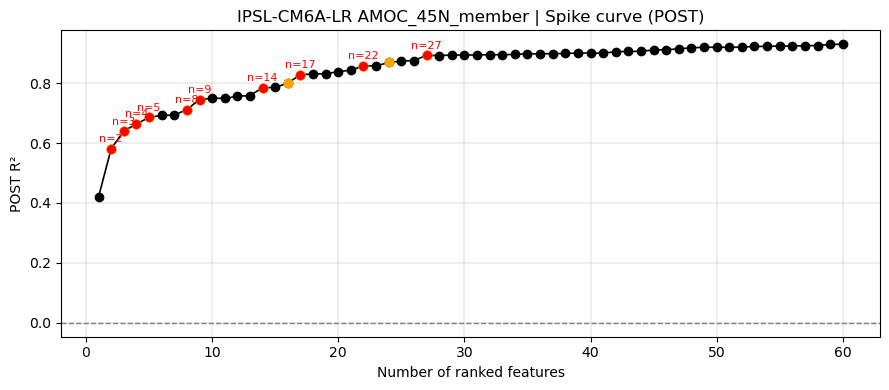

In [ ]:
#!/usr/bin/env python3
"""
MASTER WORKFLOW (MODEL-GENERIC)
===============================
Produces, in ONE consistent run per model:

(1) feature_ranking_pre.csv
    - correlation ranking computed on PRE period only (no post leakage)

(2) final_features.csv
    - top-N_seeds from ranking expanded by ±W lags (for your "broad" feature set if you want it)

(3) spike_curve_post.csv + spike_plot + spikes_top10.txt + spike_features.csv
    - spike curve computed on POST period (target regime)
    - alpha chosen by TimeSeriesSplit CV *within POST* for a chosen n_for_alpha
    - spikes extracted based on ΔR² threshold

Notes / Philosophy:
- PRE = baseline period (default ends at TRAIN_END_YEAR from EOF attrs)
- POST = target regime (years > TRAIN_END_YEAR)
- Ranking is PRE-only (rank on pre, select on post)
- Spike curve is POST-only (your "find post-1990 describing features" goal)

After this script, you can run your reconstruction step (we’ll do next):
- For k=1..5 spike features, choose alpha by CV on POST, fit on POST-train folds, evaluate on POST-val folds, then fit full POST and save predictions.

Requires:
- EOF_latdepth_{var}_{lon}.nc files with PC variable covering full period
- AMOC_{MODEL}.nc with variable TARGET

"""

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# USER SETTINGS
# ============================================================
MODEL   = "IPSL-CM6A-LR"  # "EC-Earth3", "IPSL-CM6A-LR", "CESM2", "MPI-ESM1-2-LR"
TARGET  = "AMOC_45N_member"
MODE    = "member"
member_id = None

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/"
os.makedirs(OUTDIR, exist_ok=True)

VARS     = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES  = 10

YEAR_START = 1850
YEAR_END   = 2014

MAX_LAG_ALLOWED = 20
STANDARDIZE_PC = True

R2_EVOL_MAX_RANKED = 60
SPIKE_THRESH = 0.01

# Alpha tuning on POST
ALPHA_GRID = [0.01, 0.03, 0.1, 0.3, 1, 3, 4, 5, 10, 30, 40, 50, 60, 70, 100, 300]
ALPHA_CV_N_SPLITS = 4
ALPHA_CV_MIN_TRAIN = 8
ALPHA_CV_MIN_VAL   = 4

# Choose alpha using this many ranked features
N_FOR_ALPHA = 5

# ============================================================
# Helper functions
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except:
        return np.array([int(str(x)[:4]) for x in np.asarray(time_coord)])

def corr_1d(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    return np.sum(aa*bb) / np.sqrt(np.sum(aa**2)*np.sum(bb**2))

def load_pc(var, lon, mode="ensmean", member_id=None):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, N_MODES))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                raise ValueError(f"member_id {member_id} not found in {f}")
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_amoc(mode="ensmean", member_id=None):
    ds = xr.open_dataset(AMOC_FILE)
    y = ds[TARGET].squeeze()

    if "member" in y.dims:
        if mode == "ensmean":
            y = y.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in y.coords and member_id in y["member"].values:
                y = y.sel(member=member_id)
            else:
                raise ValueError(f"member_id {member_id} not found in AMOC file")
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    if "year" not in y.dims:
        years = extract_years(y["time"])
        y = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    ds.close()
    return y.astype(float)

def get_train_end():
    import glob
    f = sorted(glob.glob(os.path.join(EOF_DIR, "EOF_latdepth_*_*.nc")))[0]
    ds = xr.open_dataset(f)
    y = int(str(ds.attrs["TRAIN_END"])[:4])
    ds.close()
    return y

def get_member_list():
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{VARS[0]}_{LON_TAGS[0]}.nc")
    ds = xr.open_dataset(f)
    if "member" not in ds["PC"].dims:
        ds.close()
        return [None]
    members = [str(m) for m in ds["member"].values]
    ds.close()
    return members

# ============================================================
# Load + align
# ============================================================

TRAIN_END_YEAR = get_train_end()
print("PRE ends at:", TRAIN_END_YEAR)

amoc = load_amoc(mode=MODE, member_id=member_id)
pc_dict = {(v, l): load_pc(v, l, mode=MODE, member_id=member_id) for v in VARS for l in LON_TAGS}

years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    years = np.intersect1d(years, da["year"].values.astype(int))

years = years[(years>=YEAR_START)&(years<=YEAR_END)]
years.sort()

y = amoc.sel(year=years).values
PC = {k: v.sel(year=years).values for k,v in pc_dict.items()}

idx_pre  = np.where(years<=TRAIN_END_YEAR)[0]
idx_post = np.where(years> TRAIN_END_YEAR)[0]

print("PRE:", years[idx_pre[0]], "-", years[idx_pre[-1]])
print("POST:", years[idx_post[0]], "-", years[idx_post[-1]])

# ============================================================
# 1) Ranking on PRE
# ============================================================

rows = []
for var in VARS:
    for lon in LON_TAGS:
        X = PC[(var,lon)][idx_pre,:]
        if STANDARDIZE_PC:
            X = (X - np.nanmean(X,0)) / (np.nanstd(X,0)+1e-12)
        ypre = y[idx_pre]

        for lag in range(MAX_LAG_ALLOWED+1):
            if lag>=len(ypre): continue
            t = np.arange(lag,len(ypre))
            for m0 in range(N_MODES):
                c = corr_1d(X[t-lag,m0], ypre[t])
                if np.isfinite(c):
                    rows.append(dict(var=var,lon_tag=lon,
                                     mode=m0+1,lag=lag,
                                     corr=c,abs_corr=abs(c)))

df_rank = pd.DataFrame(rows).sort_values("abs_corr",ascending=False).reset_index(drop=True)
df_rank.to_csv(os.path.join(OUTDIR,"feature_ranking_pre.csv"),index=False)
print("✅ Saved ranking")

# Convert ranking to feature tuples
feats_ranked = [(r.var,r.lon_tag,int(r.mode-1),int(r.lag))
                for r in df_rank.itertuples(index=False)]

# ============================================================
# 2) Alpha selection on POST
# ============================================================

def build_X_post(n):
    feats = feats_ranked[:n]
    maxlag = max(f[3] for f in feats)
    usable = idx_post[idx_post>=maxlag]
    X = np.zeros((len(usable),len(feats)))
    for i,t in enumerate(usable):
        for j,(v,l,m,lag) in enumerate(feats):
            X[i,j] = PC[(v,l)][t-lag,m]
    return X, y[usable]

X_post, y_post = build_X_post(N_FOR_ALPHA)

tscv = TimeSeriesSplit(n_splits=ALPHA_CV_N_SPLITS)
alpha_scores = []

for a in ALPHA_GRID:
    scores=[]
    for tr,va in tscv.split(X_post):
        if len(tr)<ALPHA_CV_MIN_TRAIN or len(va)<ALPHA_CV_MIN_VAL:
            continue
        mdl = make_pipeline(StandardScaler(),Ridge(alpha=a))
        mdl.fit(X_post[tr],y_post[tr])
        scores.append(r2_score(y_post[va],mdl.predict(X_post[va])))
    if scores:
        alpha_scores.append(dict(alpha=a,
                                 mean_cv_r2=np.mean(scores),
                                 std_cv_r2=np.std(scores)))

df_alpha = pd.DataFrame(alpha_scores).sort_values("mean_cv_r2",ascending=False)
best_alpha = float(df_alpha.iloc[0]["alpha"])

df_alpha.to_csv(os.path.join(OUTDIR,"alpha_cv_post_grid.csv"),index=False)
pd.DataFrame([dict(best_alpha_post=best_alpha)]).to_csv(
    os.path.join(OUTDIR,"best_alpha_post.csv"),index=False)

print("Best alpha (POST CV):",best_alpha)

# ============================================================
# 3) Spike curve on POST
# ============================================================

curve=[]
prev=None
spikes=[]

for n in range(1,min(R2_EVOL_MAX_RANKED,len(feats_ranked))+1):
    Xp, yp = build_X_post(n)
    mdl = make_pipeline(StandardScaler(),Ridge(alpha=best_alpha))
    mdl.fit(Xp,yp)
    r2=r2_score(yp,mdl.predict(Xp))
    dr2=np.nan if prev is None else r2-prev
    curve.append(dict(n_features=n,post_r2=r2,delta_r2=dr2))
    if np.isfinite(dr2) and dr2>=SPIKE_THRESH:
        spikes.append((n,dr2,r2))
    prev=r2

df_curve=pd.DataFrame(curve)
df_curve.to_csv(os.path.join(OUTDIR,"spike_curve_post.csv"),index=False)

# Spike features
spike_rows=[]
for (n,dr2,r2) in spikes:
    v,l,m,lag = feats_ranked[n-1]
    spike_rows.append(dict(n=n,delta_r2=dr2,post_r2=r2,
                           var=v,lon_tag=l,mode=m+1,lag=lag))
df_spikes=pd.DataFrame(spike_rows).sort_values("delta_r2",ascending=False)
df_spikes.to_csv(os.path.join(OUTDIR,"spike_features_post.csv"),index=False)

# Text summary
with open(os.path.join(OUTDIR,"spikes_top10_post.txt"),"w") as f:
    for (n,dr2,r2) in sorted(spikes,key=lambda x:x[1],reverse=True)[:10]:
        f.write(f"n={n:3d}  ΔR²={dr2:+.3f}  R²={r2:.3f}\n")

# print summary
print("\nTop spikes (POST):")
for (n,dr2,r2) in sorted(spikes,key=lambda x:x[1],reverse=True)[:10]:
    v,l,m,lag = feats_ranked[n-1]
    print(f"n={n:3d}  ΔR²={dr2:+.3f}  R²={r2:.3f}  | feature: var={v}, lon={l}, mode={m+1}, lag={lag}")

# ------------------------------------------------------------
# Plot spike curve with highlighted top-10 spikes
# ------------------------------------------------------------

plt.figure(figsize=(9, 4))
plt.plot(df_curve["n_features"], df_curve["post_r2"],
         marker="o", linewidth=1.2, color="black")

plt.axhline(0, ls="--", linewidth=1, color="gray")

# --- mark ALL spikes (above threshold) ---
for (n, dr2, r2) in spikes:
    plt.scatter(n, r2, color="orange", s=40, zorder=3)

# --- identify top 10 spikes ---
top10 = sorted(spikes, key=lambda x: x[1], reverse=True)[:10]

for (n, dr2, r2) in top10:
    plt.scatter(n, r2, color="red", s=30, zorder=3)

    # label with n value
    plt.text(n,
             r2 + 0.015,       # small vertical offset
             f"n={n}",
             color="red",
             ha="center",
             va="bottom",
             fontsize=8)

plt.title(f"{MODEL} {TARGET} | Spike curve (POST)")
plt.xlabel("Number of ranked features")
plt.ylabel("POST R²")
plt.grid(True, linewidth=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "spike_plot_post.png"), dpi=200)
plt.savefig(os.path.join(OUTDIR, "spike_plot_post.pdf"), dpi=200)
plt.show()

### New with member option

In [10]:
#!/usr/bin/env python3
"""
MASTER WORKFLOW (MODEL-GENERIC, ENSMEAN OR MEMBER)
==================================================
Produces, in ONE consistent run per model or member:

(1) feature_ranking_pre.csv
    - correlation ranking computed on PRE period only (no post leakage)

(2) spike_curve_post.csv + spike_plot + spikes_top10.txt + spike_features.csv
    - spike curve computed on POST period (target regime)
    - alpha chosen by TimeSeriesSplit CV *within POST* for a chosen n_for_alpha
    - spikes extracted based on ΔR² threshold

Supports:
- MODE = "ensmean"  -> use ensemble-mean PCs and ensemble-mean AMOC target
- MODE = "member"   -> use member-specific PCs and member-specific AMOC target

You can either:
- choose one specific member with member_id = "r1i1p1f1"
- or run all members automatically with RUN_ALL_MEMBERS = True

Requirements:
- EOF_latdepth_{var}_{lon}.nc files with PC variable covering full period
- AMOC_{MODEL}.nc with variable TARGET

"""

import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# USER SETTINGS
# ============================================================
MODEL   = "MPI-ESM1-2-LR"   # "EC-Earth3", "IPSL-CM6A-LR", "CESM2", "MPI-ESM1-2-LR"

# AMOC target variable in AMOC file
# examples:
#   "AMOC_45N_ensmean"
#   "AMOC_45N_member"
TARGET  = "AMOC_45N_member"

# MODE:
#   "ensmean" -> ensemble mean
#   "member"  -> one member or all members
MODE = "member"

# If MODE="member":
#   choose one specific member, e.g. "r1i1p1f1"
#   or leave as None and set RUN_ALL_MEMBERS=True
member_id = None

# If MODE="member" and member_id is None:
#   True  -> run all members automatically
#   False -> error
RUN_ALL_MEMBERS = True

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

BASE_OUTDIR = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/"
os.makedirs(BASE_OUTDIR, exist_ok=True)

VARS     = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES  = 10

YEAR_START = 1850
YEAR_END   = 2014

MAX_LAG_ALLOWED = 20
STANDARDIZE_PC = True

R2_EVOL_MAX_RANKED = 60
SPIKE_THRESH = 0.01

# Alpha tuning on POST
ALPHA_GRID = [0.01, 0.03, 0.1, 0.3, 1, 3, 4, 5, 10, 30, 40, 50, 60, 70, 100, 300]
ALPHA_CV_N_SPLITS = 4
ALPHA_CV_MIN_TRAIN = 8
ALPHA_CV_MIN_VAL   = 4

# Choose alpha using this many ranked features
N_FOR_ALPHA = 5

# ============================================================
# Helper functions
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        return np.array([int(str(x)[:4]) for x in np.asarray(time_coord)], dtype=int)

def corr_1d(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return np.sum(aa * bb) / denom

def get_example_eof_file():
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{VARS[0]}_{LON_TAGS[0]}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Could not find EOF file: {f}")
    return f

def get_train_end():
    f = get_example_eof_file()
    ds = xr.open_dataset(f)
    y = int(str(ds.attrs["TRAIN_END"])[:4])
    ds.close()
    return y

def get_member_list():
    f = get_example_eof_file()
    ds = xr.open_dataset(f)
    if "member" not in ds["PC"].dims:
        ds.close()
        raise ValueError("EOF file has no member dimension, so MODE='member' is not possible.")
    members = [str(m) for m in ds["member"].values]
    ds.close()
    return members

def make_outdir(mode, member_id=None):
    if mode == "ensmean":
        outdir = os.path.join(BASE_OUTDIR, "ensmean")
    elif mode == "member":
        if member_id is None:
            raise ValueError("member_id must be provided when mode='member'")
        outdir = os.path.join(BASE_OUTDIR, member_id)
    else:
        raise ValueError("mode must be 'ensmean' or 'member'")
    os.makedirs(outdir, exist_ok=True)
    return outdir

def load_pc(var, lon, mode="ensmean", member_id=None):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, N_MODES))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            member_vals = [str(m) for m in PC["member"].values]
            if member_id not in member_vals:
                raise ValueError(f"member_id '{member_id}' not found in {f}")
            PC = PC.sel(member=member_id)
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    ds.close()
    return PC.astype(float)

def load_amoc(mode="ensmean", member_id=None):
    if not os.path.exists(AMOC_FILE):
        raise FileNotFoundError(f"Missing AMOC file: {AMOC_FILE}")

    ds = xr.open_dataset(AMOC_FILE)
    if TARGET not in ds:
        raise KeyError(f"TARGET '{TARGET}' not found in AMOC file")

    y = ds[TARGET].squeeze()

    if "member" in y.dims:
        if mode == "ensmean":
            y = y.mean("member")

        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")

            # case 1: member coordinate exists and contains names
            if "member" in y.coords:
                member_vals = [str(m) for m in y["member"].values]
                if member_id in member_vals:
                    y = y.sel(member=member_id)
                else:
                    # case 2: member coord is numeric/no labels -> map by EOF member ordering
                    eof_members = get_member_list()
                    if member_id not in eof_members:
                        raise ValueError(f"member_id '{member_id}' not found in EOF member list")
                    idx = eof_members.index(member_id)
                    if idx >= y.sizes["member"]:
                        raise ValueError(f"member index {idx} out of bounds for AMOC file")
                    y = y.isel(member=idx)
            else:
                # case 3: no member coordinate at all -> map by EOF member ordering
                eof_members = get_member_list()
                if member_id not in eof_members:
                    raise ValueError(f"member_id '{member_id}' not found in EOF member list")
                idx = eof_members.index(member_id)
                if idx >= y.sizes["member"]:
                    raise ValueError(f"member index {idx} out of bounds for AMOC file")
                y = y.isel(member=idx)

        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    y = y.squeeze(drop=True)

    if "year" not in y.dims:
        years = extract_years(y["time"])
        y = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    ds.close()
    return y.astype(float)

def save_run_info(outdir, mode, member_id, train_end_year, years, idx_pre, idx_post):
    info = {
        "MODEL": MODEL,
        "TARGET": TARGET,
        "MODE": mode,
        "member_id": str(member_id) if member_id is not None else "None",
        "TRAIN_END_YEAR": int(train_end_year),
        "YEAR_START_USED": int(years[0]),
        "YEAR_END_USED": int(years[-1]),
        "PRE_START": int(years[idx_pre[0]]) if len(idx_pre) > 0 else np.nan,
        "PRE_END": int(years[idx_pre[-1]]) if len(idx_pre) > 0 else np.nan,
        "POST_START": int(years[idx_post[0]]) if len(idx_post) > 0 else np.nan,
        "POST_END": int(years[idx_post[-1]]) if len(idx_post) > 0 else np.nan,
        "N_YEARS_TOTAL": int(len(years)),
        "N_YEARS_PRE": int(len(idx_pre)),
        "N_YEARS_POST": int(len(idx_post)),
        "N_MODES": int(N_MODES),
        "MAX_LAG_ALLOWED": int(MAX_LAG_ALLOWED),
        "STANDARDIZE_PC": bool(STANDARDIZE_PC),
        "R2_EVOL_MAX_RANKED": int(R2_EVOL_MAX_RANKED),
        "SPIKE_THRESH": float(SPIKE_THRESH),
        "N_FOR_ALPHA": int(N_FOR_ALPHA),
    }
    pd.DataFrame([info]).to_csv(os.path.join(outdir, "run_info.csv"), index=False)

# ============================================================
# Core workflow
# ============================================================

def run_feature_workflow(mode="ensmean", member_id=None):
    outdir = make_outdir(mode, member_id)

    print("\n" + "=" * 90)
    print(f"RUNNING FEATURE WORKFLOW | MODEL={MODEL} | TARGET={TARGET} | MODE={mode} | member={member_id}")
    print("=" * 90)

    train_end_year = get_train_end()
    print("PRE ends at:", train_end_year)

    # ----------------------------
    # Load target + PCs
    # ----------------------------
    amoc = load_amoc(mode=mode, member_id=member_id)
    pc_dict = {(v, l): load_pc(v, l, mode=mode, member_id=member_id) for v in VARS for l in LON_TAGS}

    # ----------------------------
    # Align common years
    # ----------------------------
    years = amoc["year"].values.astype(int)
    for da in pc_dict.values():
        years = np.intersect1d(years, da["year"].values.astype(int))

    years = years[(years >= YEAR_START) & (years <= YEAR_END)]
    years = np.sort(years)

    if len(years) == 0:
        raise ValueError("No overlapping years found between AMOC and PCs.")

    y = amoc.sel(year=years).values.astype(float)
    PC = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

    idx_pre  = np.where(years <= train_end_year)[0]
    idx_post = np.where(years >  train_end_year)[0]

    if len(idx_pre) == 0:
        raise ValueError("PRE period is empty.")
    if len(idx_post) == 0:
        raise ValueError("POST period is empty.")

    print("PRE :", years[idx_pre[0]],  "-", years[idx_pre[-1]],  f"({len(idx_pre)} years)")
    print("POST:", years[idx_post[0]], "-", years[idx_post[-1]], f"({len(idx_post)} years)")

    save_run_info(outdir, mode, member_id, train_end_year, years, idx_pre, idx_post)

    # ============================================================
    # 1) Ranking on PRE
    # ============================================================
    print("▶ Building PRE correlation ranking")

    rows = []
    for var in VARS:
        for lon in LON_TAGS:
            X = PC[(var, lon)][idx_pre, :]   # shape: (n_pre, N_MODES)

            if STANDARDIZE_PC:
                mu = np.nanmean(X, axis=0)
                sd = np.nanstd(X, axis=0)
                X = (X - mu) / (sd + 1e-12)

            ypre = y[idx_pre]

            for lag in range(MAX_LAG_ALLOWED + 1):
                if lag >= len(ypre):
                    continue
                t = np.arange(lag, len(ypre))
                for m0 in range(N_MODES):
                    c = corr_1d(X[t - lag, m0], ypre[t])
                    if np.isfinite(c):
                        rows.append(
                            dict(
                                var=var,
                                lon_tag=lon,
                                mode=m0 + 1,
                                lag=lag,
                                corr=c,
                                abs_corr=abs(c),
                            )
                        )

    if len(rows) == 0:
        raise ValueError("No valid PRE correlations were computed.")

    df_rank = pd.DataFrame(rows).sort_values("abs_corr", ascending=False).reset_index(drop=True)
    df_rank.to_csv(os.path.join(outdir, "feature_ranking_pre.csv"), index=False)
    print(f"✅ Saved: {os.path.join(outdir, 'feature_ranking_pre.csv')}")

    # ranked feature tuples
    feats_ranked = [
        (r.var, r.lon_tag, int(r.mode - 1), int(r.lag))
        for r in df_rank.itertuples(index=False)
    ]

    # ============================================================
    # 2) Alpha selection on POST
    # ============================================================
    print("▶ Selecting alpha on POST by TimeSeriesSplit CV")

    def build_X_post(n):
        feats = feats_ranked[:n]
        if len(feats) == 0:
            raise ValueError("No features available to build X_post.")
        maxlag = max(f[3] for f in feats)
        usable = idx_post[idx_post >= maxlag]

        Xmat = np.zeros((len(usable), len(feats)), dtype=float)
        for i, t in enumerate(usable):
            for j, (v, l, m, lag) in enumerate(feats):
                Xmat[i, j] = PC[(v, l)][t - lag, m]
        return Xmat, y[usable], usable

    n_for_alpha = min(N_FOR_ALPHA, len(feats_ranked))
    X_post, y_post, usable_post = build_X_post(n_for_alpha)

    if len(y_post) < (ALPHA_CV_MIN_TRAIN + ALPHA_CV_MIN_VAL + 1):
        raise ValueError(
            f"POST period too short for alpha CV. "
            f"Need at least ~{ALPHA_CV_MIN_TRAIN + ALPHA_CV_MIN_VAL + 1} samples, got {len(y_post)}."
        )

    tscv = TimeSeriesSplit(n_splits=ALPHA_CV_N_SPLITS)
    alpha_scores = []

    for a in ALPHA_GRID:
        scores = []
        for tr, va in tscv.split(X_post):
            if len(tr) < ALPHA_CV_MIN_TRAIN or len(va) < ALPHA_CV_MIN_VAL:
                continue

            mdl = make_pipeline(StandardScaler(), Ridge(alpha=a))
            mdl.fit(X_post[tr], y_post[tr])
            pred = mdl.predict(X_post[va])
            scores.append(r2_score(y_post[va], pred))

        if len(scores) > 0:
            alpha_scores.append(
                dict(
                    alpha=float(a),
                    mean_cv_r2=float(np.mean(scores)),
                    std_cv_r2=float(np.std(scores)),
                    n_folds_used=int(len(scores)),
                )
            )

    if len(alpha_scores) == 0:
        raise ValueError("No valid alpha CV scores were computed.")

    df_alpha = pd.DataFrame(alpha_scores).sort_values("mean_cv_r2", ascending=False).reset_index(drop=True)
    best_alpha = float(df_alpha.iloc[0]["alpha"])

    df_alpha.to_csv(os.path.join(outdir, "alpha_cv_post_grid.csv"), index=False)
    pd.DataFrame([dict(best_alpha_post=best_alpha)]).to_csv(
        os.path.join(outdir, "best_alpha_post.csv"),
        index=False
    )

    print("Best alpha (POST CV):", best_alpha)

    # ============================================================
    # 3) Spike curve on POST
    # ============================================================
    print("▶ Building POST spike curve")

    curve = []
    prev = None
    spikes = []

    nmax = min(R2_EVOL_MAX_RANKED, len(feats_ranked))

    for n in range(1, nmax + 1):
        Xp, yp, usable = build_X_post(n)
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=best_alpha))
        mdl.fit(Xp, yp)
        pred = mdl.predict(Xp)

        r2 = r2_score(yp, pred)
        dr2 = np.nan if prev is None else (r2 - prev)

        curve.append(
            dict(
                n_features=n,
                post_r2=float(r2),
                delta_r2=np.nan if not np.isfinite(dr2) else float(dr2),
            )
        )

        if np.isfinite(dr2) and dr2 >= SPIKE_THRESH:
            spikes.append((n, float(dr2), float(r2)))

        prev = r2

    df_curve = pd.DataFrame(curve)
    df_curve.to_csv(os.path.join(outdir, "spike_curve_post.csv"), index=False)

    # spike feature rows
    spike_rows = []
    for (n, dr2, r2) in spikes:
        v, l, m, lag = feats_ranked[n - 1]
        spike_rows.append(
            dict(
                n=n,
                delta_r2=dr2,
                post_r2=r2,
                var=v,
                lon_tag=l,
                mode=m + 1,
                lag=lag,
            )
        )

    if len(spike_rows) > 0:
        df_spikes = pd.DataFrame(spike_rows).sort_values("delta_r2", ascending=False).reset_index(drop=True)
    else:
        df_spikes = pd.DataFrame(columns=["n", "delta_r2", "post_r2", "var", "lon_tag", "mode", "lag"])

    df_spikes.to_csv(os.path.join(outdir, "spike_features_post.csv"), index=False)

    # top10 text file
    with open(os.path.join(outdir, "spikes_top10_post.txt"), "w") as f:
        if len(spikes) == 0:
            f.write("No spikes found above threshold.\n")
        else:
            for (n, dr2, r2) in sorted(spikes, key=lambda x: x[1], reverse=True)[:10]:
                v, l, m, lag = feats_ranked[n - 1]
                f.write(
                    f"n={n:3d}  ΔR²={dr2:+.3f}  R²={r2:.3f}  "
                    f"| feature: var={v}, lon={l}, mode={m+1}, lag={lag}\n"
                )

    print("\nTop spikes (POST):")
    if len(spikes) == 0:
        print("No spikes found above threshold.")
    else:
        for (n, dr2, r2) in sorted(spikes, key=lambda x: x[1], reverse=True)[:10]:
            v, l, m, lag = feats_ranked[n - 1]
            print(
                f"n={n:3d}  ΔR²={dr2:+.3f}  R²={r2:.3f}  "
                f"| feature: var={v}, lon={l}, mode={m+1}, lag={lag}"
            )

    # ============================================================
    # 4) Plot spike curve
    # ============================================================
    print("▶ Saving spike plot")

    plt.figure(figsize=(9, 4))
    plt.plot(
        df_curve["n_features"],
        df_curve["post_r2"],
        marker="o",
        linewidth=1.2,
        color="black"
    )

    plt.axhline(0, ls="--", linewidth=1, color="gray")

    # all spikes
    for (n, dr2, r2) in spikes:
        plt.scatter(n, r2, color="orange", s=40, zorder=3)

    # top 10 spikes
    top10 = sorted(spikes, key=lambda x: x[1], reverse=True)[:10]
    for (n, dr2, r2) in top10:
        plt.scatter(n, r2, color="red", s=30, zorder=4)
        plt.text(
            n,
            r2 + 0.015,
            f"n={n}",
            color="red",
            ha="center",
            va="bottom",
            fontsize=8
        )

    title_suffix = "ensmean" if mode == "ensmean" else member_id
    plt.title(f"{MODEL} {TARGET} | Spike curve (POST) | {title_suffix}")
    plt.xlabel("Number of ranked features")
    plt.ylabel("POST R²")
    plt.grid(True, linewidth=0.3)
    plt.tight_layout()

    plt.savefig(os.path.join(outdir, "spike_plot_post.png"), dpi=200)
    plt.savefig(os.path.join(outdir, "spike_plot_post.pdf"), dpi=200)
    plt.close()

    print(f"✅ Finished run. Outputs saved in:\n{outdir}")

# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    print(f"\n=== MODEL={MODEL} | TARGET={TARGET} | MODE={MODE} ===")
    print(f"EOF_DIR={EOF_DIR}")
    print(f"AMOC_FILE={AMOC_FILE}")

    if MODE == "ensmean":
        run_feature_workflow(mode="ensmean", member_id=None)

    elif MODE == "member":
        members = get_member_list()
        print("\nAvailable members:")
        print(members)

        if member_id is not None:
            if member_id not in members:
                raise ValueError(f"Chosen member_id '{member_id}' not found.")
            run_feature_workflow(mode="member", member_id=member_id)

        else:
            if not RUN_ALL_MEMBERS:
                raise ValueError(
                    "MODE='member' but member_id=None and RUN_ALL_MEMBERS=False. "
                    "Either choose a member_id or set RUN_ALL_MEMBERS=True."
                )

            for mem in members:
                run_feature_workflow(mode="member", member_id=mem)

    else:
        raise ValueError("MODE must be 'ensmean' or 'member'")

    print("\n✅ All requested runs completed.")


=== MODEL=MPI-ESM1-2-LR | TARGET=AMOC_45N_member | MODE=member ===
EOF_DIR=/data/projects/nckf/frekle/EOF_results/MPI-ESM1-2-LR/latdepth_sections/Train_period_85pct/
AMOC_FILE=/data/users/frekle/AMOC_analysis/AMOC_MPI-ESM1-2-LR.nc

Available members:
['r10i1p1f1', 'r11i1p1f1', 'r12i1p1f1', 'r13i1p1f1', 'r14i1p1f1', 'r15i1p1f1', 'r16i1p1f1', 'r17i1p1f1', 'r18i1p1f1', 'r19i1p1f1', 'r1i1p1f1', 'r20i1p1f1', 'r21i1p1f1', 'r22i1p1f1', 'r23i1p1f1', 'r24i1p1f1', 'r25i1p1f1', 'r26i1p1f1', 'r27i1p1f1', 'r28i1p1f1', 'r29i1p1f1', 'r2i1p1f1', 'r30i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1', 'r6i1p1f1', 'r7i1p1f1', 'r8i1p1f1', 'r9i1p1f1']

RUNNING FEATURE WORKFLOW | MODEL=MPI-ESM1-2-LR | TARGET=AMOC_45N_member | MODE=member | member=r10i1p1f1
PRE ends at: 1989
PRE : 1850 - 1989 (140 years)
POST: 1990 - 2014 (25 years)
▶ Building PRE correlation ranking
✅ Saved: /data/users/frekle/Final_figures/MPI-ESM1-2-LR/AMOC_45N_member/Feature_selection/r10i1p1f1/feature_ranking_pre.csv
▶ Selecting alpha on POS

### Search for best spike feature combination

In [5]:
#!/usr/bin/env python3
"""
SPIKE-FEATURE SUBSET SEARCH (TRAIN-ONLY EOF basis) — CURVE-BASED CANDIDATES
==========================================================================
Goal:
  Instead of using "top10 spikes txt", choose candidate features from your
  spike_curve_post.csv (or spike_curve csv) in a consistent way.

Key idea:
  - A spike curve step n corresponds to "top-n ranked features".
  - We will take candidate indices from the curve file, map n -> feature at rank n,
    and then do the same subset search among those candidates as before.

Outputs (same as your current script):
  - best_subsets_by_k.csv
  - all_subsets_scored.csv (optional)
  - summary_best_subsets.txt
"""

import os
import re
import itertools
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MODEL  = "EC-Earth3"  # "EC-Earth3", "IPSL-CM6A-LR", "CESM2", "MPI-ESM1-2-LR"
TARGET = "AMOC_26N_ensmean"
MODE   = "ensmean"          # "ensmean" or "member"
member_id = None

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Inputs
RANK_CSV  = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/feature_ranking_pre.csv"

# NEW: use curve file instead of spikes txt
# Must contain a column with n (e.g. "n_features") and a performance column (e.g. "post_r2" or "test_r2").
SPIKE_CURVE_CSV = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/spike_curve_post.csv"

# How to pick candidate n's from the curve:
#   "top_delta" : take top-K by delta column (e.g. "delta_post_r2" / "delta_r2")
#   "top_r2"    : take top-K by level column (e.g. "post_r2" / "test_r2")
#   "all"       : use all n in curve (not recommended if many)
CANDIDATE_METHOD = "all"

TOP_N_CANDIDATES = 10  # like your previous "top10 spikes"
MIN_N = 1              # ignore n<MIN_N
MAX_N = 60             # ignore n>MAX_N (set None to use all)

# Output folder
OUTDIR = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/"
os.makedirs(OUTDIR, exist_ok=True)

# PC setup
N_MODES = 10

# Ridge hyperparams
ALPHA = 1

# Detrending (TRAIN-fit)
DETREND_Y = True
DETREND_X = True

# Subset search settings
MAX_FEATURES_TO_USE = 5
SAVE_ALL_SUBSETS = True

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    if "year" in y.dims:
        am = y
    else:
        years = extract_years(y["time"])
        am = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    am = am.astype(float)

    if "member" in am.dims:
        if mode == "ensmean":
            am = am.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))

    ds.close()
    return am.squeeze()

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so","W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        import glob
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    trend = a * all_years + b
    return all_series - trend, (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 2:
        return np.nan
    a = a[m]; b = b[m]
    sa = a.std(); sb = b.std()
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def load_ranked_features(csv_path):
    """
    Accepts either lon_tag or lon.
    Expects: var, (lon_tag|lon), mode, lag
    mode is 1-based -> convert to 0-based.
    """
    df = pd.read_csv(csv_path)

    if "lon" not in df.columns and "lon_tag" in df.columns:
        df = df.rename(columns={"lon_tag": "lon"})
    if "lon" not in df.columns:
        raise KeyError(f"Missing lon/lon_tag in {csv_path}. Columns: {list(df.columns)}")

    for c in ["var", "lon", "mode", "lag"]:
        if c not in df.columns:
            raise KeyError(f"Missing column '{c}' in {csv_path}. Columns: {list(df.columns)}")

    df["var"] = df["var"].astype(str).str.strip()
    df["lon"] = df["lon"].astype(str).str.strip()
    df["mode0"] = df["mode"].astype(int) - 1
    df["lag"] = df["lag"].astype(int)

    feats = [(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])) for _, r in df.iterrows()]
    return feats, df

def pick_candidate_ns_from_curve(curve_csv, method="top_delta", topK=10, min_n=1, max_n=None):
    """
    Reads curve file, returns list of n values (feature counts) to use as candidate steps.

    Needs a column for n: tries ['n_features','n','k'] in that order.
    For ranking:
      - method='top_delta': uses a delta column (tries ['delta_post_r2','delta_r2','delta_test_r2'])
      - method='top_r2'   : uses a level column (tries ['post_r2','test_r2','r2'])
      - method='all'      : uses all n

    Returns: sorted unique n list.
    """
    df = pd.read_csv(curve_csv)

    # n column
    n_col = None
    for c in ["n_features", "n", "k"]:
        if c in df.columns:
            n_col = c
            break
    if n_col is None:
        raise KeyError(f"Could not find an n column in {curve_csv}. Columns: {list(df.columns)}")

    df = df.copy()
    df[n_col] = pd.to_numeric(df[n_col], errors="coerce")
    df = df.dropna(subset=[n_col])

    df = df[df[n_col] >= int(min_n)]
    if max_n is not None:
        df = df[df[n_col] <= int(max_n)]

    if len(df) == 0:
        raise RuntimeError("Curve file has no rows after filtering MIN_N/MAX_N.")

    if method == "all":
        ns = df[n_col].astype(int).tolist()
        return sorted(set(ns))

    if method == "top_delta":
        score_col = None
        for c in ["delta_post_r2", "delta_r2", "delta_test_r2", "delta_r2_test"]:
            if c in df.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"method='top_delta' but no delta column found. Columns: {list(df.columns)}")
        df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
        df = df.dropna(subset=[score_col])
        df = df.sort_values(score_col, ascending=False)

    elif method == "top_r2":
        score_col = None
        for c in ["post_r2", "test_r2", "r2", "r2_test"]:
            if c in df.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"method='top_r2' but no r2 column found. Columns: {list(df.columns)}")
        df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
        df = df.dropna(subset=[score_col])
        df = df.sort_values(score_col, ascending=False)

    else:
        raise ValueError("CANDIDATE_METHOD must be one of: 'top_delta','top_r2','all'")

    df = df.head(int(topK))
    ns = df[n_col].astype(int).tolist()
    return sorted(set(ns))

# ------------------------------------------------------------
# 1) Build curve-based candidate feature list
# ------------------------------------------------------------
feats_ranked, df_rank = load_ranked_features(RANK_CSV)

curve_ns = pick_candidate_ns_from_curve(
    SPIKE_CURVE_CSV,
    method=CANDIDATE_METHOD,
    topK=TOP_N_CANDIDATES,
    min_n=MIN_N,
    max_n=MAX_N
)

# Map curve position n -> feature ranked at position n
cands = []
for n in curve_ns:
    if n < 1 or n > len(feats_ranked):
        print(f"⚠️ curve n={n} outside ranked list length={len(feats_ranked)} -> skipping")
        continue
    cands.append(feats_ranked[n - 1])

# De-duplicate while preserving order
seen = set()
cand_feats = []
for ft in cands:
    if ft not in seen:
        cand_feats.append(ft)
        seen.add(ft)

M = len(cand_feats)
if M == 0:
    raise RuntimeError("No candidate features found from curve ns after mapping.")

print("\n==============================")
print("CURVE-BASED CANDIDATE FEATURES")
print("==============================")
print(f"Curve ns used: {curve_ns}")
print(f"Candidate features (unique): {M}")
for i, (v, lon, m0, lag) in enumerate(cand_feats, 1):
    print(f"  C{i}: {v} {lon} EOF{m0+1} lag{lag}")

KMAX = min(MAX_FEATURES_TO_USE, M)

# ------------------------------------------------------------
# 2) Load AMOC + PCs needed
# ------------------------------------------------------------
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
print("\n✅ TRAIN_END_YEAR inferred from EOF files:", TRAIN_END_YEAR)

amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in cand_feats))
pc_dict = {(v, lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)
           for (v, lon) in needed_pairs}

# align years
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
years = np.asarray(common_years, int)
years.sort()

y_amoc = amoc.sel(year=years).values.astype(float)
pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

# ------------------------------------------------------------
# 3) Fix evaluation window (GLOBAL_MAXLAG) for fair comparison
# ------------------------------------------------------------
GLOBAL_MAXLAG = max(lag for *_, lag in cand_feats)
used_global = np.arange(GLOBAL_MAXLAG, len(years), dtype=int)

years_used = years[used_global]
Y_all = y_amoc[used_global]

idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]

print("\nSplit on years_used (fixed by GLOBAL_MAXLAG):")
print("GLOBAL_MAXLAG:", GLOBAL_MAXLAG)
print("Train:", years_used[idx_tr[0]], "–", years_used[idx_tr[-1]], "n=", len(idx_tr))
print("Test :", years_used[idx_te[0]], "–", years_used[idx_te[-1]], "n=", len(idx_te))

train_mask_used = np.zeros(len(years_used), dtype=bool)
train_mask_used[idx_tr] = True

# Detrend Y using TRAIN-only fit
if DETREND_Y:
    Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y_all, train_mask_used)
    print(f"✅ Detrended Y using TRAIN fit: y_trend = {ay:.4e}*year + {by:.4e}")
else:
    Y_dt = Y_all.copy()

# Precompute X candidate matrix (T_used, M)
X_cand = np.empty((len(used_global), M), dtype=float)
for j, (var, lon, m0, lag) in enumerate(cand_feats):
    X_cand[:, j] = pc_np[(var, lon)][used_global - lag, m0]

if DETREND_X:
    X_cand_dt = X_cand.copy()
    for j in range(M):
        X_cand_dt[:, j], _ = detrend_with_train_fit(years_used, X_cand[:, j], train_mask_used)
else:
    X_cand_dt = X_cand

# ------------------------------------------------------------
# 4) Exhaustive subset search among curve candidates (sizes 1..KMAX)
# ------------------------------------------------------------
all_rows = []
best_by_k = []

for k in range(1, KMAX + 1):
    best = {"k": k, "r2_test": -np.inf, "corr_test": np.nan, "subset_idx": None}

    for subset_idx in itertools.combinations(range(M), k):
        subset_idx = tuple(subset_idx)
        Xk = X_cand_dt[:, subset_idx]

        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA)))
        mdl.fit(Xk[idx_tr], Y_dt[idx_tr])

        pred_te = mdl.predict(Xk[idx_te])
        r2_te = float(r2_score(Y_dt[idx_te], pred_te))
        c_te = pearson_corr(Y_dt[idx_te], pred_te)

        if SAVE_ALL_SUBSETS:
            subset_feats = [cand_feats[i] for i in subset_idx]
            subset_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in subset_feats])
            all_rows.append({
                "k": k,
                "r2_test": r2_te,
                "corr_test": c_te,
                "subset_idx": ",".join(map(str, subset_idx)),
                "subset_features": subset_str,
                "candidate_source": os.path.basename(SPIKE_CURVE_CSV),
                "candidate_method": CANDIDATE_METHOD,
            })

        if r2_te > best["r2_test"]:
            best["r2_test"] = r2_te
            best["corr_test"] = c_te
            best["subset_idx"] = subset_idx

    subset_feats = [cand_feats[i] for i in best["subset_idx"]]
    subset_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in subset_feats])
    best_by_k.append({
        "k": k,
        "r2_test": best["r2_test"],
        "corr_test": best["corr_test"],
        "subset_idx": ",".join(map(str, best["subset_idx"])),
        "subset_features": subset_str,
        "candidate_source": os.path.basename(SPIKE_CURVE_CSV),
        "candidate_method": CANDIDATE_METHOD,
    })

    print(f"\nBEST k={k}: Test R²={best['r2_test']:.4f}  corr={best['corr_test']:.4f}")
    for (v, lon, m0, lag) in subset_feats:
        print(f"  - {v:6s} {lon:6s} EOF{m0+1:<2d} lag{lag}")

# ------------------------------------------------------------
# 5) Save results
# ------------------------------------------------------------
best_df = pd.DataFrame(best_by_k)
best_csv = os.path.join(OUTDIR, "best_subsets_by_k.csv")
best_df.to_csv(best_csv, index=False)
print("\n✅ Saved best subsets by k:", best_csv)

if SAVE_ALL_SUBSETS:
    all_df = pd.DataFrame(all_rows).sort_values(["k", "r2_test"], ascending=[True, False]).reset_index(drop=True)
    all_csv = os.path.join(OUTDIR, "all_subsets_scored.csv")
    all_df.to_csv(all_csv, index=False)
    print("✅ Saved all subset scores:", all_csv)

summary_txt = os.path.join(OUTDIR, "summary_best_subsets.txt")
with open(summary_txt, "w") as f:
    f.write(f"MODEL={MODEL}\nTARGET={TARGET}\nMODE={MODE}\n")
    f.write(f"TRAIN_END_YEAR={TRAIN_END_YEAR}\nGLOBAL_MAXLAG={GLOBAL_MAXLAG}\n")
    f.write(f"ALPHA={ALPHA}\nDETREND_Y={DETREND_Y}\nDETREND_X={DETREND_X}\n")
    f.write(f"SPIKE_CURVE_CSV={SPIKE_CURVE_CSV}\n")
    f.write(f"CANDIDATE_METHOD={CANDIDATE_METHOD}\n")
    f.write(f"CURVE_NS={curve_ns}\n")
    f.write("\nBest subsets by k:\n")
    for row in best_by_k:
        f.write(f"\nK={row['k']}  R2_test={row['r2_test']:.6f}  corr_test={row['corr_test']:.6f}\n")
        f.write(row["subset_features"] + "\n")
print("✅ Saved summary:", summary_txt)

# ------------------------------------------------------------
# 6) Write spikes_top10_post.txt (curve-based candidates)
# ------------------------------------------------------------
def feat_to_str(ft):
    v, lon, m0, lag = ft
    return f"{v} {lon} EOF{int(m0)+1} lag{int(lag)}"

def write_spikes_top10_post(
    curve_csv,
    rank_csv,
    outdir,
    candidate_method="top_delta",
    topK=10,
    min_n=1,
    max_n=None,
):
    dfc = pd.read_csv(curve_csv)

    # find n column
    n_col = None
    for c in ["n_features", "n", "k"]:
        if c in dfc.columns:
            n_col = c
            break
    if n_col is None:
        raise KeyError(f"No n column found in {curve_csv}. Columns={list(dfc.columns)}")

    dfc = dfc.copy()
    dfc[n_col] = pd.to_numeric(dfc[n_col], errors="coerce")
    dfc = dfc.dropna(subset=[n_col])
    dfc = dfc[dfc[n_col] >= int(min_n)]
    if max_n is not None:
        dfc = dfc[dfc[n_col] <= int(max_n)]

    if len(dfc) == 0:
        raise RuntimeError("Curve file empty after MIN_N/MAX_N filtering.")

    # choose score column based on method
    score_col = None
    if candidate_method == "top_delta":
        for c in ["delta_post_r2", "delta_r2", "delta_test_r2", "delta_r2_test"]:
            if c in dfc.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"candidate_method='top_delta' but no delta column in {curve_csv}.")
        dfc[score_col] = pd.to_numeric(dfc[score_col], errors="coerce")
        dfc = dfc.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

    elif candidate_method == "top_r2":
        for c in ["post_r2", "test_r2", "r2", "r2_test"]:
            if c in dfc.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"candidate_method='top_r2' but no r2 column in {curve_csv}.")
        dfc[score_col] = pd.to_numeric(dfc[score_col], errors="coerce")
        dfc = dfc.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

    elif candidate_method == "all":
        # keep natural order by n
        score_col = None
        dfc = dfc.sort_values(n_col, ascending=True)

    else:
        raise ValueError("candidate_method must be 'top_delta', 'top_r2', or 'all'.")

    dfc_top = dfc.head(int(topK)).copy()
    ns = dfc_top[n_col].astype(int).tolist()

    # load ranked features
    feats_ranked, _ = load_ranked_features(rank_csv)

    rows = []
    for n in ns:
        if n < 1 or n > len(feats_ranked):
            continue
        ft = feats_ranked[n - 1]
        row = {
            "n": int(n),
            "feature": feat_to_str(ft),
        }
        if score_col is not None and score_col in dfc_top.columns:
            row["score"] = float(dfc_top.loc[dfc_top[n_col].astype(int) == n, score_col].iloc[0])
        else:
            row["score"] = np.nan

        # also store the curve level R² if present (nice for interpreting)
        for c in ["post_r2", "test_r2", "r2", "r2_test"]:
            if c in dfc_top.columns:
                row["curve_r2"] = float(dfc_top.loc[dfc_top[n_col].astype(int) == n, c].iloc[0])
                break
        if "curve_r2" not in row:
            row["curve_r2"] = np.nan

        rows.append(row)

    if len(rows) == 0:
        raise RuntimeError("No valid n entries to write spikes_top10_post (mapping failed?).")

    df_out = pd.DataFrame(rows)

    # write CSV
    out_csv = os.path.join(outdir, "spikes_top10_post.csv")
    df_out.to_csv(out_csv, index=False)
    print("✅ Wrote:", out_csv)

    # write TXT (similar vibe to your old file)
    out_txt = os.path.join(outdir, "spikes_top10_post.txt")
    with open(out_txt, "w") as fp:
        fp.write("Top 10 curve-selected candidate steps (mapped to ranked features)\n")
        fp.write(f"MODEL={MODEL}  TARGET={TARGET}  MODE={MODE}\n")
        fp.write(f"curve_file={curve_csv}\n")
        fp.write(f"candidate_method={candidate_method}  topK={topK}  score_col={score_col}\n")
        fp.write("\n")
        for _, r in df_out.iterrows():
            n = int(r["n"])
            feat = str(r["feature"])
            score = r["score"]
            cr2 = r["curve_r2"]
            if np.isfinite(score):
                fp.write(f"n={n:3d}  score={score:+.4f}  curve_r2={cr2:.4f}  feature={feat}\n")
            else:
                fp.write(f"n={n:3d}  curve_r2={cr2:.4f}  feature={feat}\n")

    print("✅ Wrote:", out_txt)
    return out_txt, out_csv

# Call it (uses YOUR settings at top of script)
write_spikes_top10_post(
    curve_csv=SPIKE_CURVE_CSV,
    rank_csv=RANK_CSV,
    outdir=OUTDIR,
    candidate_method=CANDIDATE_METHOD,
    topK=TOP_N_CANDIDATES,
    min_n=MIN_N,
    max_n=MAX_N,
)

print("\nDONE.")


CURVE-BASED CANDIDATE FEATURES
Curve ns used: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
Candidate features (unique): 60
  C1: thetao W40p0 EOF5 lag20
  C2: thetao W30p0 EOF6 lag20
  C3: thetao W40p0 EOF5 lag19
  C4: thetao W10p0 EOF6 lag11
  C5: thetao W10p0 EOF6 lag12
  C6: thetao W10p0 EOF6 lag10
  C7: thetao W40p0 EOF5 lag18
  C8: thetao W30p0 EOF6 lag19
  C9: thetao W10p0 EOF6 lag13
  C10: thetao W10p0 EOF6 lag14
  C11: thetao W10p0 EOF6 lag15
  C12: thetao W20p0 EOF6 lag20
  C13: thetao W10p0 EOF6 lag9
  C14: thetao W30p0 EOF6 lag18
  C15: thetao W40p0 EOF5 lag17
  C16: thetao W60p0 EOF6 lag17
  C17: thetao W60p0 EOF6 lag20
  C18: thetao W30p0 EOF2 lag19
  C19: thetao W30p0 EOF2 lag20
  C20: thetao W10p0 EOF6 lag16
  C21: thetao W60p0 EOF6 lag16
  C22: thetao W40p0 EOF5 lag16
  C23: thetao W60

KeyboardInterrupt: 

### Optional if features are chosen on test r2 or train r2

In [ ]:
#!/usr/bin/env python3
"""
SPIKE-FEATURE SUBSET SEARCH (TRAIN-ONLY EOF basis) — CURVE-BASED CANDIDATES
==========================================================================
Goal:
  Instead of using "top10 spikes txt", choose candidate features from your
  spike_curve_post.csv (or spike_curve csv) in a consistent way.

Key idea:
  - A spike curve step n corresponds to "top-n ranked features".
  - We will take candidate indices from the curve file, map n -> feature at rank n,
    and then do the same subset search among those candidates as before.

NEW:
  - SELECT_ON controls whether best subsets are selected using TRAIN or TEST R².
  - AMOC_VARIANT controls whether we reconstruct the "normal" (ensmean/member)
    AMOC target, or the smoothed AMOC target.

Outputs:
  - best_subsets_by_k.csv
  - all_subsets_scored.csv (optional)
  - summary_best_subsets.txt
  - spikes_top10_post.csv + spikes_top10_post.txt (curve-based candidates)
"""

import os
import itertools
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MODEL  = "EC-Earth3"  # "EC-Earth3", "IPSL-CM6A-LR", "CESM2", "MPI-ESM1-2-LR"
TARGET = "AMOC_26N_member"   # base name (26N or 45N etc.); see AMOC_VARIANT below
MODE   = "member"            # "ensmean" or "member" (used when AMOC_VARIANT="normal")
member_id = None

# Choose which AMOC you want to reconstruct:
#   "normal"  -> uses TARGET as-is (e.g., AMOC_26N_ensmean or AMOC_26N_member)
#   "smooth"  -> maps TARGET to AMOC_26N_smooth / AMOC_45N_smooth
AMOC_VARIANT = "normal"       # "normal" or "smooth"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Inputs
RANK_CSV  = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/feature_ranking_pre.csv"
SPIKE_CURVE_CSV = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/spike_curve_post.csv"

CANDIDATE_METHOD = "all"   # "top_delta", "top_r2", "all"
TOP_N_CANDIDATES = 10
MIN_N = 1
MAX_N = 60

# Subset selection criterion
SELECT_ON = "train"     # "train" or "test"
TIEBREAK_ON = "test"    # "train" or "test"

# ------------------------------------------------------------
# Precursor constraint: only allow features with lag >= MIN_LAG
# ------------------------------------------------------------
MIN_LAG = 4        # e.g. 4 means exclude lag0..lag3
MAX_LAG = None     # optional cap; set e.g. 20, or keep None

# Window choice:
#   "maxlag" -> keep current behavior (start at GLOBAL_MAXLAG of remaining candidates)
#   "minlag" -> start at MIN_LAG (more "precursor realistic": you never use lag < MIN_LAG anyway)
WINDOW_LAG_POLICY = "minlag"   # "maxlag" or "minlag"

OUTDIR = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/Not_detrended/Selected_on_{SELECT_ON}/amoc_variant_{AMOC_VARIANT}/lag_policy_{MIN_LAG}minlag_{MAX_LAG if MAX_LAG is not None else 'None'}max/"
os.makedirs(OUTDIR, exist_ok=True)

# PC setup
N_MODES = 10

# Ridge hyperparams
ALPHA = 1

# Detrending (TRAIN-fit)
DETREND_Y = False
DETREND_X = False

# Subset search settings
MAX_FEATURES_TO_USE = 3
SAVE_ALL_SUBSETS = True

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def _infer_amoc_lat_from_target(target_name: str):
    # expected patterns: AMOC_26N_ensmean, AMOC_45N_member, AMOC_26N_smooth ...
    if "26N" in target_name:
        return "26N"
    if "45N" in target_name:
        return "45N"
    raise ValueError(f"Could not infer latitude tag (26N/45N) from TARGET='{target_name}'")

def resolve_amoc_variable(target: str, amoc_variant: str):
    """
    Map TARGET and AMOC_VARIANT to a variable name in the AMOC file.
    - If amoc_variant == "normal": return target unchanged.
    - If amoc_variant == "smooth": return AMOC_<lat>_smooth (ignores ensmean/member suffix).
    """
    amoc_variant = str(amoc_variant).strip().lower()
    if amoc_variant == "normal":
        return target
    if amoc_variant == "smooth":
        lat = _infer_amoc_lat_from_target(target)
        return f"AMOC_{lat}_smooth"
    raise ValueError("AMOC_VARIANT must be 'normal' or 'smooth'")

def load_amoc(target, amoc_file, mode="ensmean", member_id=None, amoc_variant="normal"):
    """
    Loads AMOC series:
      - normal: uses variable named by `target` (e.g., AMOC_26N_ensmean or AMOC_26N_member)
               and applies MODE/member_id logic if member dimension exists.
      - smooth: uses AMOC_<26N/45N>_smooth (no member dimension expected)
    """
    varname = resolve_amoc_variable(target, amoc_variant)

    ds = xr.open_dataset(amoc_file)
    if varname not in ds:
        ds.close()
        raise KeyError(f"AMOC var '{varname}' not found in {amoc_file}. Available: {list(ds.data_vars)}")

    y = ds[varname].squeeze()

    # handle both time/year coords robustly
    if "year" in y.dims:
        am = y
    else:
        years = extract_years(y["time"])
        am = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    am = am.astype(float)

    # member handling only relevant if member dim exists (normal case)
    if "member" in am.dims:
        if mode == "ensmean":
            am = am.mean("member")
        elif mode == "member":
            if member_id is None:
                ds.close()
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))
        else:
            ds.close()
            raise ValueError("mode must be 'ensmean' or 'member'")

    ds.close()
    return am.squeeze()

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so","W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        import glob
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    trend = a * all_years + b
    return all_series - trend, (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 2:
        return np.nan
    a = a[m]; b = b[m]
    sa = a.std(); sb = b.std()
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def load_ranked_features(csv_path):
    """
    Accepts either lon_tag or lon.
    Expects: var, (lon_tag|lon), mode, lag
    mode is 1-based -> convert to 0-based.
    """
    df = pd.read_csv(csv_path)

    if "lon" not in df.columns and "lon_tag" in df.columns:
        df = df.rename(columns={"lon_tag": "lon"})
    if "lon" not in df.columns:
        raise KeyError(f"Missing lon/lon_tag in {csv_path}. Columns: {list(df.columns)}")

    for c in ["var", "lon", "mode", "lag"]:
        if c not in df.columns:
            raise KeyError(f"Missing column '{c}' in {csv_path}. Columns: {list(df.columns)}")

    df["var"] = df["var"].astype(str).str.strip()
    df["lon"] = df["lon"].astype(str).str.strip()
    df["mode0"] = df["mode"].astype(int) - 1
    df["lag"] = df["lag"].astype(int)

    feats = [(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])) for _, r in df.iterrows()]
    return feats, df

def pick_candidate_ns_from_curve(curve_csv, method="top_delta", topK=10, min_n=1, max_n=None):
    df = pd.read_csv(curve_csv)

    n_col = None
    for c in ["n_features", "n", "k"]:
        if c in df.columns:
            n_col = c
            break
    if n_col is None:
        raise KeyError(f"Could not find an n column in {curve_csv}. Columns: {list(df.columns)}")

    df = df.copy()
    df[n_col] = pd.to_numeric(df[n_col], errors="coerce")
    df = df.dropna(subset=[n_col])

    df = df[df[n_col] >= int(min_n)]
    if max_n is not None:
        df = df[df[n_col] <= int(max_n)]

    if len(df) == 0:
        raise RuntimeError("Curve file has no rows after filtering MIN_N/MAX_N.")

    if method == "all":
        ns = df[n_col].astype(int).tolist()
        return sorted(set(ns))

    if method == "top_delta":
        score_col = None
        for c in ["delta_post_r2", "delta_r2", "delta_test_r2", "delta_r2_test"]:
            if c in df.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"method='top_delta' but no delta column found. Columns: {list(df.columns)}")
        df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
        df = df.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

    elif method == "top_r2":
        score_col = None
        for c in ["post_r2", "test_r2", "r2", "r2_test"]:
            if c in df.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"method='top_r2' but no r2 column found. Columns: {list(df.columns)}")
        df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
        df = df.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

    else:
        raise ValueError("CANDIDATE_METHOD must be one of: 'top_delta','top_r2','all'")

    df = df.head(int(topK))
    ns = df[n_col].astype(int).tolist()
    return sorted(set(ns))

def choose_better(curr, best, select_on="train", tiebreak_on="test"):
    if select_on not in ("train", "test"):
        raise ValueError("SELECT_ON must be 'train' or 'test'")
    if tiebreak_on not in ("train", "test"):
        raise ValueError("TIEBREAK_ON must be 'train' or 'test'")

    key_main = "r2_train" if select_on == "train" else "r2_test"
    key_tie  = "r2_train" if tiebreak_on == "train" else "r2_test"

    if curr[key_main] > best[key_main]:
        return True
    if np.isclose(curr[key_main], best[key_main]) and curr[key_tie] > best[key_tie]:
        return True
    return False

def finite_rows_mask(Y, X):
    """Return boolean mask for rows where Y and all X columns are finite."""
    Y = np.asarray(Y, float)
    X = np.asarray(X, float)
    m = np.isfinite(Y)
    if X.ndim == 1:
        m = m & np.isfinite(X)
    else:
        m = m & np.all(np.isfinite(X), axis=1)
    return m

def safe_r2(y_true, y_pred):
    """R² but returns NaN if not enough samples."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if len(y_true) < 2:
        return np.nan
    return float(r2_score(y_true, y_pred))

def filter_feats_by_lag(feats, min_lag=0, max_lag=None):
    out = []
    for (v, lon, m0, lag) in feats:
        if lag < int(min_lag):
            continue
        if max_lag is not None and lag > int(max_lag):
            continue
        out.append((v, lon, m0, lag))
    return out

# ------------------------------------------------------------
# 1) Build curve-based candidate feature list
# ------------------------------------------------------------
feats_ranked, _ = load_ranked_features(RANK_CSV)

curve_ns = pick_candidate_ns_from_curve(
    SPIKE_CURVE_CSV,
    method=CANDIDATE_METHOD,
    topK=TOP_N_CANDIDATES,
    min_n=MIN_N,
    max_n=MAX_N
)

cands = []
for n in curve_ns:
    if n < 1 or n > len(feats_ranked):
        print(f"⚠️ curve n={n} outside ranked list length={len(feats_ranked)} -> skipping")
        continue
    cands.append(feats_ranked[n - 1])

seen = set()
cand_feats = []
for ft in cands:
    if ft not in seen:
        cand_feats.append(ft)
        seen.add(ft)

# --- NEW: enforce precursor lag constraint ---
cand_feats = filter_feats_by_lag(cand_feats, min_lag=MIN_LAG, max_lag=MAX_LAG)

M = len(cand_feats)
if M == 0:
    raise RuntimeError(
        f"No candidate features left after lag filtering: MIN_LAG={MIN_LAG}, MAX_LAG={MAX_LAG}"
    )

print("\n==============================")
print("CURVE-BASED CANDIDATE FEATURES")
print("==============================")
print(f"Curve ns used: {curve_ns}")
print(f"Candidate features (unique): {M}")
print(f"MIN_LAG filter: >= {MIN_LAG}" + (f", <= {MAX_LAG}" if MAX_LAG is not None else ""))
for i, (v, lon, m0, lag) in enumerate(cand_feats, 1):
    print(f"  C{i}: {v} {lon} EOF{m0+1} lag{lag}")

KMAX = min(MAX_FEATURES_TO_USE, M)

# ------------------------------------------------------------
# 2) Load AMOC + PCs needed
# ------------------------------------------------------------
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
print("\n✅ TRAIN_END_YEAR inferred from EOF files:", TRAIN_END_YEAR)

amoc_var_used = resolve_amoc_variable(TARGET, AMOC_VARIANT)
print(f"✅ AMOC variable used: {amoc_var_used}   (AMOC_VARIANT={AMOC_VARIANT})")

amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id, amoc_variant=AMOC_VARIANT)

needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in cand_feats))
pc_dict = {(v, lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)
           for (v, lon) in needed_pairs}

common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
years = np.asarray(common_years, int)
years.sort()

y_amoc = amoc.sel(year=years).values.astype(float)
pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

# ------------------------------------------------------------
# 3) Fix evaluation window (GLOBAL_MAXLAG) for fair comparison
# ------------------------------------------------------------
GLOBAL_MAXLAG = max(lag for *_, lag in cand_feats)

if WINDOW_LAG_POLICY == "maxlag":
    START_LAG = GLOBAL_MAXLAG
elif WINDOW_LAG_POLICY == "minlag":
    START_LAG = int(MIN_LAG)
else:
    raise ValueError("WINDOW_LAG_POLICY must be 'maxlag' or 'minlag'")

used_global = np.arange(START_LAG, len(years), dtype=int)

years_used = years[used_global]
Y_all = y_amoc[used_global]

idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]

print("\nSplit on years_used (fixed by GLOBAL_MAXLAG):")
print("GLOBAL_MAXLAG (of candidates):", GLOBAL_MAXLAG)
print("START_LAG (window starts):", START_LAG, f"(policy={WINDOW_LAG_POLICY})")
print("Train:", years_used[idx_tr[0]], "–", years_used[idx_tr[-1]], "n=", len(idx_tr))
print("Test :", years_used[idx_te[0]], "–", years_used[idx_te[-1]], "n=", len(idx_te))

train_mask_used = np.zeros(len(years_used), dtype=bool)
train_mask_used[idx_tr] = True

if DETREND_Y:
    Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y_all, train_mask_used)
    print(f"✅ Detrended Y using TRAIN fit: y_trend = {ay:.4e}*year + {by:.4e}")
else:
    Y_dt = Y_all.copy()

X_cand = np.empty((len(used_global), M), dtype=float)
for j, (var, lon, m0, lag) in enumerate(cand_feats):
    X_cand[:, j] = pc_np[(var, lon)][used_global - lag, m0]

if DETREND_X:
    X_cand_dt = X_cand.copy()
    for j in range(M):
        X_cand_dt[:, j], _ = detrend_with_train_fit(years_used, X_cand[:, j], train_mask_used)
else:
    X_cand_dt = X_cand

# ------------------------------------------------------------
# 4) Exhaustive subset search among curve candidates (sizes 1..KMAX)
# ------------------------------------------------------------
all_rows = []
best_by_k = []

print("\n==============================")
print("SUBSET SEARCH")
print("==============================")
print(f"Selecting BEST subsets by: {SELECT_ON.upper()} R² (tie-break: {TIEBREAK_ON.upper()} R²)")
print(f"Target AMOC: {amoc_var_used}")
print(f"ALPHA={ALPHA}  DETREND_Y={DETREND_Y}  DETREND_X={DETREND_X}")
print(f"KMAX={KMAX}  Candidates={M}\n")

for k in range(1, KMAX + 1):
    best = {
        "k": k,
        "r2_train": -np.inf,
        "corr_train": np.nan,
        "r2_test": -np.inf,
        "corr_test": np.nan,
        "subset_idx": None,
    }

    for subset_idx in itertools.combinations(range(M), k):
        subset_idx = tuple(subset_idx)
        Xk = X_cand_dt[:, subset_idx]

        # build model
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA)))

        # --- build finite masks separately for train/test ---
        Ytr = Y_dt[idx_tr]
        Xtr = Xk[idx_tr]
        m_tr = finite_rows_mask(Ytr, Xtr)

        Yte = Y_dt[idx_te]
        Xte = Xk[idx_te]
        m_te = finite_rows_mask(Yte, Xte)

        # Need enough points to fit and score
        if m_tr.sum() < 3:
            continue
        if m_te.sum() < 2:
            continue

        # Fit only on finite TRAIN rows
        mdl.fit(Xtr[m_tr], Ytr[m_tr])

        # TRAIN metrics (on finite train rows)
        pred_tr = mdl.predict(Xtr[m_tr])
        r2_tr = safe_r2(Ytr[m_tr], pred_tr)
        c_tr = pearson_corr(Ytr[m_tr], pred_tr)

        # TEST metrics (on finite test rows)
        pred_te = mdl.predict(Xte[m_te])
        r2_te = safe_r2(Yte[m_te], pred_te)
        c_te = pearson_corr(Yte[m_te], pred_te)

        # If r2 is NaN (e.g. <2 samples), skip
        if not np.isfinite(r2_tr) or not np.isfinite(r2_te):
            continue

        curr = {
            "r2_train": r2_tr,
            "corr_train": c_tr,
            "r2_test": r2_te,
            "corr_test": c_te,
            "subset_idx": subset_idx,
        }

        if SAVE_ALL_SUBSETS:
            subset_feats = [cand_feats[i] for i in subset_idx]
            subset_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in subset_feats])
            all_rows.append({
                "k": k,
                "r2_train": r2_tr,
                "corr_train": c_tr,
                "r2_test": r2_te,
                "corr_test": c_te,
                "subset_idx": ",".join(map(str, subset_idx)),
                "subset_features": subset_str,
                "candidate_source": os.path.basename(SPIKE_CURVE_CSV),
                "candidate_method": CANDIDATE_METHOD,
                "selected_by": SELECT_ON,
                "amoc_variant": AMOC_VARIANT,
                "amoc_var_used": amoc_var_used,
            })

        if best["subset_idx"] is None or choose_better(curr, best, select_on=SELECT_ON, tiebreak_on=TIEBREAK_ON):
            best["r2_train"] = r2_tr
            best["corr_train"] = c_tr
            best["r2_test"] = r2_te
            best["corr_test"] = c_te
            best["subset_idx"] = subset_idx

    subset_feats = [cand_feats[i] for i in best["subset_idx"]]
    subset_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in subset_feats])

    best_by_k.append({
        "k": k,
        "r2_train": best["r2_train"],
        "corr_train": best["corr_train"],
        "r2_test": best["r2_test"],
        "corr_test": best["corr_test"],
        "subset_idx": ",".join(map(str, best["subset_idx"])),
        "subset_features": subset_str,
        "candidate_source": os.path.basename(SPIKE_CURVE_CSV),
        "candidate_method": CANDIDATE_METHOD,
        "selected_by": SELECT_ON,
        "amoc_variant": AMOC_VARIANT,
        "amoc_var_used": amoc_var_used,
    })

    print(
        f"BEST k={k} (selected on {SELECT_ON}): "
        f"Train R²={best['r2_train']:.4f} corr={best['corr_train']:.4f} | "
        f"Test R²={best['r2_test']:.4f} corr={best['corr_test']:.4f}"
    )
    for (v, lon, m0, lag) in subset_feats:
        print(f"  - {v:6s} {lon:6s} EOF{m0+1:<2d} lag{lag}")
    print("")

# ------------------------------------------------------------
# 5) Save results
# ------------------------------------------------------------
best_df = pd.DataFrame(best_by_k)
best_csv = os.path.join(OUTDIR, "best_subsets_by_k.csv")
best_df.to_csv(best_csv, index=False)
print("\n✅ Saved best subsets by k:", best_csv)

if SAVE_ALL_SUBSETS:
    sort_main = "r2_train" if SELECT_ON == "train" else "r2_test"
    sort_tie  = "r2_train" if TIEBREAK_ON == "train" else "r2_test"
    all_df = (
        pd.DataFrame(all_rows)
        .sort_values(["k", sort_main, sort_tie], ascending=[True, False, False])
        .reset_index(drop=True)
    )
    all_csv = os.path.join(OUTDIR, "all_subsets_scored.csv")
    all_df.to_csv(all_csv, index=False)
    print("✅ Saved all subset scores:", all_csv)

summary_txt = os.path.join(OUTDIR, "summary_best_subsets.txt")
with open(summary_txt, "w") as f:
    f.write(f"MODEL={MODEL}\nTARGET={TARGET}\nMODE={MODE}\n")
    f.write(f"AMOC_VARIANT={AMOC_VARIANT}\nAMOC_VAR_USED={amoc_var_used}\n")
    f.write(f"TRAIN_END_YEAR={TRAIN_END_YEAR}\nGLOBAL_MAXLAG={GLOBAL_MAXLAG}\n")
    f.write(f"ALPHA={ALPHA}\nDETREND_Y={DETREND_Y}\nDETREND_X={DETREND_X}\n")
    f.write(f"SPIKE_CURVE_CSV={SPIKE_CURVE_CSV}\n")
    f.write(f"CANDIDATE_METHOD={CANDIDATE_METHOD}\n")
    f.write(f"CURVE_NS={curve_ns}\n")
    f.write(f"SELECT_ON={SELECT_ON}\nTIEBREAK_ON={TIEBREAK_ON}\n")
    f.write("\nBest subsets by k:\n")
    for row in best_by_k:
        f.write(
            f"\nK={row['k']}  "
            f"R2_train={row['r2_train']:.6f}  corr_train={row['corr_train']:.6f}  "
            f"R2_test={row['r2_test']:.6f}  corr_test={row['corr_test']:.6f}\n"
        )
        f.write(row["subset_features"] + "\n")
print("✅ Saved summary:", summary_txt)

# ------------------------------------------------------------
# 6) Write spikes_top10_post.txt (curve-based candidates)
# ------------------------------------------------------------
def feat_to_str(ft):
    v, lon, m0, lag = ft
    return f"{v} {lon} EOF{int(m0)+1} lag{int(lag)}"

def write_spikes_top10_post(
    curve_csv,
    rank_csv,
    outdir,
    candidate_method="top_delta",
    topK=10,
    min_n=1,
    max_n=None,
):
    dfc = pd.read_csv(curve_csv)

    n_col = None
    for c in ["n_features", "n", "k"]:
        if c in dfc.columns:
            n_col = c
            break
    if n_col is None:
        raise KeyError(f"No n column found in {curve_csv}. Columns={list(dfc.columns)}")

    dfc = dfc.copy()
    dfc[n_col] = pd.to_numeric(dfc[n_col], errors="coerce")
    dfc = dfc.dropna(subset=[n_col])
    dfc = dfc[dfc[n_col] >= int(min_n)]
    if max_n is not None:
        dfc = dfc[dfc[n_col] <= int(max_n)]

    if len(dfc) == 0:
        raise RuntimeError("Curve file empty after MIN_N/MAX_N filtering.")

    score_col = None
    if candidate_method == "top_delta":
        for c in ["delta_post_r2", "delta_r2", "delta_test_r2", "delta_r2_test"]:
            if c in dfc.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"candidate_method='top_delta' but no delta column in {curve_csv}.")
        dfc[score_col] = pd.to_numeric(dfc[score_col], errors="coerce")
        dfc = dfc.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

    elif candidate_method == "top_r2":
        for c in ["post_r2", "test_r2", "r2", "r2_test"]:
            if c in dfc.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"candidate_method='top_r2' but no r2 column in {curve_csv}.")
        dfc[score_col] = pd.to_numeric(dfc[score_col], errors="coerce")
        dfc = dfc.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

    elif candidate_method == "all":
        score_col = None
        dfc = dfc.sort_values(n_col, ascending=True)

    else:
        raise ValueError("candidate_method must be 'top_delta', 'top_r2', or 'all'.")

    dfc_top = dfc.head(int(topK)).copy()
    ns = dfc_top[n_col].astype(int).tolist()

    feats_ranked, _ = load_ranked_features(rank_csv)

    rows = []
    for n in ns:
        if n < 1 or n > len(feats_ranked):
            continue
        ft = feats_ranked[n - 1]
        row = {"n": int(n), "feature": feat_to_str(ft)}
        if score_col is not None and score_col in dfc_top.columns:
            row["score"] = float(dfc_top.loc[dfc_top[n_col].astype(int) == n, score_col].iloc[0])
        else:
            row["score"] = np.nan

        for c in ["post_r2", "test_r2", "r2", "r2_test"]:
            if c in dfc_top.columns:
                row["curve_r2"] = float(dfc_top.loc[dfc_top[n_col].astype(int) == n, c].iloc[0])
                break
        if "curve_r2" not in row:
            row["curve_r2"] = np.nan

        rows.append(row)

    if len(rows) == 0:
        raise RuntimeError("No valid n entries to write spikes_top10_post (mapping failed?).")

    df_out = pd.DataFrame(rows)

    out_csv = os.path.join(outdir, "spikes_top10_post.csv")
    df_out.to_csv(out_csv, index=False)
    print("✅ Wrote:", out_csv)

    out_txt = os.path.join(outdir, "spikes_top10_post.txt")
    with open(out_txt, "w") as fp:
        fp.write("Top curve-selected candidate steps (mapped to ranked features)\n")
        fp.write(f"MODEL={MODEL}  TARGET={TARGET}  MODE={MODE}\n")
        fp.write(f"curve_file={curve_csv}\n")
        fp.write(f"candidate_method={candidate_method}  topK={topK}  score_col={score_col}\n")
        fp.write("\n")
        for _, r in df_out.iterrows():
            n = int(r["n"])
            feat = str(r["feature"])
            score = r["score"]
            cr2 = r["curve_r2"]
            if np.isfinite(score):
                fp.write(f"n={n:3d}  score={score:+.4f}  curve_r2={cr2:.4f}  feature={feat}\n")
            else:
                fp.write(f"n={n:3d}  curve_r2={cr2:.4f}  feature={feat}\n")

    print("✅ Wrote:", out_txt)
    return out_txt, out_csv

write_spikes_top10_post(
    curve_csv=SPIKE_CURVE_CSV,
    rank_csv=RANK_CSV,
    outdir=OUTDIR,
    candidate_method=CANDIDATE_METHOD,
    topK=TOP_N_CANDIDATES,
    min_n=MIN_N,
    max_n=MAX_N,
)

print("\nDONE.")


CURVE-BASED CANDIDATE FEATURES
Curve ns used: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
Candidate features (unique): 60
MIN_LAG filter: >= 4
  C1: thetao W40p0 EOF5 lag20
  C2: thetao W30p0 EOF6 lag20
  C3: thetao W40p0 EOF5 lag19
  C4: thetao W10p0 EOF6 lag11
  C5: thetao W10p0 EOF6 lag12
  C6: thetao W10p0 EOF6 lag10
  C7: thetao W40p0 EOF5 lag18
  C8: thetao W30p0 EOF6 lag19
  C9: thetao W10p0 EOF6 lag13
  C10: thetao W10p0 EOF6 lag14
  C11: thetao W10p0 EOF6 lag15
  C12: thetao W20p0 EOF6 lag20
  C13: thetao W10p0 EOF6 lag9
  C14: thetao W30p0 EOF6 lag18
  C15: thetao W40p0 EOF5 lag17
  C16: thetao W60p0 EOF6 lag17
  C17: thetao W60p0 EOF6 lag20
  C18: thetao W30p0 EOF2 lag19
  C19: thetao W30p0 EOF2 lag20
  C20: thetao W10p0 EOF6 lag16
  C21: thetao W60p0 EOF6 lag16
  C22: thetao W40p0 EOF5 la

### New with member option

In [1]:
#!/usr/bin/env python3
"""
SPIKE-FEATURE SUBSET SEARCH (TRAIN-ONLY EOF basis) — CURVE-BASED CANDIDATES
============================================================================
Supports:
- MODE = "ensmean"  -> use ensemble-mean PCs and ensemble-mean AMOC
- MODE = "member"   -> use one chosen member, or all members automatically

Goal:
  Instead of using "top10 spikes txt", choose candidate features from
  spike_curve_post.csv in a consistent way.

Key idea:
  - A spike curve step n corresponds to "top-n ranked features".
  - We take candidate indices from the curve file, map n -> feature at rank n,
    and then do the same subset search among those candidates.

Outputs (per mode/member):
  - best_subsets_by_k.csv
  - all_subsets_scored.csv (optional)
  - summary_best_subsets.txt
  - spikes_top10_post.csv
  - spikes_top10_post.txt
"""

import os
import glob
import itertools
import re
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MODEL  = "CESM2"   # "EC-Earth3", "IPSL-CM6A-LR", "CESM2", "MPI-ESM1-2-LR"

# Examples:
#   ensmean mode: TARGET="AMOC_45N_ensmean"
#   member mode : TARGET="AMOC_45N_member"
TARGET = "AMOC_45N_member"

# "ensmean" or "member"
MODE = "member"

# If MODE="member":
#   choose one specific member, e.g. "r1i1p1f1"
#   or leave as None and set RUN_ALL_MEMBERS=True
member_id = None
RUN_ALL_MEMBERS = True

# Choose which AMOC you want to reconstruct:
#   "normal" -> uses TARGET as-is
#   "smooth" -> maps TARGET to AMOC_26N_smooth / AMOC_45N_smooth
AMOC_VARIANT = "normal"   # "normal" or "smooth"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Base folders from the feature-correlation workflow
FEATURE_BASE = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/"

# Candidate choice
CANDIDATE_METHOD = "all"   # "top_delta", "top_r2", "all"
TOP_N_CANDIDATES = 10
MIN_N = 1
MAX_N = 60

# Subset selection criterion
SELECT_ON = "train"     # "train" or "test"
TIEBREAK_ON = "test"    # "train" or "test"

# ------------------------------------------------------------
# Precursor constraint: only allow features with lag >= MIN_LAG
# ------------------------------------------------------------
MIN_LAG = 0
MAX_LAG = None   # e.g. 20, or keep None

# Window choice:
#   "maxlag" -> start at GLOBAL_MAXLAG of remaining candidates
#   "minlag" -> start at MIN_LAG
WINDOW_LAG_POLICY = "minlag"   # "maxlag" or "minlag"

# PC setup
N_MODES = 10

# Ridge hyperparams
ALPHA = 1.0

# Detrending (TRAIN-fit)
DETREND_Y = False
DETREND_X = False

# Subset search settings
MAX_FEATURES_TO_USE = 3
SAVE_ALL_SUBSETS = True

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def get_example_eof_file():
    f = os.path.join(EOF_DIR, "EOF_latdepth_thetao_W30p0.nc")
    if os.path.exists(f):
        return f
    hits = sorted(glob.glob(os.path.join(EOF_DIR, "EOF_latdepth_*_*.nc")))
    if not hits:
        raise FileNotFoundError(f"No EOF files found in {EOF_DIR}")
    return hits[0]

def get_member_list_from_eof():
    f = get_example_eof_file()
    ds = xr.open_dataset(f)
    if "member" not in ds["PC"].dims:
        ds.close()
        raise ValueError("EOF file has no member dimension.")
    members = [str(m) for m in ds["member"].values]
    ds.close()
    return members

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                ds.close()
                raise ValueError("member_id must be provided when mode='member'")
            member_vals = [str(m) for m in PC["member"].values]
            if member_id not in member_vals:
                ds.close()
                raise ValueError(f"member_id '{member_id}' not found in {f}")
            PC = PC.sel(member=member_id)
        else:
            ds.close()
            raise ValueError("mode must be 'ensmean' or 'member'")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def _infer_amoc_lat_from_target(target_name: str):
    if "26N" in target_name:
        return "26N"
    if "45N" in target_name:
        return "45N"
    raise ValueError(f"Could not infer latitude tag (26N/45N) from TARGET='{target_name}'")

def resolve_amoc_variable(target: str, amoc_variant: str):
    amoc_variant = str(amoc_variant).strip().lower()
    if amoc_variant == "normal":
        return target
    if amoc_variant == "smooth":
        lat = _infer_amoc_lat_from_target(target)
        return f"AMOC_{lat}_smooth"
    raise ValueError("AMOC_VARIANT must be 'normal' or 'smooth'")

def load_amoc(target, amoc_file, mode="ensmean", member_id=None, amoc_variant="normal"):
    """
    Loads AMOC series.

    - normal:
        uses TARGET as-is (e.g. AMOC_45N_ensmean or AMOC_45N_member)
    - smooth:
        uses AMOC_26N_smooth / AMOC_45N_smooth

    For member mode:
    - if AMOC file has labeled member coords, selects directly
    - otherwise maps member_id onto numeric member index using EOF member ordering
    """
    varname = resolve_amoc_variable(target, amoc_variant)

    ds = xr.open_dataset(amoc_file)
    if varname not in ds:
        ds.close()
        raise KeyError(f"AMOC var '{varname}' not found in {amoc_file}. Available: {list(ds.data_vars)}")

    y = ds[varname].squeeze()

    if "member" in y.dims:
        if mode == "ensmean":
            y = y.mean("member")

        elif mode == "member":
            if member_id is None:
                ds.close()
                raise ValueError("member_id must be provided when mode='member'")

            eof_members = get_member_list_from_eof()

            if "member" in y.coords:
                member_vals = [str(m) for m in y["member"].values]
                if member_id in member_vals:
                    y = y.sel(member=member_id)
                else:
                    if member_id not in eof_members:
                        ds.close()
                        raise ValueError(f"member_id '{member_id}' not found in EOF member list")
                    idx = eof_members.index(member_id)
                    if idx >= y.sizes["member"]:
                        ds.close()
                        raise ValueError(f"Member index {idx} out of bounds for AMOC file")
                    y = y.isel(member=idx)
            else:
                if member_id not in eof_members:
                    ds.close()
                    raise ValueError(f"member_id '{member_id}' not found in EOF member list")
                idx = eof_members.index(member_id)
                if idx >= y.sizes["member"]:
                    ds.close()
                    raise ValueError(f"Member index {idx} out of bounds for AMOC file")
                y = y.isel(member=idx)
        else:
            ds.close()
            raise ValueError("mode must be 'ensmean' or 'member'")

    y = y.squeeze(drop=True)

    if "year" in y.dims:
        am = y
    else:
        years = extract_years(y["time"])
        am = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    ds.close()
    return am.astype(float).squeeze()

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so", "W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    trend = a * all_years + b
    return all_series - trend, (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 2:
        return np.nan
    a = a[m]
    b = b[m]
    sa = a.std()
    sb = b.std()
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def load_ranked_features(csv_path):
    """
    Accepts either lon_tag or lon.
    Expects: var, (lon_tag|lon), mode, lag
    mode is 1-based -> convert to 0-based.
    """
    df = pd.read_csv(csv_path)

    if "lon" not in df.columns and "lon_tag" in df.columns:
        df = df.rename(columns={"lon_tag": "lon"})
    if "lon" not in df.columns:
        raise KeyError(f"Missing lon/lon_tag in {csv_path}. Columns: {list(df.columns)}")

    for c in ["var", "lon", "mode", "lag"]:
        if c not in df.columns:
            raise KeyError(f"Missing column '{c}' in {csv_path}. Columns: {list(df.columns)}")

    df["var"] = df["var"].astype(str).str.strip()
    df["lon"] = df["lon"].astype(str).str.strip()
    df["mode0"] = df["mode"].astype(int) - 1
    df["lag"] = df["lag"].astype(int)

    feats = [(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])) for _, r in df.iterrows()]
    return feats, df

def pick_candidate_ns_from_curve(curve_csv, method="top_delta", topK=10, min_n=1, max_n=None):
    df = pd.read_csv(curve_csv)

    n_col = None
    for c in ["n_features", "n", "k"]:
        if c in df.columns:
            n_col = c
            break
    if n_col is None:
        raise KeyError(f"Could not find an n column in {curve_csv}. Columns: {list(df.columns)}")

    df = df.copy()
    df[n_col] = pd.to_numeric(df[n_col], errors="coerce")
    df = df.dropna(subset=[n_col])

    df = df[df[n_col] >= int(min_n)]
    if max_n is not None:
        df = df[df[n_col] <= int(max_n)]

    if len(df) == 0:
        raise RuntimeError("Curve file has no rows after filtering MIN_N/MAX_N.")

    if method == "all":
        ns = df[n_col].astype(int).tolist()
        return sorted(set(ns))

    if method == "top_delta":
        score_col = None
        for c in ["delta_post_r2", "delta_r2", "delta_test_r2", "delta_r2_test"]:
            if c in df.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"method='top_delta' but no delta column found. Columns: {list(df.columns)}")
        df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
        df = df.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

    elif method == "top_r2":
        score_col = None
        for c in ["post_r2", "test_r2", "r2", "r2_test"]:
            if c in df.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"method='top_r2' but no r2 column found. Columns: {list(df.columns)}")
        df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
        df = df.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

    else:
        raise ValueError("CANDIDATE_METHOD must be one of: 'top_delta','top_r2','all'")

    df = df.head(int(topK))
    ns = df[n_col].astype(int).tolist()
    return sorted(set(ns))

def choose_better(curr, best, select_on="train", tiebreak_on="test"):
    if select_on not in ("train", "test"):
        raise ValueError("SELECT_ON must be 'train' or 'test'")
    if tiebreak_on not in ("train", "test"):
        raise ValueError("TIEBREAK_ON must be 'train' or 'test'")

    key_main = "r2_train" if select_on == "train" else "r2_test"
    key_tie  = "r2_train" if tiebreak_on == "train" else "r2_test"

    if curr[key_main] > best[key_main]:
        return True
    if np.isclose(curr[key_main], best[key_main]) and curr[key_tie] > best[key_tie]:
        return True
    return False

def finite_rows_mask(Y, X):
    Y = np.asarray(Y, float)
    X = np.asarray(X, float)
    m = np.isfinite(Y)
    if X.ndim == 1:
        m = m & np.isfinite(X)
    else:
        m = m & np.all(np.isfinite(X), axis=1)
    return m

def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if len(y_true) < 2:
        return np.nan
    return float(r2_score(y_true, y_pred))

def filter_feats_by_lag(feats, min_lag=0, max_lag=None):
    out = []
    for (v, lon, m0, lag) in feats:
        if lag < int(min_lag):
            continue
        if max_lag is not None and lag > int(max_lag):
            continue
        out.append((v, lon, m0, lag))
    return out

def feat_to_str(ft):
    v, lon, m0, lag = ft
    return f"{v} {lon} EOF{int(m0)+1} lag{int(lag)}"

def get_feature_input_dir(mode, member_id=None):
    if mode == "ensmean":
        d = os.path.join(FEATURE_BASE, "ensmean")
    elif mode == "member":
        if member_id is None:
            raise ValueError("member_id must be provided when mode='member'")
        d = os.path.join(FEATURE_BASE, member_id)
    else:
        raise ValueError("mode must be 'ensmean' or 'member'")
    return d

def get_subset_output_dir(mode, member_id=None):
    base_input = get_feature_input_dir(mode, member_id)
    outdir = os.path.join(
        base_input,
        "Not_detrended",
        f"Selected_on_{SELECT_ON}",
        f"amoc_variant_{AMOC_VARIANT}",
        f"lag_policy_{MIN_LAG}minlag_{MAX_LAG if MAX_LAG is not None else 'None'}max"
    )
    os.makedirs(outdir, exist_ok=True)
    return outdir

def write_spikes_top10_post(
    curve_csv,
    rank_csv,
    outdir,
    candidate_method="top_delta",
    topK=10,
    min_n=1,
    max_n=None,
    mode_label="ensmean",
):
    dfc = pd.read_csv(curve_csv)

    n_col = None
    for c in ["n_features", "n", "k"]:
        if c in dfc.columns:
            n_col = c
            break
    if n_col is None:
        raise KeyError(f"No n column found in {curve_csv}. Columns={list(dfc.columns)}")

    dfc = dfc.copy()
    dfc[n_col] = pd.to_numeric(dfc[n_col], errors="coerce")
    dfc = dfc.dropna(subset=[n_col])
    dfc = dfc[dfc[n_col] >= int(min_n)]
    if max_n is not None:
        dfc = dfc[dfc[n_col] <= int(max_n)]

    if len(dfc) == 0:
        raise RuntimeError("Curve file empty after MIN_N/MAX_N filtering.")

    score_col = None
    if candidate_method == "top_delta":
        for c in ["delta_post_r2", "delta_r2", "delta_test_r2", "delta_r2_test"]:
            if c in dfc.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"candidate_method='top_delta' but no delta column in {curve_csv}.")
        dfc[score_col] = pd.to_numeric(dfc[score_col], errors="coerce")
        dfc = dfc.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

    elif candidate_method == "top_r2":
        for c in ["post_r2", "test_r2", "r2", "r2_test"]:
            if c in dfc.columns:
                score_col = c
                break
        if score_col is None:
            raise KeyError(f"candidate_method='top_r2' but no r2 column in {curve_csv}.")
        dfc[score_col] = pd.to_numeric(dfc[score_col], errors="coerce")
        dfc = dfc.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

    elif candidate_method == "all":
        score_col = None
        dfc = dfc.sort_values(n_col, ascending=True)

    else:
        raise ValueError("candidate_method must be 'top_delta', 'top_r2', or 'all'.")

    dfc_top = dfc.head(int(topK)).copy()
    ns = dfc_top[n_col].astype(int).tolist()

    feats_ranked, _ = load_ranked_features(rank_csv)

    rows = []
    for n in ns:
        if n < 1 or n > len(feats_ranked):
            continue
        ft = feats_ranked[n - 1]
        row = {"n": int(n), "feature": feat_to_str(ft)}
        if score_col is not None and score_col in dfc_top.columns:
            row["score"] = float(dfc_top.loc[dfc_top[n_col].astype(int) == n, score_col].iloc[0])
        else:
            row["score"] = np.nan

        for c in ["post_r2", "test_r2", "r2", "r2_test"]:
            if c in dfc_top.columns:
                row["curve_r2"] = float(dfc_top.loc[dfc_top[n_col].astype(int) == n, c].iloc[0])
                break
        if "curve_r2" not in row:
            row["curve_r2"] = np.nan

        rows.append(row)

    if len(rows) == 0:
        raise RuntimeError("No valid n entries to write spikes_top10_post (mapping failed?).")

    df_out = pd.DataFrame(rows)

    out_csv = os.path.join(outdir, "spikes_top10_post.csv")
    df_out.to_csv(out_csv, index=False)
    print("✅ Wrote:", out_csv)

    out_txt = os.path.join(outdir, "spikes_top10_post.txt")
    with open(out_txt, "w") as fp:
        fp.write("Top curve-selected candidate steps (mapped to ranked features)\n")
        fp.write(f"MODEL={MODEL}  TARGET={TARGET}  MODE={MODE}  RUN={mode_label}\n")
        fp.write(f"curve_file={curve_csv}\n")
        fp.write(f"candidate_method={candidate_method}  topK={topK}  score_col={score_col}\n")
        fp.write("\n")
        for _, r in df_out.iterrows():
            n = int(r["n"])
            feat = str(r["feature"])
            score = r["score"]
            cr2 = r["curve_r2"]
            if np.isfinite(score):
                fp.write(f"n={n:3d}  score={score:+.4f}  curve_r2={cr2:.4f}  feature={feat}\n")
            else:
                fp.write(f"n={n:3d}  curve_r2={cr2:.4f}  feature={feat}\n")

    print("✅ Wrote:", out_txt)
    return out_txt, out_csv

# ------------------------------------------------------------
# Main workflow for one mode/member
# ------------------------------------------------------------
def run_subset_search(mode="ensmean", member_id=None):
    run_label = "ensmean" if mode == "ensmean" else str(member_id)
    print("\n" + "=" * 90)
    print(f"RUNNING SUBSET SEARCH | MODEL={MODEL} | TARGET={TARGET} | MODE={mode} | RUN={run_label}")
    print("=" * 90)

    in_dir = get_feature_input_dir(mode, member_id)
    outdir = get_subset_output_dir(mode, member_id)

    rank_csv = os.path.join(in_dir, "feature_ranking_pre.csv")
    spike_curve_csv = os.path.join(in_dir, "spike_curve_post.csv")

    if not os.path.exists(rank_csv):
        raise FileNotFoundError(f"Missing ranking file: {rank_csv}")
    if not os.path.exists(spike_curve_csv):
        raise FileNotFoundError(f"Missing spike curve file: {spike_curve_csv}")

    # ------------------------------------------------------------
    # 1) Build curve-based candidate feature list
    # ------------------------------------------------------------
    feats_ranked, _ = load_ranked_features(rank_csv)

    curve_ns = pick_candidate_ns_from_curve(
        spike_curve_csv,
        method=CANDIDATE_METHOD,
        topK=TOP_N_CANDIDATES,
        min_n=MIN_N,
        max_n=MAX_N
    )

    cands = []
    for n in curve_ns:
        if n < 1 or n > len(feats_ranked):
            print(f"⚠ curve n={n} outside ranked list length={len(feats_ranked)} -> skipping")
            continue
        cands.append(feats_ranked[n - 1])

    seen = set()
    cand_feats = []
    for ft in cands:
        if ft not in seen:
            cand_feats.append(ft)
            seen.add(ft)

    cand_feats = filter_feats_by_lag(cand_feats, min_lag=MIN_LAG, max_lag=MAX_LAG)

    M = len(cand_feats)
    if M == 0:
        raise RuntimeError(
            f"No candidate features left after lag filtering: MIN_LAG={MIN_LAG}, MAX_LAG={MAX_LAG}"
        )

    print("\n==============================")
    print("CURVE-BASED CANDIDATE FEATURES")
    print("==============================")
    print(f"Curve ns used: {curve_ns}")
    print(f"Candidate features (unique): {M}")
    print(f"MIN_LAG filter: >= {MIN_LAG}" + (f", <= {MAX_LAG}" if MAX_LAG is not None else ""))
    for i, (v, lon, m0, lag) in enumerate(cand_feats, 1):
        print(f"  C{i}: {v} {lon} EOF{m0+1} lag{lag}")

    KMAX = min(MAX_FEATURES_TO_USE, M)

    # ------------------------------------------------------------
    # 2) Load AMOC + PCs needed
    # ------------------------------------------------------------
    TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so", "W30p0"))
    print("\n✅ TRAIN_END_YEAR inferred from EOF files:", TRAIN_END_YEAR)

    amoc_var_used = resolve_amoc_variable(TARGET, AMOC_VARIANT)
    print(f"✅ AMOC variable used: {amoc_var_used}   (AMOC_VARIANT={AMOC_VARIANT})")

    amoc = load_amoc(TARGET, AMOC_FILE, mode=mode, member_id=member_id, amoc_variant=AMOC_VARIANT)

    needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in cand_feats))
    pc_dict = {
        (v, lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=mode, member_id=member_id)
        for (v, lon) in needed_pairs
    }

    common_years = amoc["year"].values.astype(int)
    for da in pc_dict.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))
    years = np.asarray(common_years, int)
    years.sort()

    y_amoc = amoc.sel(year=years).values.astype(float)
    pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

    # ------------------------------------------------------------
    # 3) Fix evaluation window (GLOBAL_MAXLAG) for fair comparison
    # ------------------------------------------------------------
    GLOBAL_MAXLAG = max(lag for *_, lag in cand_feats)

    if WINDOW_LAG_POLICY == "maxlag":
        START_LAG = GLOBAL_MAXLAG
    elif WINDOW_LAG_POLICY == "minlag":
        START_LAG = int(MIN_LAG)
    else:
        raise ValueError("WINDOW_LAG_POLICY must be 'maxlag' or 'minlag'")

    used_global = np.arange(START_LAG, len(years), dtype=int)

    years_used = years[used_global]
    Y_all = y_amoc[used_global]

    idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
    idx_te = np.where(years_used > TRAIN_END_YEAR)[0]

    if len(idx_tr) == 0 or len(idx_te) == 0:
        raise RuntimeError("Train/test split became empty after lag windowing.")

    print("\nSplit on years_used (fixed by GLOBAL_MAXLAG):")
    print("GLOBAL_MAXLAG (of candidates):", GLOBAL_MAXLAG)
    print("START_LAG (window starts):", START_LAG, f"(policy={WINDOW_LAG_POLICY})")
    print("Train:", years_used[idx_tr[0]], "–", years_used[idx_tr[-1]], "n=", len(idx_tr))
    print("Test :", years_used[idx_te[0]], "–", years_used[idx_te[-1]], "n=", len(idx_te))

    train_mask_used = np.zeros(len(years_used), dtype=bool)
    train_mask_used[idx_tr] = True

    if DETREND_Y:
        Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y_all, train_mask_used)
        print(f"✅ Detrended Y using TRAIN fit: y_trend = {ay:.4e}*year + {by:.4e}")
    else:
        Y_dt = Y_all.copy()

    X_cand = np.empty((len(used_global), M), dtype=float)
    for j, (var, lon, m0, lag) in enumerate(cand_feats):
        X_cand[:, j] = pc_np[(var, lon)][used_global - lag, m0]

    if DETREND_X:
        X_cand_dt = X_cand.copy()
        for j in range(M):
            X_cand_dt[:, j], _ = detrend_with_train_fit(years_used, X_cand[:, j], train_mask_used)
    else:
        X_cand_dt = X_cand

    # ------------------------------------------------------------
    # 4) Exhaustive subset search among curve candidates
    # ------------------------------------------------------------
    all_rows = []
    best_by_k = []

    print("\n==============================")
    print("SUBSET SEARCH")
    print("==============================")
    print(f"Selecting BEST subsets by: {SELECT_ON.upper()} R² (tie-break: {TIEBREAK_ON.upper()} R²)")
    print(f"Target AMOC: {amoc_var_used}")
    print(f"ALPHA={ALPHA}  DETREND_Y={DETREND_Y}  DETREND_X={DETREND_X}")
    print(f"KMAX={KMAX}  Candidates={M}\n")

    for k in range(1, KMAX + 1):
        best = {
            "k": k,
            "r2_train": -np.inf,
            "corr_train": np.nan,
            "r2_test": -np.inf,
            "corr_test": np.nan,
            "subset_idx": None,
        }

        for subset_idx in itertools.combinations(range(M), k):
            subset_idx = tuple(subset_idx)
            Xk = X_cand_dt[:, subset_idx]

            mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA)))

            Ytr = Y_dt[idx_tr]
            Xtr = Xk[idx_tr]
            m_tr = finite_rows_mask(Ytr, Xtr)

            Yte = Y_dt[idx_te]
            Xte = Xk[idx_te]
            m_te = finite_rows_mask(Yte, Xte)

            if m_tr.sum() < 3:
                continue
            if m_te.sum() < 2:
                continue

            mdl.fit(Xtr[m_tr], Ytr[m_tr])

            pred_tr = mdl.predict(Xtr[m_tr])
            r2_tr = safe_r2(Ytr[m_tr], pred_tr)
            c_tr = pearson_corr(Ytr[m_tr], pred_tr)

            pred_te = mdl.predict(Xte[m_te])
            r2_te = safe_r2(Yte[m_te], pred_te)
            c_te = pearson_corr(Yte[m_te], pred_te)

            if not np.isfinite(r2_tr) or not np.isfinite(r2_te):
                continue

            curr = {
                "r2_train": r2_tr,
                "corr_train": c_tr,
                "r2_test": r2_te,
                "corr_test": c_te,
                "subset_idx": subset_idx,
            }

            if SAVE_ALL_SUBSETS:
                subset_feats = [cand_feats[i] for i in subset_idx]
                subset_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in subset_feats])
                all_rows.append({
                    "k": k,
                    "r2_train": r2_tr,
                    "corr_train": c_tr,
                    "r2_test": r2_te,
                    "corr_test": c_te,
                    "subset_idx": ",".join(map(str, subset_idx)),
                    "subset_features": subset_str,
                    "candidate_source": os.path.basename(spike_curve_csv),
                    "candidate_method": CANDIDATE_METHOD,
                    "selected_by": SELECT_ON,
                    "amoc_variant": AMOC_VARIANT,
                    "amoc_var_used": amoc_var_used,
                    "run_label": run_label,
                })

            if best["subset_idx"] is None or choose_better(curr, best, select_on=SELECT_ON, tiebreak_on=TIEBREAK_ON):
                best["r2_train"] = r2_tr
                best["corr_train"] = c_tr
                best["r2_test"] = r2_te
                best["corr_test"] = c_te
                best["subset_idx"] = subset_idx

        if best["subset_idx"] is None:
            raise RuntimeError(f"No valid subset found for k={k} in run {run_label}")

        subset_feats = [cand_feats[i] for i in best["subset_idx"]]
        subset_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in subset_feats])

        best_by_k.append({
            "k": k,
            "r2_train": best["r2_train"],
            "corr_train": best["corr_train"],
            "r2_test": best["r2_test"],
            "corr_test": best["corr_test"],
            "subset_idx": ",".join(map(str, best["subset_idx"])),
            "subset_features": subset_str,
            "candidate_source": os.path.basename(spike_curve_csv),
            "candidate_method": CANDIDATE_METHOD,
            "selected_by": SELECT_ON,
            "amoc_variant": AMOC_VARIANT,
            "amoc_var_used": amoc_var_used,
            "run_label": run_label,
        })

        print(
            f"BEST k={k} (selected on {SELECT_ON}): "
            f"Train R²={best['r2_train']:.4f} corr={best['corr_train']:.4f} | "
            f"Test R²={best['r2_test']:.4f} corr={best['corr_test']:.4f}"
        )
        for (v, lon, m0, lag) in subset_feats:
            print(f"  - {v:6s} {lon:6s} EOF{m0+1:<2d} lag{lag}")
        print("")

    # ------------------------------------------------------------
    # 5) Save results
    # ------------------------------------------------------------
    best_df = pd.DataFrame(best_by_k)
    best_csv = os.path.join(outdir, "best_subsets_by_k.csv")
    best_df.to_csv(best_csv, index=False)
    print("\n✅ Saved best subsets by k:", best_csv)

    if SAVE_ALL_SUBSETS:
        sort_main = "r2_train" if SELECT_ON == "train" else "r2_test"
        sort_tie  = "r2_train" if TIEBREAK_ON == "train" else "r2_test"
        all_df = (
            pd.DataFrame(all_rows)
            .sort_values(["k", sort_main, sort_tie], ascending=[True, False, False])
            .reset_index(drop=True)
        )
        all_csv = os.path.join(outdir, "all_subsets_scored.csv")
        all_df.to_csv(all_csv, index=False)
        print("✅ Saved all subset scores:", all_csv)

    summary_txt = os.path.join(outdir, "summary_best_subsets.txt")
    with open(summary_txt, "w") as f:
        f.write(f"MODEL={MODEL}\nTARGET={TARGET}\nMODE={MODE}\nRUN_LABEL={run_label}\n")
        f.write(f"member_id={member_id}\n")
        f.write(f"AMOC_VARIANT={AMOC_VARIANT}\nAMOC_VAR_USED={amoc_var_used}\n")
        f.write(f"TRAIN_END_YEAR={TRAIN_END_YEAR}\nGLOBAL_MAXLAG={GLOBAL_MAXLAG}\n")
        f.write(f"WINDOW_LAG_POLICY={WINDOW_LAG_POLICY}\nSTART_LAG={START_LAG}\n")
        f.write(f"MIN_LAG={MIN_LAG}\nMAX_LAG={MAX_LAG}\n")
        f.write(f"ALPHA={ALPHA}\nDETREND_Y={DETREND_Y}\nDETREND_X={DETREND_X}\n")
        f.write(f"SPIKE_CURVE_CSV={spike_curve_csv}\n")
        f.write(f"RANK_CSV={rank_csv}\n")
        f.write(f"CANDIDATE_METHOD={CANDIDATE_METHOD}\n")
        f.write(f"CURVE_NS={curve_ns}\n")
        f.write(f"SELECT_ON={SELECT_ON}\nTIEBREAK_ON={TIEBREAK_ON}\n")
        f.write("\nBest subsets by k:\n")
        for row in best_by_k:
            f.write(
                f"\nK={row['k']}  "
                f"R2_train={row['r2_train']:.6f}  corr_train={row['corr_train']:.6f}  "
                f"R2_test={row['r2_test']:.6f}  corr_test={row['corr_test']:.6f}\n"
            )
            f.write(row["subset_features"] + "\n")
    print("✅ Saved summary:", summary_txt)

    # ------------------------------------------------------------
    # 6) Write spikes_top10_post.txt / csv
    # ------------------------------------------------------------
    write_spikes_top10_post(
        curve_csv=spike_curve_csv,
        rank_csv=rank_csv,
        outdir=outdir,
        candidate_method=CANDIDATE_METHOD,
        topK=TOP_N_CANDIDATES,
        min_n=MIN_N,
        max_n=MAX_N,
        mode_label=run_label,
    )

    print("\n✅ DONE:", run_label)

# ------------------------------------------------------------
# Entry point
# ------------------------------------------------------------
if __name__ == "__main__":
    print(f"\n=== MODEL={MODEL} | TARGET={TARGET} | MODE={MODE} ===")
    print(f"EOF_DIR={EOF_DIR}")
    print(f"AMOC_FILE={AMOC_FILE}")
    print(f"FEATURE_BASE={FEATURE_BASE}")

    if MODE == "ensmean":
        run_subset_search(mode="ensmean", member_id=None)

    elif MODE == "member":
        members = get_member_list_from_eof()
        print("\nAvailable members:")
        print(members)

        if member_id is not None:
            if member_id not in members:
                raise ValueError(f"Chosen member_id '{member_id}' not found in EOF files.")
            run_subset_search(mode="member", member_id=member_id)

        else:
            if not RUN_ALL_MEMBERS:
                raise ValueError(
                    "MODE='member' but member_id=None and RUN_ALL_MEMBERS=False. "
                    "Either choose a member_id or set RUN_ALL_MEMBERS=True."
                )

            for mem in members:
                run_subset_search(mode="member", member_id=mem)

    else:
        raise ValueError("MODE must be 'ensmean' or 'member'")

    print("\n✅ All requested subset-search runs completed.")


=== MODEL=CESM2 | TARGET=AMOC_45N_member | MODE=member ===
EOF_DIR=/data/projects/nckf/frekle/EOF_results/CESM2/latdepth_sections/Train_period_85pct/
AMOC_FILE=/data/users/frekle/AMOC_analysis/AMOC_CESM2.nc
FEATURE_BASE=/data/users/frekle/Final_figures/CESM2/AMOC_45N_member/Feature_selection/


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)



Available members:
['r10i1p1f1', 'r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1', 'r6i1p1f1', 'r7i1p1f1', 'r8i1p1f1', 'r9i1p1f1']

RUNNING SUBSET SEARCH | MODEL=CESM2 | TARGET=AMOC_45N_member | MODE=member | RUN=r10i1p1f1

CURVE-BASED CANDIDATE FEATURES
Curve ns used: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
Candidate features (unique): 60
MIN_LAG filter: >= 0
  C1: so W60p0 EOF5 lag0
  C2: so W60p0 EOF5 lag1
  C3: thetao W60p0 EOF4 lag0
  C4: so W20p0 EOF1 lag0
  C5: thetao W40p0 EOF2 lag0
  C6: thetao W20p0 EOF2 lag1
  C7: so W10p0 EOF1 lag0
  C8: thetao W20p0 EOF2 lag4
  C9: thetao W20p0 EOF2 lag0
  C10: so W10p0 EOF1 lag1
  C11: thetao W60p0 EOF3 lag1
  C12: so W20p0 EOF1 lag1
  C13: so W60p0 EOF5 lag2
  C14: thetao W20p0 EOF2 lag2
  C15: thetao W20p0 EOF2 lag5
  C16: so W40p0 EOF3 

In [2]:
#!/usr/bin/env python3
"""
MASTER SUMMARY OF BEST SUBSETS ACROSS MEMBERS / RUNS
====================================================

Reads subset-search outputs produced per run (ensmean or member folders)
and builds combined summary CSV files.

Expected per-run file:
    best_subsets_by_k.csv

Examples of input folders:
    .../Feature_selection/ensmean/Not_detrended/Selected_on_train/...
    .../Feature_selection/r1i1p1f1/Not_detrended/Selected_on_train/...
    .../Feature_selection/r2i1p1f1/Not_detrended/Selected_on_train/...
    ...

Outputs:
    - master_best_subsets_all_runs.csv
    - master_best_subset_per_run.csv
    - master_best_subset_per_k.csv
"""

import os
import glob
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MODEL = "MPI-ESM1-2-LR"

# Examples:
#   ensmean mode: TARGET="AMOC_45N_ensmean"
#   member mode : TARGET="AMOC_45N_member"
TARGET = "AMOC_45N_member"

# Which run structure do you want to summarize?
#   "ensmean" -> summarize only ensmean folder
#   "member"  -> summarize all member folders
MODE = "member"

# Must match your subset-search output structure
SELECT_ON = "train"      # "train" or "test"
AMOC_VARIANT = "normal"  # "normal" or "smooth"
MIN_LAG = 4
MAX_LAG = None

# How to define the "best" subset when collapsing each run to one row
BEST_BY = "r2_train"      # "r2_test" or "r2_train"
TIEBREAK_BY = "r2_train" # "r2_train" or "r2_test"

FEATURE_BASE = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def choose_better_row(curr, best, main_key="r2_test", tie_key="r2_train"):
    if pd.isna(best[main_key]):
        return True
    if pd.isna(curr[main_key]):
        return False

    if curr[main_key] > best[main_key]:
        return True
    if np.isclose(curr[main_key], best[main_key], equal_nan=False):
        if pd.isna(best[tie_key]):
            return True
        if pd.isna(curr[tie_key]):
            return False
        if curr[tie_key] > best[tie_key]:
            return True
    return False

def get_run_dirs():
    """
    Returns dict:
        run_label -> path_to_subset_output_dir
    """
    lag_tag = f"lag_policy_{MIN_LAG}minlag_{MAX_LAG if MAX_LAG is not None else 'None'}max"

    if MODE == "ensmean":
        d = os.path.join(
            FEATURE_BASE,
            "ensmean",
            "Not_detrended",
            f"Selected_on_{SELECT_ON}",
            f"amoc_variant_{AMOC_VARIANT}",
            lag_tag
        )
        if not os.path.exists(d):
            raise FileNotFoundError(f"Missing ensmean subset dir:\n{d}")
        return {"ensmean": d}

    elif MODE == "member":
        pattern = os.path.join(
            FEATURE_BASE,
            "r*i*p*f*",
            "Not_detrended",
            f"Selected_on_{SELECT_ON}",
            f"amoc_variant_{AMOC_VARIANT}",
            lag_tag
        )
        dirs = sorted(glob.glob(pattern))
        if not dirs:
            raise FileNotFoundError(f"No member subset dirs found with pattern:\n{pattern}")

        out = {}
        for d in dirs:
            # run label is the member folder name above Not_detrended
            member_folder = os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(d))))
            out[member_folder] = d
        return out

    else:
        raise ValueError("MODE must be 'ensmean' or 'member'")

def load_best_subsets_for_run(run_label, run_dir):
    f = os.path.join(run_dir, "best_subsets_by_k.csv")
    if not os.path.exists(f):
        print(f"⚠ Missing file for run {run_label}: {f}")
        return None

    df = pd.read_csv(f)
    if len(df) == 0:
        print(f"⚠ Empty best_subsets_by_k.csv for run {run_label}")
        return None

    # add metadata columns
    df = df.copy()
    df["run_label"] = run_label
    df["mode"] = MODE
    df["model"] = MODEL
    df["target"] = TARGET
    df["select_on"] = SELECT_ON
    df["amoc_variant"] = AMOC_VARIANT
    df["min_lag"] = MIN_LAG
    df["max_lag"] = MAX_LAG if MAX_LAG is not None else np.nan
    df["source_dir"] = run_dir
    return df

def best_row_per_run(df_all, best_by="r2_test", tiebreak_by="r2_train"):
    rows = []
    for run_label, df_run in df_all.groupby("run_label"):
        best = None
        for _, row in df_run.iterrows():
            if best is None or choose_better_row(row, best, main_key=best_by, tie_key=tiebreak_by):
                best = row
        if best is not None:
            rows.append(best.to_dict())
    return pd.DataFrame(rows)

def best_row_per_k(df_all, best_by="r2_test", tiebreak_by="r2_train"):
    rows = []
    for k, df_k in df_all.groupby("k"):
        best = None
        for _, row in df_k.iterrows():
            if best is None or choose_better_row(row, best, main_key=best_by, tie_key=tiebreak_by):
                best = row
        if best is not None:
            rows.append(best.to_dict())
    return pd.DataFrame(rows)

# ------------------------------------------------------------
# Main
# ------------------------------------------------------------
if __name__ == "__main__":
    print(f"\n=== MASTER SUBSET SUMMARY ===")
    print(f"MODEL={MODEL}")
    print(f"TARGET={TARGET}")
    print(f"MODE={MODE}")
    print(f"FEATURE_BASE={FEATURE_BASE}")

    run_dirs = get_run_dirs()

    print("\nFound runs:")
    for run_label, run_dir in run_dirs.items():
        print(f"  {run_label}: {run_dir}")

    dfs = []
    for run_label, run_dir in run_dirs.items():
        df = load_best_subsets_for_run(run_label, run_dir)
        if df is not None:
            dfs.append(df)

    if not dfs:
        raise RuntimeError("No valid best_subsets_by_k.csv files were found.")

    df_all = pd.concat(dfs, ignore_index=True)

    # sort nicely
    sort_cols = [c for c in ["run_label", "k"] if c in df_all.columns]
    if sort_cols:
        df_all = df_all.sort_values(sort_cols).reset_index(drop=True)

    out_base = os.path.join(
        FEATURE_BASE,
        "_MASTER_SUMMARY",
        f"Selected_on_{SELECT_ON}",
        f"amoc_variant_{AMOC_VARIANT}",
        f"lag_policy_{MIN_LAG}minlag_{MAX_LAG if MAX_LAG is not None else 'None'}max"
    )
    os.makedirs(out_base, exist_ok=True)

    # ------------------------------------------------------------
    # 1) all runs, all k
    # ------------------------------------------------------------
    out_all = os.path.join(out_base, "master_best_subsets_all_runs.csv")
    df_all.to_csv(out_all, index=False)
    print(f"\n✅ Wrote: {out_all}")

    # ------------------------------------------------------------
    # 2) one best row per run
    # ------------------------------------------------------------
    df_best_run = best_row_per_run(df_all, best_by=BEST_BY, tiebreak_by=TIEBREAK_BY)

    if len(df_best_run) > 0:
        sort_cols = [c for c in [BEST_BY, TIEBREAK_BY] if c in df_best_run.columns]
        if sort_cols:
            df_best_run = df_best_run.sort_values(sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)

    out_run = os.path.join(out_base, "master_best_subset_per_run.csv")
    df_best_run.to_csv(out_run, index=False)
    print(f"✅ Wrote: {out_run}")

    # ------------------------------------------------------------
    # 3) best row across runs for each k
    # ------------------------------------------------------------
    df_best_k = best_row_per_k(df_all, best_by=BEST_BY, tiebreak_by=TIEBREAK_BY)

    if len(df_best_k) > 0 and "k" in df_best_k.columns:
        df_best_k = df_best_k.sort_values("k").reset_index(drop=True)

    out_k = os.path.join(out_base, "master_best_subset_per_k.csv")
    df_best_k.to_csv(out_k, index=False)
    print(f"✅ Wrote: {out_k}")

    # ------------------------------------------------------------
    # 4) Short text summary
    # ------------------------------------------------------------
    out_txt = os.path.join(out_base, "master_summary.txt")
    with open(out_txt, "w") as f:
        f.write("MASTER SUMMARY OF BEST SUBSETS\n")
        f.write("==============================\n\n")
        f.write(f"MODEL={MODEL}\n")
        f.write(f"TARGET={TARGET}\n")
        f.write(f"MODE={MODE}\n")
        f.write(f"SELECT_ON={SELECT_ON}\n")
        f.write(f"AMOC_VARIANT={AMOC_VARIANT}\n")
        f.write(f"MIN_LAG={MIN_LAG}\n")
        f.write(f"MAX_LAG={MAX_LAG}\n")
        f.write(f"BEST_BY={BEST_BY}\n")
        f.write(f"TIEBREAK_BY={TIEBREAK_BY}\n")
        f.write(f"N_RUNS={df_all['run_label'].nunique()}\n\n")

        f.write("Best subset per run:\n")
        if len(df_best_run) == 0:
            f.write("  none\n")
        else:
            for _, row in df_best_run.iterrows():
                f.write(
                    f"  {row['run_label']}: "
                    f"k={row['k']}  "
                    f"r2_train={row.get('r2_train', np.nan):.4f}  "
                    f"r2_test={row.get('r2_test', np.nan):.4f}  "
                    f"features={row.get('subset_features', '')}\n"
                )

        f.write("\nBest subset per k across runs:\n")
        if len(df_best_k) == 0:
            f.write("  none\n")
        else:
            for _, row in df_best_k.iterrows():
                f.write(
                    f"  k={row['k']}: "
                    f"run={row['run_label']}  "
                    f"r2_train={row.get('r2_train', np.nan):.4f}  "
                    f"r2_test={row.get('r2_test', np.nan):.4f}  "
                    f"features={row.get('subset_features', '')}\n"
                )

    print(f"✅ Wrote: {out_txt}")
    print("\nDONE.")


=== MASTER SUBSET SUMMARY ===
MODEL=MPI-ESM1-2-LR
TARGET=AMOC_45N_member
MODE=member
FEATURE_BASE=/data/users/frekle/Final_figures/MPI-ESM1-2-LR/AMOC_45N_member/Feature_selection/

Found runs:
  Not_detrended: /data/users/frekle/Final_figures/MPI-ESM1-2-LR/AMOC_45N_member/Feature_selection/r9i1p1f1/Not_detrended/Selected_on_train/amoc_variant_normal/lag_policy_4minlag_Nonemax

✅ Wrote: /data/users/frekle/Final_figures/MPI-ESM1-2-LR/AMOC_45N_member/Feature_selection/_MASTER_SUMMARY/Selected_on_train/amoc_variant_normal/lag_policy_4minlag_Nonemax/master_best_subsets_all_runs.csv
✅ Wrote: /data/users/frekle/Final_figures/MPI-ESM1-2-LR/AMOC_45N_member/Feature_selection/_MASTER_SUMMARY/Selected_on_train/amoc_variant_normal/lag_policy_4minlag_Nonemax/master_best_subset_per_run.csv
✅ Wrote: /data/users/frekle/Final_figures/MPI-ESM1-2-LR/AMOC_45N_member/Feature_selection/_MASTER_SUMMARY/Selected_on_train/amoc_variant_normal/lag_policy_4minlag_Nonemax/master_best_subset_per_k.csv
✅ Wrote: /dat

### Figures

In [5]:
#!/usr/bin/env python3
"""
FINAL FIGURES MASTER SCRIPT (your workflow, consistent across models)
====================================================================
This script combines:
  (1) Reconstruction (true vs pred) for k=1..K_MAX (K_MAX<=5)
  (2) Mode panels: EOF(lat-depth) map + PC spaghetti/mean (up to 5 unique modes)
  (3) Rolling AR(1) plots: one per unique mode (up to 5)
  (4) Heatmap of |lag-correlation| for ALL spike modes from 04_r2_spikes_top10.txt
      (unique (var,lon,mode), lags 0..LAGD_MAX)
  (5) Contribution plot: how much each added feature changes TEST R² (waterfall ΔR²),
      based on the chosen subset-search best features for each k (k=1..K_MAX)

Inputs expected (your current workflow):
  - feature ranking file (trainval ranking): feature_ranking_trainval.csv
  - spike list from spike curve:            04_r2_spikes_top10.txt
  - subset search output (from previous script): best_subsets_by_k.csv

Outputs:
  - 01_reconstruction_k1..kKMAX.(png/pdf)
  - 02_EOFmap_and_PC_k1..kKMAX.(png/pdf)
  - 03_AR1_modeX_(var_lon_EOF).(png/pdf)  [up to 5]
  - 04_spike_modes_lagcorr_heatmap_top10.(png/pdf) + csv table
  - 05_r2_contribution_waterfall_kmax.(png/pdf) + csv

Notes:
  - Split year inferred from EOF file TRAIN_END or train_mask.
  - Detrending uses TRAIN-fit only (no leakage) if enabled.
  - Alpha is chosen per-k on TRAIN ONLY (TimeSeriesSplit CV) using ONLY the k features.
  - Reconstruction scoring uses TEST window (post TRAIN_END_YEAR).
  - Spikes heatmap uses spike candidates from the TOP10 SPIKES FILE.

Freja: edit USER SETTINGS below only.
"""

import os
import re
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit

from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# USER SETTINGS
# ============================================================
MODEL  = "CESM2"  # "EC-Earth3", "IPSL-CM6A-LR", "CESM2", "MPI-ESM1-2-LR"
TARGET = "AMOC_45N_ensmean"
MODE   = "ensmean"      # "ensmean" or "member"
member_id = None        # if MODE="member": label or integer index

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Choose which AMOC series to PLOT/RECONSTRUCT as "truth"
#   "normal" -> uses TARGET as-is (e.g., AMOC_45N_ensmean)
#   "smooth" -> uses AMOC_26N_smooth or AMOC_45N_smooth (based on TARGET latitude)
AMOC_VARIANT = "normal"   # "normal" or "smooth"

# Inputs produced by your pipeline
RANK_CSV   = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/feature_ranking_pre.csv"
SPIKES_TXT = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/Not_detrended/Selected_on_train/amoc_variant_{AMOC_VARIANT}/lag_policy_4minlag_Nonemax/spikes_top10_post.txt"
BEST_CSV   = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/Not_detrended/Selected_on_train/amoc_variant_{AMOC_VARIANT}/lag_policy_4minlag_Nonemax/best_subsets_by_k.csv"

# Output
OUTDIR = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Best_test_R2/Not_detrended/Selected_on_train/amoc_variant_{AMOC_VARIANT}/minlag_4/"
os.makedirs(OUTDIR, exist_ok=True)

# Feature / plot settings
K_MAX = 5                    # save k=1..K_MAX (if available)
MAX_MODE_PANELS = 5          # up to 5 unique modes in mode/pc figure (per k)
N_MODES = 10                 # PC modes stored in EOF files
LAG_MAX = 20                 # for heatmap
CORR_ON = "train"            # "train" or "all" for heatmap correlation window

# Reconstruction preprocessing
DETREND_Y = False
DETREND_X = False

# Alpha (fixed; no tuning)
ALPHA_FIXED = 1.0   # <-- set this to your previously found alpha

# AR(1)
AR1_WINDOW_YEARS = 30
AR1_MIN_VALID = 10

# Aesthetic controls
PC_SPAGHETTI_ALPHA = 0.25
PC_SPAGHETTI_LW = 0.6
PC_MEAN_LW = 1.8

# ============================================================
# HELPERS
# ============================================================
def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def format_year_axis(ax, years_arr, step=10, pad=5):
    years_arr = np.asarray(years_arr, int)
    ax.set_xlim(int(years_arr.min()) - pad, int(years_arr.max()) + pad)
    ax.xaxis.set_major_locator(MultipleLocator(step))

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so","W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]
    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def _infer_amoc_lat_from_target(target_name: str):
    # expected: AMOC_26N_ensmean / AMOC_45N_member / AMOC_26N_smooth ...
    if "26N" in target_name:
        return "26N"
    if "45N" in target_name:
        return "45N"
    raise ValueError(f"Could not infer latitude tag (26N/45N) from TARGET='{target_name}'")

def resolve_amoc_variable(target: str, amoc_variant: str):
    amoc_variant = str(amoc_variant).strip().lower()
    if amoc_variant == "normal":
        return target
    if amoc_variant == "smooth":
        lat = _infer_amoc_lat_from_target(target)
        return f"AMOC_{lat}_smooth"
    raise ValueError("AMOC_VARIANT must be 'normal' or 'smooth'")

def load_amoc(target, amoc_file, mode="ensmean", member_id=None, amoc_variant="normal"):
    """
    normal: loads variable named by TARGET (ensmean/member) and applies MODE if member dim exists.
    smooth: loads AMOC_<26N/45N>_smooth (no member dim expected).
    """
    varname = resolve_amoc_variable(target, amoc_variant)

    ds = xr.open_dataset(amoc_file)
    if varname not in ds.data_vars:
        ds.close()
        raise KeyError(f"AMOC var '{varname}' not found in {amoc_file}. Available: {list(ds.data_vars)}")

    y = ds[varname].squeeze()

    # time->year handling
    if "year" in y.dims:
        yy = y
        if "time" in yy.coords:
            yy = yy.drop_vars("time")
    else:
        years = extract_years(y["time"])
        yy = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    yy = yy.astype(float)

    # member handling if present (mostly for *_member variables)
    if "member" in yy.dims:
        if mode == "ensmean":
            yy = yy.mean("member")
        elif mode == "member":
            if member_id is None:
                ds.close()
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in yy.coords and member_id in yy["member"].values:
                yy = yy.sel(member=member_id)
            else:
                yy = yy.isel(member=int(member_id))
        else:
            ds.close()
            raise ValueError("mode must be 'ensmean' or 'member'")

    ds.close()
    return yy.squeeze()

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))
    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        else:
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
    PC = PC.transpose("time","mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)  # (year, mode)

def load_pc_latdepth_with_members(var, lon_tag, n_modes, eof_dir):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_eof_map_latdepth(var, lon_tag, eof_dir, mode_index_1based):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    eof_var_candidates = ["EOF", "eof", "patterns", "EOFs"]
    eof_name = next((c for c in eof_var_candidates if c in ds.data_vars), None)
    if eof_name is None:
        raise KeyError(f"Could not find EOF variable in {f}. Available: {list(ds.data_vars)}")

    EOF = ds[eof_name]
    m0 = int(mode_index_1based) - 1
    EOFm = EOF.isel(mode=m0)

    depth_dim_candidates = ["depth", "lev", "z", "olevel"]
    depth_dim = next((d for d in depth_dim_candidates if d in EOFm.dims), None)
    if depth_dim is None:
        raise KeyError(f"Could not detect depth dim in EOF. dims={EOFm.dims}")

    lat_dim_candidates = ["lat", "latitude", "lat_index", "y", "j"]
    lat_dim = next((d for d in lat_dim_candidates if d in EOFm.dims), None)
    if lat_dim is None:
        others = [d for d in EOFm.dims if d != depth_dim]
        if len(others) != 1:
            raise KeyError(f"Could not detect lat-like dim. dims={EOFm.dims}")
        lat_dim = others[0]

    EOFm = EOFm.transpose(depth_dim, lat_dim)

    depth = EOFm[depth_dim].values.astype(float)

    lat = None
    # --- latitude values (prefer real degrees) ---
    if "lat" in EOFm.coords:
        lat = EOFm["lat"].values.astype(float)   # real degrees (-90..90)
    elif lat_dim in EOFm.coords:
        lat = EOFm[lat_dim].values.astype(float)
    else:
        lat = np.arange(EOFm.sizes[lat_dim], dtype=float)  # last-resort index

    Z = EOFm.values.astype(float)
    ds.close()
    if Z.shape[-1] != len(lat):
        raise ValueError(f"Lat length mismatch: Z.shape={Z.shape}, len(lat)={len(lat)}")
    return Z, depth, lat

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    return all_series - (a*all_years + b), (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m]; b = b[m]
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def rolling_ar1(x, years, window=30, min_valid=10):
    x = np.asarray(x, float)
    years = np.asarray(years, int)
    n = len(x)
    if n < window:
        window = max(5, n // 2)
    ar1_vals = np.full(n, np.nan, float)
    half = window // 2
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        seg = x[lo:hi]
        m = np.isfinite(seg)
        seg = seg[m]
        if len(seg) < max(min_valid, 3):
            continue
        a = seg[1:]
        b = seg[:-1]
        if len(a) < 2:
            continue
        ar1_vals[i] = pearson_corr(a, b)
    return years, ar1_vals

def parse_features_string(s):
    feats = []
    for part in str(s).split("|"):
        part = part.strip()
        m = re.search(r"(\w+)\s+(W\d+p\d+)\s+EOF(\d+)\s+lag(\d+)", part)
        if not m:
            continue
        var, lon, eofk, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
        feats.append((var, lon, eofk - 1, lag))  # mode0
    # deduplicate preserve order
    out, seen = [], set()
    for ft in feats:
        if ft not in seen:
            out.append(ft); seen.add(ft)
    return out

def parse_spike_ns(path_txt):
    ns = []
    with open(path_txt, "r") as f:
        for line in f:
            m = re.search(r"n=\s*(\d+)", line)
            if m:
                ns.append(int(m.group(1)))
    ns = sorted(set(ns))
    if not ns:
        raise ValueError(f"No spike 'n=' entries found in {path_txt}")
    return ns

def load_ranked_features(csv_path):
    df = pd.read_csv(csv_path)
    if "lon" not in df.columns and "lon_tag" in df.columns:
        df = df.rename(columns={"lon_tag":"lon"})
    for c in ["var","lon","mode","lag"]:
        if c not in df.columns:
            raise KeyError(f"Missing {c} in {csv_path}. Columns: {list(df.columns)}")
    df["var"] = df["var"].astype(str).str.strip()
    df["lon"] = df["lon"].astype(str).str.strip()
    df["mode0"] = df["mode"].astype(int) - 1
    df["lag"] = df["lag"].astype(int)
    feats = [(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])) for _, r in df.iterrows()]
    return feats, df

def finite_rows_mask(Y, X):
    """Rows where Y and all X columns are finite."""
    Y = np.asarray(Y, float)
    X = np.asarray(X, float)
    m = np.isfinite(Y)
    if X.ndim == 1:
        m = m & np.isfinite(X)
    else:
        m = m & np.all(np.isfinite(X), axis=1)
    return m

def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if len(y_true) < 2:
        return np.nan
    return float(r2_score(y_true, y_pred))


# ============================================================
# LOAD GLOBAL STUFF
# ============================================================
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
print("✅ TRAIN_END_YEAR:", TRAIN_END_YEAR)

amoc_var_used = resolve_amoc_variable(TARGET, AMOC_VARIANT)
print(f"✅ AMOC truth used in figures: {amoc_var_used} (AMOC_VARIANT={AMOC_VARIANT})")

amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id, amoc_variant=AMOC_VARIANT)

# Load best subsets per k
df_best = pd.read_csv(BEST_CSV)
df_best = df_best.sort_values("k")
available_ks = sorted(df_best["k"].unique().tolist())
K_MAX_USE = min(K_MAX, int(max(available_ks)) if available_ks else 0)
if K_MAX_USE < 1:
    raise RuntimeError(f"No k rows found in {BEST_CSV}")

print("✅ Will generate k=1..", K_MAX_USE)

# ============================================================
# FUNCTION: build XY for a given feature subset
# ============================================================
def build_XY_for_feats(feats, years, y_amoc, pc_np, global_maxlag=None):
    """
    Build X,Y on a common usable window (fixed by global_maxlag if provided),
    then split into TRAIN/TEST by TRAIN_END_YEAR.

    Returns:
      years_used, X_dt, Y_dt, idx_tr, idx_te, (ay,by), used
    """
    # choose maxlag
    if global_maxlag is None:
        maxlag = int(max(lag for *_, lag in feats))
    else:
        maxlag = int(global_maxlag)

    used = np.arange(maxlag, len(years), dtype=int)
    years_used = years[used]
    Y = y_amoc[used].astype(float)

    # Build X
    X = np.empty((len(used), len(feats)), float)
    for j, (v, lon, m0, lag) in enumerate(feats):
        X[:, j] = pc_np[(v, lon)][used - int(lag), int(m0)]

    # Train/Test split (defined HERE)
    idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
    idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]

    if len(idx_tr) < 5 or len(idx_te) < 5:
        raise RuntimeError(
            f"Too few samples after split: train={len(idx_tr)} test={len(idx_te)} "
            f"(years_used={years_used[0]}–{years_used[-1]}, TRAIN_END_YEAR={TRAIN_END_YEAR})"
        )

    train_mask_used = np.zeros(len(years_used), dtype=bool)
    train_mask_used[idx_tr] = True

    # Detrend Y using TRAIN-only fit
    if DETREND_Y:
        Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y, train_mask_used)
    else:
        Y_dt = Y.copy()
        ay, by = 0.0, 0.0

    # Detrend X using TRAIN-only fit
    if DETREND_X:
        X_dt = X.copy()
        for j in range(X_dt.shape[1]):
            X_dt[:, j], _ = detrend_with_train_fit(years_used, X[:, j], train_mask_used)
    else:
        X_dt = X.copy()

    return years_used, X_dt, Y_dt, idx_tr, idx_te, (ay, by), used

# ============================================================
# PRELOAD PCs needed for all k (union of features)
# ============================================================
all_feats_union = []
for k in range(1, K_MAX_USE+1):
    row = df_best.loc[df_best["k"]==k]
    if len(row)!=1:
        continue
    feats = parse_features_string(row.iloc[0]["subset_features"])
    all_feats_union.extend(feats)

# unique feature pairs (var,lon)
needed_pairs = sorted(set((v,lon) for (v,lon,_,_) in all_feats_union))
pc_dict = {(v,lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)
           for (v,lon) in needed_pairs}

# align years across amoc + all pcs
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
years = np.asarray(common_years, int); years.sort()
y_amoc = amoc.sel(year=years).values.astype(float)
pc_np = {k: v.sel(year=years).values.astype(float) for k,v in pc_dict.items()}

print(f"✅ Common years: {years[0]}–{years[-1]} (T={len(years)})")

GLOBAL_MAXLAG_FIXED = max(lag for *_, lag in all_feats_union)
print("✅ GLOBAL_MAXLAG_FIXED:", GLOBAL_MAXLAG_FIXED)

# ============================================================
# 1) RECONSTRUCTION FIGURES for k=1..K_MAX_USE
#    + store per-k alpha + test R² for contribution plot
# ============================================================
k_rows = []
# store predictions for combined plot
pred_store = {}   # k -> dict(years=..., y_true=..., y_pred=..., ylab=...)

for k in range(1, K_MAX_USE+1):
    row = df_best.loc[df_best["k"]==k]
    if len(row)!=1:
        print(f"⚠️ skipping k={k} (not unique)")
        continue

    feats_k = parse_features_string(row.iloc[0]["subset_features"])
    if len(feats_k)==0:
        print(f"⚠️ skipping k={k} (no feats parsed)")
        continue

    # build XY
    years_used, X_dt, Y_dt, idx_tr, idx_te, (ay,by), used = build_XY_for_feats(
        feats_k, years, y_amoc, pc_np, global_maxlag=GLOBAL_MAXLAG_FIXED
    )

    # fixed alpha (no tuning)
    best_alpha = float(ALPHA_FIXED)

    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(best_alpha)))

    # Split arrays
    Xtr, Ytr = X_dt[idx_tr], Y_dt[idx_tr]
    Xte, Yte = X_dt[idx_te], Y_dt[idx_te]

    # Finite row masks
    m_tr = finite_rows_mask(Ytr, Xtr)
    m_te = finite_rows_mask(Yte, Xte)

    # Need enough points
    if m_tr.sum() < 3 or m_te.sum() < 2:
        print(f"⚠️ k={k}: skipping scoring (finite rows train={m_tr.sum()} test={m_te.sum()})")
        # still store predictions as NaN if you want, but skip metrics
        r2_tr = np.nan; r2_te = np.nan; c_tr = np.nan; c_te = np.nan
        pred_tr = np.full(len(idx_tr), np.nan, float)
        pred_te = np.full(len(idx_te), np.nan, float)
    else:
        # Fit on finite TRAIN only
        mdl.fit(Xtr[m_tr], Ytr[m_tr])

        # Predict on all rows (keeps indexing), but we score only on finite rows
        pred_tr = mdl.predict(Xtr)
        pred_te = mdl.predict(Xte)

        r2_tr = safe_r2(Ytr[m_tr], pred_tr[m_tr])
        r2_te = safe_r2(Yte[m_te], pred_te[m_te])
        c_tr  = pearson_corr(Ytr[m_tr], pred_tr[m_tr])
        c_te  = pearson_corr(Yte[m_te], pred_te[m_te])

    k_rows.append({
        "k": k,
        "alpha": best_alpha,
        "train_r2": r2_tr,
        "test_r2": r2_te,
        "train_corr": c_tr,
        "test_corr": c_te,
        "features": " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v,lon,m0,lag) in feats_k]),
        "maxlag": int(max(l for *_, l in feats_k)),
        "global_maxlag": int(GLOBAL_MAXLAG_FIXED),
        "years_used_start": int(years_used[0]),
        "years_used_end": int(years_used[-1]),
    })

    # ---- full-length predictions in original year axis (NaN outside used window) ----
    y_pred_all = np.full(len(years), np.nan, float)
    y_pred_all[used[idx_tr]] = pred_tr
    y_pred_all[used[idx_te]] = pred_te

    if DETREND_Y:
        y_true_plot = y_amoc - (ay * years.astype(float) + by)  # detrended by TRAIN fit
        y_pred_plot = y_pred_all
        ylab = "AMOC (detrended; TRAIN-fit)"
    else:
        y_true_plot = y_amoc
        y_pred_plot = y_pred_all
        ylab = "AMOC"

    pred_store[k] = dict(
        years=years.copy(),
        y_true=y_true_plot.copy(),
        y_pred=y_pred_plot.copy(),
        ylab=ylab
    )

    # ---- individual reconstruction figure ----
    info = (
        f"alpha={best_alpha:g}\n"
        f"Train R²={r2_tr:.3f}  r={c_tr:.3f}\n"
        f"Test  R²={r2_te:.3f}  r={c_te:.3f}\n\n"
        "Features:\n" + "\n".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v,lon,m0,lag) in feats_k])
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(years, y_true_plot, label="True AMOC")
    ax.plot(years, y_pred_plot, label="Predicted AMOC")
    ax.axvline(TRAIN_END_YEAR, linestyle="--", label="Split (EOF train end)")
    ax.set_title(f"{MODEL} {TARGET} — reconstruction (k={k})")
    ax.set_xlabel("Year")
    ax.set_ylabel(ylab)
    format_year_axis(ax, years, step=10)
    ax.grid(True, alpha=0.3)

    ax.text(
        0.02, 0.02, info,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor="0.2")
    )

    ax.legend(loc="lower left", bbox_to_anchor=(0.28, 0.02), frameon=True)
    fig.tight_layout()

    outbase = os.path.join(OUTDIR, f"01_reconstruction_k{k}")
    savefig(outbase)
    plt.close()
    print("✅ Saved:", outbase + ".png/.pdf")

    print(f"✅ k={k} | alpha={best_alpha:g} | test_R2={r2_te:.4f} | years_used={years_used[0]}–{years_used[-1]}")

df_k = pd.DataFrame(k_rows).sort_values("k").reset_index(drop=True)
df_k.to_csv(os.path.join(OUTDIR, "reconstruction_summary_by_k.csv"), index=False)
print("✅ Saved: reconstruction_summary_by_k.csv")

# ============================================================
# 1b) COMBINED RECONSTRUCTION FIGURE (all k curves in one plot)
# ============================================================
if len(pred_store) >= 1:
    ks_plot = sorted(pred_store.keys())

    years0 = pred_store[ks_plot[0]]["years"]
    y_true0 = pred_store[ks_plot[0]]["y_true"]
    ylab0 = pred_store[ks_plot[0]]["ylab"]

    fig, ax = plt.subplots(figsize=(13, 5.2))

    # True AMOC (once)
    ax.plot(years0, y_true0, linewidth=1.5, label="True AMOC")

    # Predicted curves for each k
    for k in ks_plot:
        ax.plot(
            pred_store[k]["years"],
            pred_store[k]["y_pred"],
            linewidth=1.0,
            label=f"Pred (k={k})"
        )

    ax.axvline(TRAIN_END_YEAR, linestyle="--", label="Split (EOF train end)")
    ax.set_title(f"{MODEL} {TARGET} — reconstructions for k={ks_plot[0]}..{ks_plot[-1]}")
    ax.set_xlabel("Year")
    ax.set_ylabel(ylab0)
    format_year_axis(ax, years0, step=10)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, frameon=True)
    fig.tight_layout()

    outbase = os.path.join(OUTDIR, f"01_reconstruction_ALL_k1to{max(ks_plot)}")
    savefig(outbase)
    plt.close()
    print("✅ Saved:", outbase + ".png/.pdf")

# ============================================================
# 1c) PAPER-READY COMBINED RECONSTRUCTION FIGURE (V2.1 - Legend inside)
# ============================================================
if len(pred_store) >= 1:
    TARGET_K = 3  # The focal point of the plot
    
    if TARGET_K in pred_store:
        ks_plot = sorted(pred_store.keys())
        years0 = pred_store[ks_plot[0]]["years"]
        y_true0 = pred_store[ks_plot[0]]["y_true"]
        ylab0 = pred_store[ks_plot[0]]["ylab"]

        # Sat figuren lidt ned i bredden igen, da legenden nu er indeni
        fig, ax = plt.subplots(figsize=(13, 6.5))

        # Definer specifikke farver til linjerne
        color_map = {
            1: "tab:orange",
            2: "tab:green",
            3: "tab:blue"   # Blå for k=3
        }

        # 1. Plot eventuelle baggrunds-k's (f.eks. k=4, k=5) gennemsigtigt og gråt
        for k in ks_plot:
            if k not in color_map:
                ax.plot(
                    pred_store[k]["years"],
                    pred_store[k]["y_pred"],
                    linewidth=0.8,
                    alpha=0.2, # Lidt mere gennemsigtig, da den er i baggrunden
                    color="gray",
                    label=f"Pred (k={k}) (additional features)"
                )

        # 2. Plot de vigtigste modeller (k=1, 2, 3)
        for k in sorted(color_map.keys()):
            if k not in pred_store: continue
            
            # Hent de specifikke features for dette k fra DataFrame
            row = df_k.loc[df_k["k"] == k].iloc[0]
            # Formater teksten så den er nem at læse
            feats_str = str(row["features"]).replace(" | ", ", ")
            
            if k == TARGET_K:
                # Highlight k=3: Tilføj features OG metrikker i string
                label_str = (
                    f"Pred (k={k}): {feats_str}\n"
                    f"Train R²={row['train_r2']:.2f}, r={row['train_corr']:.2f}  |  "
                    f"Test R²={row['test_r2']:.2f}, r={row['test_corr']:.2f}"
                )
                lw = 2.0
                alpha = 1.0
            else:
                # k=1 og k=2: Vis blot features for at vise hvordan modellen bygges op
                label_str = f"Pred (k={k}): {feats_str}"
                lw = 1.5
                alpha = 0.85

            ax.plot(
                pred_store[k]["years"],
                pred_store[k]["y_pred"],
                linewidth=lw,
                alpha=alpha,
                color=color_map[k],
                label=label_str
            )

        # 3. Plot True AMOC
        ax.plot(
            years0, 
            y_true0, 
            linewidth=2.5, 
            color="black", 
            label="True AMOC"
        )

        ax.axvline(TRAIN_END_YEAR, linestyle="--", color="black", alpha=0.7, label="Split (Train/Test)")
        
        # Formatering af plottet
        ax.set_title(f"{MODEL} {TARGET} — AMOC Reconstruction (Highlighting k={TARGET_K})")
        ax.set_xlabel("Year")
        ax.set_ylabel(ylab0)
        format_year_axis(ax, years0, step=10)
        ax.grid(True, alpha=0.3)
        
        # --- NY PLACERING AF LEGEND: Nederst til venstre ---
        leg = ax.legend(
            loc="lower left",          # Placering
            bbox_to_anchor=(0.02, 0.02), # Finjustering med margin
            frameon=True,              # Vis ramme
            framealpha=0.9,            # Gør baggrunden 90% uigennemsigtig for læsbarhed
            facecolor="white",         # Hvid baggrund
            edgecolor="0.8",           # Grå ramme
            fontsize=10
        )
        
        # VIGTIG DETALJE (V3 kompatibel): Farv selve teksten i legenden!
        # Jeg har beholdt getattr-løsningen, så den virker uanset din Matplotlib version.
        handles = getattr(leg, "legend_handles", getattr(leg, "legendHandles", []))
        for text, handle in zip(leg.get_texts(), handles):
            if hasattr(handle, 'get_color'):
                text.set_color(handle.get_color())
        
        fig.tight_layout()

        outbase = os.path.join(OUTDIR, f"01_reconstruction_PAPER_READY_v2.1_legend_inside_k{TARGET_K}")
        savefig(outbase)
        plt.close()
        print(f"✅ Saved paper-ready plot v2.1 (legend inside): {outbase}.png/.pdf")
        
# ============================================================
# 2) MODE/PC plots (deduped): ONE FIG per unique mode-set
#     - Each fig has n_pan rows, 2 cols: EOF map + PC spaghetti/mean
#     - Avoid duplicates when different k share the same mode(s)
# ============================================================

# --- group ks by unique mode-set signature ---
mode_sig_to_ks = {}      # signature -> list of ks
mode_sig_to_modes = {}   # signature -> representative uniq_modes list

for k in range(1, K_MAX_USE + 1):
    row = df_best.loc[df_best["k"] == k]
    if len(row) != 1:
        print(f"⚠️ skipping MODE/PC k={k} (not unique)")
        continue

    feats_k = parse_features_string(row.iloc[0]["subset_features"])
    if len(feats_k) == 0:
        print(f"⚠️ skipping MODE/PC k={k} (no feats parsed)")
        continue

    # Unique modes (var,lon,mode0), preserve order, cap at MAX_MODE_PANELS
    uniq_modes_k = []
    seen = set()
    for (v, lon, m0, lag) in feats_k:
        key = (v, lon, int(m0))
        if key not in seen:
            uniq_modes_k.append(key)
            seen.add(key)
    uniq_modes_k = uniq_modes_k[:MAX_MODE_PANELS]

    if len(uniq_modes_k) == 0:
        print(f"⚠️ skipping MODE/PC k={k} (no unique modes)")
        continue

    # Signature: modes only (mode plots don't depend on lags/maxlag)
    signature = tuple(uniq_modes_k)

    mode_sig_to_ks.setdefault(signature, []).append(k)
    mode_sig_to_modes.setdefault(signature, uniq_modes_k)

# --- plot once per signature ---
for signature, ks in mode_sig_to_ks.items():
    uniq_modes = mode_sig_to_modes[signature]
    n_pan = len(uniq_modes)

    fig, axes = plt.subplots(nrows=n_pan, ncols=2, figsize=(14, 3.8 * n_pan))
    if n_pan == 1:
        axes = np.array([axes])

    for i, (v, lon, m0) in enumerate(uniq_modes):
        mode1 = int(m0) + 1
        ax_map = axes[i, 0]
        ax_pc  = axes[i, 1]

        # -------- EOF map ----------
        Z, depth, lat = load_eof_map_latdepth(v, lon, EOF_DIR, mode_index_1based=mode1)
        vmax = np.nanmax(np.abs(Z))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

        if depth[0] > depth[-1]:
            depth_plot = depth[::-1]
            Z_plot = Z[::-1, :]
        else:
            depth_plot = depth
            Z_plot = Z

        pcm = ax_map.pcolormesh(lat, depth_plot, Z_plot, shading="auto", cmap="RdBu_r", norm=norm)
        ax_map.invert_yaxis()
        ax_map.set_xlabel("Latitude")
        ax_map.set_ylabel("Depth")
        ax_map.set_title(f"{v} {lon} | EOF mode {mode1}")
        cb = fig.colorbar(pcm, ax=ax_map, fraction=0.046, pad=0.04)
        cb.set_label("EOF amplitude")

        def lat_formatter(x, pos):
            if x < 0:
                return f"{abs(int(x))}°S"
            elif x > 0:
                return f"{int(x)}°N"
            else:
                return "0°"

        ax_map.xaxis.set_major_locator(mticker.MultipleLocator(20))  # every 20°
        ax_map.xaxis.set_major_formatter(mticker.FuncFormatter(lat_formatter))

        # -------- PC spaghetti/mean ----------
        PCfull = load_pc_latdepth_with_members(v, lon, N_MODES, EOF_DIR).sel(year=years)
        train_mask_full = years <= TRAIN_END_YEAR

        if "member" in PCfull.dims:
            pcs = PCfull.isel(mode=int(m0))
            if set(pcs.dims) != {"year", "member"}:
                raise ValueError(f"Unexpected PC dims for spaghetti: {pcs.dims}")

            pcs = pcs.transpose("year", "member")
            pcs_np = pcs.values.astype(float)   # (year, member)

            if DETREND_X:
                pcs_dt = []
                for j in range(pcs_np.shape[1]):
                    s_dt, _ = detrend_with_train_fit(years, pcs_np[:, j], train_mask_full)
                    pcs_dt.append(s_dt)
                pcs_dt = np.vstack(pcs_dt).T
                pcs_mean = np.nanmean(pcs_dt, axis=1)

                ax_pc.plot(years, pcs_dt, linewidth=PC_SPAGHETTI_LW, alpha=PC_SPAGHETTI_ALPHA, color="grey")
                ax_pc.plot(years, pcs_mean, linewidth=PC_MEAN_LW, color="black", label="PC mean")
                ax_pc.set_ylabel("PC (members detrended; TRAIN-fit)")
            else:
                pcs_mean = np.nanmean(pcs_np, axis=1)
                ax_pc.plot(years, pcs_np, linewidth=PC_SPAGHETTI_LW, alpha=PC_SPAGHETTI_ALPHA, color="grey")
                ax_pc.plot(years, pcs_mean, linewidth=PC_MEAN_LW, color="black", label="PC mean")
                ax_pc.set_ylabel("PC (members)")
        else:
            # If no member dim exists, just plot the single PC
            pc1d = PCfull.isel(mode=int(m0)).values.astype(float)
            if DETREND_X:
                pc1d, _ = detrend_with_train_fit(years, pc1d, train_mask_full)
                ax_pc.set_ylabel("PC (detrended; TRAIN-fit)")
            else:
                ax_pc.set_ylabel("PC")
            ax_pc.plot(years, pc1d, linewidth=PC_MEAN_LW, color="black", label="PC")

        ax_pc.axvline(TRAIN_END_YEAR, linestyle="--", alpha=0.8)
        ax_pc.set_xlabel("Year")
        ax_pc.set_title(f"{v} {lon} | PC mode {mode1}")
        ax_pc.grid(True, alpha=0.3)
        format_year_axis(ax_pc, years, step=20)
        ax_pc.legend(loc="upper left", frameon=True)

    fig.suptitle(
        f"{MODEL} {TARGET} — modes used (k={ks}, unique panels={n_pan})",
        y=1.02
    )
    plt.tight_layout()

    ktag = "k" + "-".join(str(x) for x in ks)
    outbase = os.path.join(OUTDIR, f"02_EOFmap_and_PC_{ktag}_panels{n_pan}")
    savefig(outbase)
    plt.close()
    print("✅ Saved:", outbase + ".png/.pdf")
# ============================================================
# 2b) AR1 plots (grouped): ONE FIG per unique mode-set
#     - Each fig: AMOC AR1 + AR1 for each unique mode in that set
#     - Avoid duplicates when k changes but modes are the same
# ============================================================

# Build grouping: signature = (tuple of unique modes), maxlag
# We include maxlag so we don't accidentally "dedupe" plots that would differ
# just because the usable time window changes (years_used starts later).
mode_signature_to_ks = {}   # signature -> list of k
mode_signature_to_feats = {}  # signature -> feats of a representative k

for k in range(1, K_MAX_USE + 1):
    row = df_best.loc[df_best["k"] == k]
    if len(row) != 1:
        print(f"⚠️ skipping AR1 k={k} (not unique)")
        continue

    feats_k = parse_features_string(row.iloc[0]["subset_features"])
    if len(feats_k) == 0:
        print(f"⚠️ skipping AR1 k={k} (no feats parsed)")
        continue

    # unique modes (var,lon,mode0) preserve order, cap at MAX_MODE_PANELS
    uniq_modes_k = []
    seen = set()
    for (v, lon, m0, lag) in feats_k:
        key = (v, lon, int(m0))
        if key not in seen:
            uniq_modes_k.append(key)
            seen.add(key)
    uniq_modes_k = uniq_modes_k[:MAX_MODE_PANELS]

    if len(uniq_modes_k) == 0:
        print(f"⚠️ skipping AR1 k={k} (no unique modes)")
        continue

    maxlag_k = int(max(lag for *_, lag in feats_k))

    # signature: (modes, maxlag)
    # modes tuple keeps order; if you prefer order-invariant, use sorted(uniq_modes_k) instead
    signature = (tuple(uniq_modes_k), maxlag_k)

    mode_signature_to_ks.setdefault(signature, []).append(k)
    mode_signature_to_feats.setdefault(signature, feats_k)  # first one wins (representative)

# Now plot once per signature
for (modes_tuple, maxlag_k), ks in mode_signature_to_ks.items():
    feats_rep = mode_signature_to_feats[(modes_tuple, maxlag_k)]
    uniq_modes = list(modes_tuple)
    n_pan = len(uniq_modes)

    # Build XY to get years_used and Y_dt (AMOC detrended exactly as in modeling window)
    years_used, X_dt, Y_dt, idx_tr, idx_te, (ay,by), used = build_XY_for_feats(
        feats_rep, years, y_amoc, pc_np, global_maxlag=GLOBAL_MAXLAG_FIXED
    )
    train_mask_used = years_used <= TRAIN_END_YEAR

    print(f"k={k} maxlag_used={years[0]-years_used[0]}  years_used={years_used[0]}–{years_used[-1]}  "
      f"train={years_used[idx_tr[0]]}–{years_used[idx_tr[-1]]}  test={years_used[idx_te[0]]}–{years_used[idx_te[-1]]}")

    # AMOC AR1 (use Y_dt to stay consistent with modeling choice)
    amoc_ar1_years, amoc_ar1_vals = rolling_ar1(
        Y_dt, years_used, window=AR1_WINDOW_YEARS, min_valid=AR1_MIN_VALID
    )

    # Single plot with all curves
    fig, ax = plt.subplots(figsize=(12, 4.8))

    # Plot each mode AR1
    for (v, lon, m0) in uniq_modes:
        pc_series = pc_np[(v, lon)][used, int(m0)]  # aligned to years_used

        if DETREND_X:
            pc_series, _ = detrend_with_train_fit(years_used, pc_series, train_mask_used)

        pc_ar1_years, pc_ar1_vals = rolling_ar1(
            pc_series, years_used, window=AR1_WINDOW_YEARS, min_valid=AR1_MIN_VALID
        )

        ax.plot(
            pc_ar1_years, pc_ar1_vals,
            linewidth=1.8,
            label=f"{v} {lon} EOF{int(m0)+1} AR1"
        )

    # Plot AMOC AR1 on top
    ax.plot(
        amoc_ar1_years, amoc_ar1_vals,
        linewidth=2.0,
        linestyle="--",
        label="AMOC AR1"
    )

    ax.axvline(TRAIN_END_YEAR, linestyle=":", alpha=0.9)
    ax.set_ylim(-0.5, 1.0)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Year")
    ax.set_ylabel("Lag-1 autocorrelation (AR1)")

    ax.set_title(
        f"{MODEL} {TARGET} — Rolling AR(1) (window={AR1_WINDOW_YEARS}y)\n"
        f"k={ks} | unique panels={n_pan} | maxlag={maxlag_k}"
    )

    format_year_axis(ax, years_used, step=10)
    ax.legend(loc="upper left", frameon=True)
    fig.tight_layout()

    # file name includes the k-list + panel count + maxlag
    ktag = "k" + "-".join(str(x) for x in ks)
    outbase = os.path.join(OUTDIR, f"03_AR1_{ktag}_panels{n_pan}_maxlag{maxlag_k}_W{AR1_WINDOW_YEARS}")
    savefig(outbase)
    plt.close()
    print("✅ Saved:", outbase + ".png/.pdf")

# ============================================================
# 3) HEATMAP for ALL spike modes mentioned in SPIKES_TXT (top10 spikes)
#    - use ranking file to map spike n -> feature
#    - then reduce to unique (var,lon,mode0) and compute |corr| vs lag
# ============================================================
feats_ranked, df_rank = load_ranked_features(RANK_CSV)
spike_ns = parse_spike_ns(SPIKES_TXT)

# spike candidate features (from ranking positions)
cand_feats = []
for n in spike_ns:
    if 1 <= n <= len(feats_ranked):
        cand_feats.append(feats_ranked[n-1])

# unique modes (var,lon,mode0)
modes_uniq = []
seen = set()
for (v,lon,m0,lag) in cand_feats:
    key = (v,lon,int(m0))
    if key not in seen:
        modes_uniq.append(key); seen.add(key)

if len(modes_uniq) == 0:
    raise RuntimeError("No spike modes parsed from SPIKES_TXT + ranking file.")

# Load PCs for all needed (var,lon)
needed_pairs_hm = sorted(set((v,lon) for (v,lon,m0) in modes_uniq))
pc_dict_hm = {(v,lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)
              for (v,lon) in needed_pairs_hm}

# align years with amoc
common_years_hm = amoc["year"].values.astype(int)
for da in pc_dict_hm.values():
    common_years_hm = np.intersect1d(common_years_hm, da["year"].values.astype(int))
years_hm = np.asarray(common_years_hm, int); years_hm.sort()
y_hm = amoc.sel(year=years_hm).values.astype(float)

train_mask_full_hm = years_hm <= TRAIN_END_YEAR

if DETREND_Y:
    y_dt, _ = detrend_with_train_fit(years_hm, y_hm, train_mask_full_hm)
else:
    y_dt = y_hm.copy()

if CORR_ON == "train":
    corr_idx_full = np.where(train_mask_full_hm)[0]
elif CORR_ON == "all":
    corr_idx_full = np.arange(len(years_hm), dtype=int)
else:
    raise ValueError("CORR_ON must be 'train' or 'all'")

lags = np.arange(0, LAG_MAX+1, dtype=int)
Mhm = len(modes_uniq)
C = np.full((Mhm, len(lags)), np.nan, float)

for i,(v,lon,m0) in enumerate(modes_uniq):
    PC = pc_dict_hm[(v,lon)].sel(year=years_hm)
    pc = PC.isel(mode=int(m0)).values.astype(float)

    if DETREND_X:
        pc_dt, _ = detrend_with_train_fit(years_hm, pc, train_mask_full_hm)
    else:
        pc_dt = pc.copy()

    for j,lag in enumerate(lags):
        t = corr_idx_full
        t = t[t - lag >= 0]
        if len(t) < 5:
            continue
        a = pc_dt[t - lag]
        b = y_dt[t]
        C[i,j] = pearson_corr(a,b)

mode_labels = [f"{v} {lon} EOF{m0+1}" for (v,lon,m0) in modes_uniq]
df_hm = pd.DataFrame(C, index=mode_labels, columns=[f"lag{L}" for L in lags])
csv_out = os.path.join(OUTDIR, f"04_spike_modes_lagcorr_table_top10_L{LAG_MAX}_{CORR_ON}.csv")
df_hm.to_csv(csv_out)
print("✅ Saved:", csv_out)

C_abs = np.abs(C)
vmax = np.nanmax(C_abs)
if not np.isfinite(vmax) or vmax == 0:
    vmax = 1.0

fig, ax = plt.subplots(figsize=(1.0*len(lags)+4.5, 0.55*Mhm + 2.5))
im = ax.imshow(C_abs, aspect="auto", vmin=0, vmax=vmax, cmap=plt.cm.Reds)

ax.set_yticks(np.arange(Mhm))
ax.set_yticklabels(mode_labels)
ax.set_xticks(np.arange(len(lags)))
ax.set_xticklabels([str(L) for L in lags])
ax.set_xlabel("Lag (years)")
ax.set_ylabel("Spike modes (unique)")
ax.set_title(f"{MODEL} {TARGET} | |corr( PC(t−lag), AMOC(t) )| for TOP10 spike modes ({CORR_ON})")

cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("|corr|")

fig.tight_layout()
outbase = os.path.join(OUTDIR, f"04_spike_modes_lagcorr_heatmap_top10_L{LAG_MAX}_{CORR_ON}")
savefig(outbase)
plt.close()
print("✅ Saved:", outbase + ".png/.pdf")

# ============================================================
# 4) CONTRIBUTION PLOT (stacked cumulative contributions)
#    - Bar i shows contributions from steps 1..i as stacked colors
#    - If TEST R² decreases at step i: the entire bar i is grey
# ============================================================
df_k = df_k.sort_values("k").reset_index(drop=True)
Kc = len(df_k)

if Kc >= 1:
    r2s = df_k["test_r2"].values.astype(float)

    # contributions per step (delta), with step 1 being the first level
    deltas = np.empty_like(r2s)
    deltas[0] = r2s[0]
    for i in range(1, len(r2s)):
        deltas[i] = r2s[i] - r2s[i-1]

    df_contrib = df_k[["k", "alpha", "test_r2"]].copy()
    df_contrib["delta_test_r2"] = deltas
    contrib_csv = os.path.join(OUTDIR, "05_r2_contribution_by_k.csv")
    df_contrib.to_csv(contrib_csv, index=False)
    print("✅ Saved:", contrib_csv)

    # Colors for step contributions (first = blue, second = orange, etc.)
    step_colors = [
        "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
        "tab:brown", "tab:pink", "tab:olive", "tab:cyan"
    ]

    x = np.arange(1, Kc + 1)

    fig, ax = plt.subplots(figsize=(10.5, 4.8))

    for i in range(Kc):
        # If step i decreases R² (i>0 and delta<0), make whole bar grey
        if i > 0 and deltas[i] < 0:
            ax.bar(x[i], r2s[i], color="0.6", edgecolor="0.1")
            ax.text(
                x[i], r2s[i],
                f"{r2s[i]:.3f}",
                ha="center",
                va="bottom" if r2s[i] >= 0 else "top",
                fontsize=7
            )
            continue

        # Otherwise: stacked positive contributions from 0..i
        bottom = 0.0
        for j in range(i + 1):
            h = deltas[j]
            # (If you ever get a negative earlier delta, just skip stacking it here)
            if h <= 0:
                continue
            col = step_colors[j % len(step_colors)]
            ax.bar(x[i], h, bottom=bottom, color=col, edgecolor="0.1")
            bottom += h

        # label at the top of the cumulative bar
        ax.text(
            x[i], r2s[i],
            f"{r2s[i]:.3f}",
            ha="center",
            va="bottom" if r2s[i] >= 0 else "top",
            fontsize=7
        )

    ax.axhline(0, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels([f"k={int(k)}" for k in df_k["k"].values])
    ax.set_xlabel("Model size (k features)")
    ax.set_ylabel("TEST R² (cumulative)")
    ax.set_title(f"{MODEL} {TARGET} | Stacked contributions to TEST R² (k=1..{Kc})")
    ax.grid(True, axis="y", alpha=0.25)

    # Legend: show step colors as “Δ step j”
    # (only show up to Kc steps)
    handles = []
    labels = []
    for j in range(min(Kc, len(step_colors))):
        handles.append(plt.Rectangle((0,0), 1, 1, color=step_colors[j], ec="0.2"))
        labels.append(f"Contribution step {j+1}")
    handles.append(plt.Rectangle((0,0), 1, 1, color="0.6", ec="0.2"))
    labels.append("Decrease (grey bar)")
    ax.legend(handles, labels, loc="best", frameon=True)

    fig.tight_layout()
    outbase = os.path.join(OUTDIR, "05_r2_contribution_waterfall_by_k_stacked")
    savefig(outbase)
    plt.close()
    print("✅ Saved:", outbase + ".png/.pdf")

✅ TRAIN_END_YEAR: 1989
✅ AMOC truth used in figures: AMOC_45N_ensmean (AMOC_VARIANT=normal)
✅ Will generate k=1.. 3
✅ Common years: 1850–2014 (T=165)
✅ GLOBAL_MAXLAG_FIXED: 9
✅ Saved: /data/users/frekle/Final_figures/CESM2/AMOC_45N_ensmean/Best_test_R2/Not_detrended/Selected_on_train/amoc_variant_normal/minlag_4/01_reconstruction_k1.png/.pdf
✅ k=1 | alpha=1 | test_R2=0.8177 | years_used=1859–2014
✅ Saved: /data/users/frekle/Final_figures/CESM2/AMOC_45N_ensmean/Best_test_R2/Not_detrended/Selected_on_train/amoc_variant_normal/minlag_4/01_reconstruction_k2.png/.pdf
✅ k=2 | alpha=1 | test_R2=-0.0570 | years_used=1859–2014
✅ Saved: /data/users/frekle/Final_figures/CESM2/AMOC_45N_ensmean/Best_test_R2/Not_detrended/Selected_on_train/amoc_variant_normal/minlag_4/01_reconstruction_k3.png/.pdf
✅ k=3 | alpha=1 | test_R2=0.0187 | years_used=1859–2014
✅ Saved: reconstruction_summary_by_k.csv
✅ Saved: /data/users/frekle/Final_figures/CESM2/AMOC_45N_ensmean/Best_test_R2/Not_detrended/Selected_on_trai

### New with member option

In [3]:
#!/usr/bin/env python3
"""
FINAL FIGURES MASTER SCRIPT (multi-run: ensmean or all members)
===============================================================
This script creates, per run (ensmean or member):
  (1) Reconstruction (true vs pred) for k=1..K_MAX
  (2) Combined reconstruction plot (all k)
  (3) Mode panels: EOF(lat-depth) map + PC spaghetti/mean
  (4) Rolling AR(1) plots
  (5) Heatmap of |lag-correlation| for spike modes
  (6) Contribution / waterfall plot

NEW:
  - Supports MODE="ensmean" or MODE="member"
  - Supports looping over all members automatically
  - Creates master summary outputs across all runs:
      * master_reconstruction_summary_all_runs.csv
      * summary_best_test_r2_bar.png/.pdf
      * summary_best_k_bar.png/.pdf
      * summary_test_r2_heatmap.png/.pdf

Freja: edit USER SETTINGS below only.
"""

import os
import re
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# USER SETTINGS
# ============================================================
MODEL  = "IPSL-CM6A-LR"   # used in file paths and plot titles
TARGET = "AMOC_45N_ensmean"   # use *_member for member runs, *_ensmean for ensmean

MODE   = "ensmean"            # "ensmean" or "member"
member_id = None             # specific member, e.g. "r1i1p1f1"
RUN_ALL_MEMBERS = True       # if MODE="member" and member_id=None

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Choose which AMOC series to PLOT/RECONSTRUCT as "truth"
AMOC_VARIANT = "normal"   # "normal" or "smooth"

# These must match your subset-search output structure
SUBSET_BASE = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/"
FIG_BASE    = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Best_test_R2/"

# Subfolder structure used by your subset-search script
INPUT_SUBPATH = os.path.join(
    "Not_detrended",
    "Selected_on_train",
    f"amoc_variant_{AMOC_VARIANT}",
    "lag_policy_minlag_0min_Nonemax"
)

# Output subfolder inside each run folder
OUTPUT_SUBPATH = os.path.join(
    "Not_detrended",
    "Selected_on_train",
    f"amoc_variant_{AMOC_VARIANT}",
    "minlag_0"
)

# Feature / plot settings
K_MAX = 5
MAX_MODE_PANELS = 5
N_MODES = 10
LAG_MAX = 20
CORR_ON = "train"      # "train" or "all"

# Reconstruction preprocessing
DETREND_Y = False
DETREND_X = False

# Fixed alpha
ALPHA_FIXED = 1.0

# AR(1)
AR1_WINDOW_YEARS = 30
AR1_MIN_VALID = 10

# Variance
VAR_WINDOW_YEARS = 30
VAR_MIN_VALID = 10
VAR_STANDARDIZE_FOR_PLOTTING = True   # True = easier comparison between PCs and AMOC
VAR_DDOF = 1                          # sample variance

# Aesthetic controls
PC_SPAGHETTI_ALPHA = 0.25
PC_SPAGHETTI_LW = 0.6
PC_MEAN_LW = 1.8

# Summary figures
SUMMARY_SORT_BY = "best_test_r2"   # "best_test_r2" or "run_label"

# ============================================================
# HELPERS
# ============================================================
def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def format_year_axis(ax, years_arr, step=10, pad=5):
    years_arr = np.asarray(years_arr, int)
    ax.set_xlim(int(years_arr.min()) - pad, int(years_arr.max()) + pad)
    ax.xaxis.set_major_locator(MultipleLocator(step))

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so","W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]
    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def _infer_amoc_lat_from_target(target_name: str):
    if "26N" in target_name:
        return "26N"
    if "45N" in target_name:
        return "45N"
    raise ValueError(f"Could not infer latitude tag (26N/45N) from TARGET='{target_name}'")

def resolve_amoc_variable(target: str, amoc_variant: str):
    amoc_variant = str(amoc_variant).strip().lower()
    if amoc_variant == "normal":
        return target
    if amoc_variant == "smooth":
        lat = _infer_amoc_lat_from_target(target)
        return f"AMOC_{lat}_smooth"
    raise ValueError("AMOC_VARIANT must be 'normal' or 'smooth'")

def get_example_eof_file():
    f = os.path.join(EOF_DIR, "EOF_latdepth_thetao_W30p0.nc")
    if os.path.exists(f):
        return f
    hits = sorted(glob.glob(os.path.join(EOF_DIR, "EOF_latdepth_*_*.nc")))
    if not hits:
        raise FileNotFoundError(f"No EOF files found in {EOF_DIR}")
    return hits[0]

def get_member_list_from_eof():
    f = get_example_eof_file()
    ds = xr.open_dataset(f)
    if "member" not in ds["PC"].dims:
        ds.close()
        raise ValueError("EOF file has no member dimension.")
    members = [str(m) for m in ds["member"].values]
    ds.close()
    return members

def load_amoc(target, amoc_file, mode="ensmean", member_id=None, amoc_variant="normal"):
    """
    Member handling:
      - if member coordinate labels exist, select directly
      - otherwise map member_id using EOF member ordering
    """
    varname = resolve_amoc_variable(target, amoc_variant)

    ds = xr.open_dataset(amoc_file)
    if varname not in ds.data_vars:
        ds.close()
        raise KeyError(f"AMOC var '{varname}' not found in {amoc_file}. Available: {list(ds.data_vars)}")

    y = ds[varname].squeeze()

    if "year" in y.dims:
        yy = y
        if "time" in yy.coords:
            yy = yy.drop_vars("time")
    else:
        years = extract_years(y["time"])
        yy = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    yy = yy.astype(float)

    if "member" in yy.dims:
        if mode == "ensmean":
            yy = yy.mean("member")
        elif mode == "member":
            if member_id is None:
                ds.close()
                raise ValueError("member_id must be provided when mode='member'")

            eof_members = get_member_list_from_eof()

            if "member" in yy.coords:
                member_vals = [str(m) for m in yy["member"].values]
                if member_id in member_vals:
                    yy = yy.sel(member=member_id)
                else:
                    if member_id not in eof_members:
                        ds.close()
                        raise ValueError(f"member_id '{member_id}' not found in EOF member list")
                    idx = eof_members.index(member_id)
                    yy = yy.isel(member=idx)
            else:
                if member_id not in eof_members:
                    ds.close()
                    raise ValueError(f"member_id '{member_id}' not found in EOF member list")
                idx = eof_members.index(member_id)
                yy = yy.isel(member=idx)
        else:
            ds.close()
            raise ValueError("mode must be 'ensmean' or 'member'")

    ds.close()
    return yy.squeeze()

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))
    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                ds.close()
                raise ValueError("member_id must be provided when mode='member'")
            member_vals = [str(m) for m in PC["member"].values]
            if member_id not in member_vals:
                ds.close()
                raise ValueError(f"member_id '{member_id}' not found in {f}")
            PC = PC.sel(member=member_id)
        else:
            ds.close()
            raise ValueError("mode must be 'ensmean' or 'member'")
    PC = PC.transpose("time","mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_pc_latdepth_with_members(var, lon_tag, n_modes, eof_dir):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_eof_map_latdepth(var, lon_tag, eof_dir, mode_index_1based):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    eof_var_candidates = ["EOF", "eof", "patterns", "EOFs"]
    eof_name = next((c for c in eof_var_candidates if c in ds.data_vars), None)
    if eof_name is None:
        raise KeyError(f"Could not find EOF variable in {f}. Available: {list(ds.data_vars)}")

    EOF = ds[eof_name]
    m0 = int(mode_index_1based) - 1
    EOFm = EOF.isel(mode=m0)

    depth_dim_candidates = ["depth", "lev", "z", "olevel"]
    depth_dim = next((d for d in depth_dim_candidates if d in EOFm.dims), None)
    if depth_dim is None:
        raise KeyError(f"Could not detect depth dim in EOF. dims={EOFm.dims}")

    lat_dim_candidates = ["lat", "latitude", "lat_index", "y", "j"]
    lat_dim = next((d for d in lat_dim_candidates if d in EOFm.dims), None)
    if lat_dim is None:
        others = [d for d in EOFm.dims if d != depth_dim]
        if len(others) != 1:
            raise KeyError(f"Could not detect lat-like dim. dims={EOFm.dims}")
        lat_dim = others[0]

    EOFm = EOFm.transpose(depth_dim, lat_dim)

    depth = EOFm[depth_dim].values.astype(float)

    if "lat" in EOFm.coords:
        lat = EOFm["lat"].values.astype(float)
    elif lat_dim in EOFm.coords:
        lat = EOFm[lat_dim].values.astype(float)
    else:
        lat = np.arange(EOFm.sizes[lat_dim], dtype=float)

    Z = EOFm.values.astype(float)
    ds.close()
    return Z, depth, lat

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    return all_series - (a*all_years + b), (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m]; b = b[m]
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def rolling_ar1(x, years, window=30, min_valid=10):
    x = np.asarray(x, float)
    years = np.asarray(years, int)
    n = len(x)
    if n < window:
        window = max(5, n // 2)
    ar1_vals = np.full(n, np.nan, float)
    half = window // 2
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        seg = x[lo:hi]
        m = np.isfinite(seg)
        seg = seg[m]
        if len(seg) < max(min_valid, 3):
            continue
        a = seg[1:]
        b = seg[:-1]
        if len(a) < 2:
            continue
        ar1_vals[i] = pearson_corr(a, b)
    return years, ar1_vals

def parse_features_string(s):
    feats = []
    for part in str(s).split("|"):
        part = part.strip()
        m = re.search(r"(\w+)\s+(W\d+p\d+)\s+EOF(\d+)\s+lag(\d+)", part)
        if not m:
            continue
        var, lon, eofk, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
        feats.append((var, lon, eofk - 1, lag))
    out, seen = [], set()
    for ft in feats:
        if ft not in seen:
            out.append(ft); seen.add(ft)
    return out

def parse_spike_ns(path_txt):
    ns = []
    with open(path_txt, "r") as f:
        for line in f:
            m = re.search(r"n=\s*(\d+)", line)
            if m:
                ns.append(int(m.group(1)))
    ns = sorted(set(ns))
    if not ns:
        raise ValueError(f"No spike 'n=' entries found in {path_txt}")
    return ns

def load_ranked_features(csv_path):
    df = pd.read_csv(csv_path)
    if "lon" not in df.columns and "lon_tag" in df.columns:
        df = df.rename(columns={"lon_tag":"lon"})
    for c in ["var","lon","mode","lag"]:
        if c not in df.columns:
            raise KeyError(f"Missing {c} in {csv_path}. Columns: {list(df.columns)}")
    df["var"] = df["var"].astype(str).str.strip()
    df["lon"] = df["lon"].astype(str).str.strip()
    df["mode0"] = df["mode"].astype(int) - 1
    df["lag"] = df["lag"].astype(int)
    feats = [(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])) for _, r in df.iterrows()]
    return feats, df

def finite_rows_mask(Y, X):
    Y = np.asarray(Y, float)
    X = np.asarray(X, float)
    m = np.isfinite(Y)
    if X.ndim == 1:
        m = m & np.isfinite(X)
    else:
        m = m & np.all(np.isfinite(X), axis=1)
    return m

def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if len(y_true) < 2:
        return np.nan
    return float(r2_score(y_true, y_pred))

def get_run_root_dir(mode="ensmean", member_id=None):
    if mode == "ensmean":
        d = os.path.join(SUBSET_BASE)
    elif mode == "member":
        if member_id is None:
            raise ValueError("member_id must be provided when mode='member'")
        d = os.path.join(SUBSET_BASE, str(member_id))
    else:
        raise ValueError("mode must be 'ensmean' or 'member'")
    return d

def get_run_subset_dir(mode="ensmean", member_id=None):
    root = get_run_root_dir(mode=mode, member_id=member_id)
    return os.path.join(root, INPUT_SUBPATH)

def get_run_output_dir(mode="ensmean", member_id=None):
    if mode == "ensmean":
        d = os.path.join(FIG_BASE, OUTPUT_SUBPATH)
    elif mode == "member":
        if member_id is None:
            raise ValueError("member_id must be provided when mode='member'")
        d = os.path.join(FIG_BASE, str(member_id), OUTPUT_SUBPATH)
    else:
        raise ValueError("mode must be 'ensmean' or 'member'")
    os.makedirs(d, exist_ok=True)
    return d

def standardize_with_train_fit(all_series, train_mask):
    """
    Standardize using mean/std estimated from TRAIN period only.
    Returns standardized full-period series, along with (mu, sigma).
    """
    x = np.asarray(all_series, float)
    train_x = x[train_mask]
    train_x = train_x[np.isfinite(train_x)]

    if len(train_x) < 2:
        mu = float(np.nanmean(x))
        sigma = float(np.nanstd(x))
    else:
        mu = float(np.nanmean(train_x))
        sigma = float(np.nanstd(train_x, ddof=1))

    if not np.isfinite(sigma) or sigma == 0:
        sigma = 1.0

    z = (x - mu) / sigma
    return z, (mu, sigma)


def rolling_variance(x, years, window=30, min_valid=10, ddof=1):
    """
    Rolling variance centered on each time point.
    """
    x = np.asarray(x, float)
    years = np.asarray(years, int)
    n = len(x)

    if n < window:
        window = max(5, n // 2)

    var_vals = np.full(n, np.nan, float)
    half = window // 2

    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)

        seg = x[lo:hi]
        seg = seg[np.isfinite(seg)]

        if len(seg) < max(min_valid, 2):
            continue

        if len(seg) <= ddof:
            continue

        var_vals[i] = float(np.var(seg, ddof=ddof))

    return years, var_vals

# ============================================================
# CORE RUN
# ============================================================
def run_figures_for_one_run(mode="ensmean", member_id=None):
    run_label = "ensmean" if mode == "ensmean" else str(member_id)
    print("\n" + "=" * 90)
    print(f"RUNNING FIGURES | MODEL={MODEL} | TARGET={TARGET} | MODE={mode} | RUN={run_label}")
    print("=" * 90)

    run_root_dir   = get_run_root_dir(mode, member_id)
    run_subset_dir = get_run_subset_dir(mode, member_id)
    outdir         = get_run_output_dir(mode, member_id)

    rank_csv   = os.path.join(run_root_dir, "feature_ranking_pre.csv")
    spikes_txt = os.path.join(run_subset_dir, "spikes_top10_post.txt")
    best_csv   = os.path.join(run_subset_dir, "best_subsets_by_k.csv")

    for p in [rank_csv, spikes_txt, best_csv]:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Missing required input: {p}")

    TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
    print("✅ TRAIN_END_YEAR:", TRAIN_END_YEAR)

    amoc_var_used = resolve_amoc_variable(TARGET, AMOC_VARIANT)
    print(f"✅ AMOC truth used in figures: {amoc_var_used} (AMOC_VARIANT={AMOC_VARIANT})")

    amoc = load_amoc(TARGET, AMOC_FILE, mode=mode, member_id=member_id, amoc_variant=AMOC_VARIANT)

    df_best = pd.read_csv(best_csv).sort_values("k")
    available_ks = sorted(df_best["k"].unique().tolist())
    K_MAX_USE = min(K_MAX, int(max(available_ks)) if available_ks else 0)
    if K_MAX_USE < 1:
        raise RuntimeError(f"No k rows found in {best_csv}")

    # ============================================================
    # FUNCTION: build XY for a given feature subset
    # ============================================================
    def build_XY_for_feats(feats, years, y_amoc, pc_np, global_maxlag=None):
        if global_maxlag is None:
            maxlag = int(max(lag for *_, lag in feats))
        else:
            maxlag = int(global_maxlag)

        used = np.arange(maxlag, len(years), dtype=int)
        years_used = years[used]
        Y = y_amoc[used].astype(float)

        X = np.empty((len(used), len(feats)), float)
        for j, (v, lon, m0, lag) in enumerate(feats):
            X[:, j] = pc_np[(v, lon)][used - int(lag), int(m0)]

        idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
        idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]

        if len(idx_tr) < 5 or len(idx_te) < 5:
            raise RuntimeError(
                f"Too few samples after split: train={len(idx_tr)} test={len(idx_te)} "
                f"(years_used={years_used[0]}–{years_used[-1]}, TRAIN_END_YEAR={TRAIN_END_YEAR})"
            )

        train_mask_used = np.zeros(len(years_used), dtype=bool)
        train_mask_used[idx_tr] = True

        if DETREND_Y:
            Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y, train_mask_used)
        else:
            Y_dt = Y.copy()
            ay, by = 0.0, 0.0

        if DETREND_X:
            X_dt = X.copy()
            for j in range(X_dt.shape[1]):
                X_dt[:, j], _ = detrend_with_train_fit(years_used, X[:, j], train_mask_used)
        else:
            X_dt = X.copy()

        return years_used, X_dt, Y_dt, idx_tr, idx_te, (ay, by), used

    # ============================================================
    # PRELOAD PCs needed for all k
    # ============================================================
    all_feats_union = []
    for k in range(1, K_MAX_USE+1):
        row = df_best.loc[df_best["k"]==k]
        if len(row) != 1:
            continue
        feats = parse_features_string(row.iloc[0]["subset_features"])
        all_feats_union.extend(feats)

    needed_pairs = sorted(set((v,lon) for (v,lon,_,_) in all_feats_union))
    pc_dict = {(v,lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=mode, member_id=member_id)
               for (v,lon) in needed_pairs}

    common_years = amoc["year"].values.astype(int)
    for da in pc_dict.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))
    years = np.asarray(common_years, int)
    years.sort()

    y_amoc = amoc.sel(year=years).values.astype(float)
    pc_np = {k: v.sel(year=years).values.astype(float) for k,v in pc_dict.items()}

    GLOBAL_MAXLAG_FIXED = max(lag for *_, lag in all_feats_union)

    # ============================================================
    # 1) RECONSTRUCTION FIGURES
    # ============================================================
    k_rows = []
    pred_store = {}

    for k in range(1, K_MAX_USE+1):
        row = df_best.loc[df_best["k"]==k]
        if len(row)!=1:
            continue

        feats_k = parse_features_string(row.iloc[0]["subset_features"])
        if len(feats_k)==0:
            continue

        years_used, X_dt, Y_dt, idx_tr, idx_te, (ay,by), used = build_XY_for_feats(
            feats_k, years, y_amoc, pc_np, global_maxlag=GLOBAL_MAXLAG_FIXED
        )

        best_alpha = float(ALPHA_FIXED)
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(best_alpha)))

        Xtr, Ytr = X_dt[idx_tr], Y_dt[idx_tr]
        Xte, Yte = X_dt[idx_te], Y_dt[idx_te]

        m_tr = finite_rows_mask(Ytr, Xtr)
        m_te = finite_rows_mask(Yte, Xte)

        if m_tr.sum() < 3 or m_te.sum() < 2:
            r2_tr = np.nan; r2_te = np.nan; c_tr = np.nan; c_te = np.nan
            pred_tr = np.full(len(idx_tr), np.nan, float)
            pred_te = np.full(len(idx_te), np.nan, float)
        else:
            mdl.fit(Xtr[m_tr], Ytr[m_tr])
            pred_tr = mdl.predict(Xtr)
            pred_te = mdl.predict(Xte)

            r2_tr = safe_r2(Ytr[m_tr], pred_tr[m_tr])
            r2_te = safe_r2(Yte[m_te], pred_te[m_te])
            c_tr  = pearson_corr(Ytr[m_tr], pred_tr[m_tr])
            c_te  = pearson_corr(Yte[m_te], pred_te[m_te])

        k_rows.append({
            "run_label": run_label,
            "mode": mode,
            "member_id": str(member_id) if member_id is not None else "None",
            "k": k,
            "alpha": best_alpha,
            "train_r2": r2_tr,
            "test_r2": r2_te,
            "train_corr": c_tr,
            "test_corr": c_te,
            "features": " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v,lon,m0,lag) in feats_k]),
            "maxlag": int(max(l for *_, l in feats_k)),
            "global_maxlag": int(GLOBAL_MAXLAG_FIXED),
            "years_used_start": int(years_used[0]),
            "years_used_end": int(years_used[-1]),
        })

        y_pred_all = np.full(len(years), np.nan, float)
        y_pred_all[used[idx_tr]] = pred_tr
        y_pred_all[used[idx_te]] = pred_te

        if DETREND_Y:
            y_true_plot = y_amoc - (ay * years.astype(float) + by)
            y_pred_plot = y_pred_all
            ylab = "AMOC (detrended; TRAIN-fit)"
        else:
            y_true_plot = y_amoc
            y_pred_plot = y_pred_all
            ylab = "AMOC"

        pred_store[k] = dict(
            years=years.copy(),
            y_true=y_true_plot.copy(),
            y_pred=y_pred_plot.copy(),
            ylab=ylab
        )

        info = (
            f"alpha={best_alpha:g}\n"
            f"Train R²={r2_tr:.3f}  r={c_tr:.3f}\n"
            f"Test  R²={r2_te:.3f}  r={c_te:.3f}\n\n"
            "Features:\n" + "\n".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v,lon,m0,lag) in feats_k])
        )

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(years, y_true_plot, label="True AMOC")
        ax.plot(years, y_pred_plot, label="Predicted AMOC")
        ax.axvline(TRAIN_END_YEAR, linestyle="--", label="Split (EOF train end)")
        ax.set_title(f"{MODEL} {TARGET} — reconstruction ({run_label}, k={k})")
        ax.set_xlabel("Year")
        ax.set_ylabel(ylab)
        format_year_axis(ax, years, step=10)
        ax.grid(True, alpha=0.3)

        ax.text(
            0.02, 0.02, info,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor="0.2")
        )

        ax.legend(loc="lower left", bbox_to_anchor=(0.28, 0.02), frameon=True)
        fig.tight_layout()

        outbase = os.path.join(outdir, f"01_reconstruction_{run_label}_k{k}")
        savefig(outbase)
        plt.close()

    df_k = pd.DataFrame(k_rows).sort_values("k").reset_index(drop=True)
    df_k.to_csv(os.path.join(outdir, "reconstruction_summary_by_k.csv"), index=False)

    # ============================================================
    # 1b) COMBINED RECONSTRUCTION FIGURE
    # ============================================================
    if len(pred_store) >= 1:
        ks_plot = sorted(pred_store.keys())

        years0 = pred_store[ks_plot[0]]["years"]
        y_true0 = pred_store[ks_plot[0]]["y_true"]
        ylab0 = pred_store[ks_plot[0]]["ylab"]

        fig, ax = plt.subplots(figsize=(13, 5.2))
        ax.plot(years0, y_true0, linewidth=1.5, label="True AMOC")

        for k in ks_plot:
            ax.plot(
                pred_store[k]["years"],
                pred_store[k]["y_pred"],
                linewidth=1.0,
                label=f"Pred (k={k})"
            )

        ax.axvline(TRAIN_END_YEAR, linestyle="--", label="Split (EOF train end)")
        ax.set_title(f"{MODEL} {TARGET} — reconstructions ({run_label})")
        ax.set_xlabel("Year")
        ax.set_ylabel(ylab0)
        format_year_axis(ax, years0, step=10)
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=2, frameon=True)
        fig.tight_layout()

        outbase = os.path.join(outdir, f"01_reconstruction_{run_label}_ALL_k1to{max(ks_plot)}")
        savefig(outbase)
        plt.close()

    # ============================================================
    # 2) MODE/PC plots (deduped)
    # ============================================================
    mode_sig_to_ks = {}
    mode_sig_to_modes = {}

    for k in range(1, K_MAX_USE + 1):
        row = df_best.loc[df_best["k"] == k]
        if len(row) != 1:
            continue

        feats_k = parse_features_string(row.iloc[0]["subset_features"])
        if len(feats_k) == 0:
            continue

        uniq_modes_k = []
        seen = set()
        for (v, lon, m0, lag) in feats_k:
            key = (v, lon, int(m0))
            if key not in seen:
                uniq_modes_k.append(key)
                seen.add(key)
        uniq_modes_k = uniq_modes_k[:MAX_MODE_PANELS]

        if len(uniq_modes_k) == 0:
            continue

        signature = tuple(uniq_modes_k)
        mode_sig_to_ks.setdefault(signature, []).append(k)
        mode_sig_to_modes.setdefault(signature, uniq_modes_k)

    for signature, ks in mode_sig_to_ks.items():
        uniq_modes = mode_sig_to_modes[signature]
        n_pan = len(uniq_modes)

        fig, axes = plt.subplots(nrows=n_pan, ncols=2, figsize=(14, 3.8 * n_pan))
        if n_pan == 1:
            axes = np.array([axes])

        for i, (v, lon, m0) in enumerate(uniq_modes):
            mode1 = int(m0) + 1
            ax_map = axes[i, 0]
            ax_pc  = axes[i, 1]

            Z, depth, lat = load_eof_map_latdepth(v, lon, EOF_DIR, mode_index_1based=mode1)
            vmax = np.nanmax(np.abs(Z))
            if not np.isfinite(vmax) or vmax == 0:
                vmax = 1.0
            norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

            if depth[0] > depth[-1]:
                depth_plot = depth[::-1]
                Z_plot = Z[::-1, :]
            else:
                depth_plot = depth
                Z_plot = Z

            pcm = ax_map.pcolormesh(lat, depth_plot, Z_plot, shading="auto", cmap="RdBu_r", norm=norm)
            ax_map.invert_yaxis()
            ax_map.set_xlabel("Latitude")
            ax_map.set_ylabel("Depth")
            ax_map.set_title(f"{v} {lon} | EOF mode {mode1}")
            cb = fig.colorbar(pcm, ax=ax_map, fraction=0.046, pad=0.04)
            cb.set_label("EOF amplitude")

            def lat_formatter(x, pos):
                if x < 0:
                    return f"{abs(int(x))}°S"
                elif x > 0:
                    return f"{int(x)}°N"
                else:
                    return "0°"

            ax_map.xaxis.set_major_locator(mticker.MultipleLocator(20))
            ax_map.xaxis.set_major_formatter(mticker.FuncFormatter(lat_formatter))

            PCfull = load_pc_latdepth_with_members(v, lon, N_MODES, EOF_DIR).sel(year=years)
            train_mask_full = years <= TRAIN_END_YEAR

            if "member" in PCfull.dims:
                pcs = PCfull.isel(mode=int(m0)).transpose("year", "member")
                pcs_np = pcs.values.astype(float)

                if DETREND_X:
                    pcs_dt = []
                    for j in range(pcs_np.shape[1]):
                        s_dt, _ = detrend_with_train_fit(years, pcs_np[:, j], train_mask_full)
                        pcs_dt.append(s_dt)
                    pcs_dt = np.vstack(pcs_dt).T
                    pcs_mean = np.nanmean(pcs_dt, axis=1)

                    ax_pc.plot(years, pcs_dt, linewidth=PC_SPAGHETTI_LW, alpha=PC_SPAGHETTI_ALPHA, color="grey")
                    ax_pc.plot(years, pcs_mean, linewidth=PC_MEAN_LW, color="black", label="PC mean")
                    ax_pc.set_ylabel("PC (members detrended; TRAIN-fit)")
                else:
                    pcs_mean = np.nanmean(pcs_np, axis=1)
                    ax_pc.plot(years, pcs_np, linewidth=PC_SPAGHETTI_LW, alpha=PC_SPAGHETTI_ALPHA, color="grey")
                    ax_pc.plot(years, pcs_mean, linewidth=PC_MEAN_LW, color="black", label="PC mean")
                    ax_pc.set_ylabel("PC (members)")
            else:
                pc1d = PCfull.isel(mode=int(m0)).values.astype(float)
                if DETREND_X:
                    pc1d, _ = detrend_with_train_fit(years, pc1d, train_mask_full)
                    ax_pc.set_ylabel("PC (detrended; TRAIN-fit)")
                else:
                    ax_pc.set_ylabel("PC")
                ax_pc.plot(years, pc1d, linewidth=PC_MEAN_LW, color="black", label="PC")

            ax_pc.axvline(TRAIN_END_YEAR, linestyle="--", alpha=0.8)
            ax_pc.set_xlabel("Year")
            ax_pc.set_title(f"{v} {lon} | PC mode {mode1}")
            ax_pc.grid(True, alpha=0.3)
            format_year_axis(ax_pc, years, step=20)
            ax_pc.legend(loc="upper left", frameon=True)

        fig.suptitle(
            f"{MODEL} {TARGET} — modes used ({run_label}, k={ks}, unique panels={n_pan})",
            y=1.02
        )
        plt.tight_layout()

        ktag = "k" + "-".join(str(x) for x in ks)
        outbase = os.path.join(outdir, f"02_EOFmap_and_PC_{run_label}_{ktag}_panels{n_pan}")
        savefig(outbase)
        plt.close()

    # ============================================================
    # 2b) AR1 plots
    # ============================================================
    mode_signature_to_ks = {}
    mode_signature_to_feats = {}

    for k in range(1, K_MAX_USE + 1):
        row = df_best.loc[df_best["k"] == k]
        if len(row) != 1:
            continue

        feats_k = parse_features_string(row.iloc[0]["subset_features"])
        if len(feats_k) == 0:
            continue

        uniq_modes_k = []
        seen = set()
        for (v, lon, m0, lag) in feats_k:
            key = (v, lon, int(m0))
            if key not in seen:
                uniq_modes_k.append(key)
                seen.add(key)
        uniq_modes_k = uniq_modes_k[:MAX_MODE_PANELS]

        if len(uniq_modes_k) == 0:
            continue

        maxlag_k = int(max(lag for *_, lag in feats_k))
        signature = (tuple(uniq_modes_k), maxlag_k)

        mode_signature_to_ks.setdefault(signature, []).append(k)
        mode_signature_to_feats.setdefault(signature, feats_k)

    for (modes_tuple, maxlag_k), ks in mode_signature_to_ks.items():
        feats_rep = mode_signature_to_feats[(modes_tuple, maxlag_k)]
        uniq_modes = list(modes_tuple)
        n_pan = len(uniq_modes)

        years_used, X_dt, Y_dt, idx_tr, idx_te, (ay,by), used = build_XY_for_feats(
            feats_rep, years, y_amoc, pc_np, global_maxlag=GLOBAL_MAXLAG_FIXED
        )
        train_mask_used = years_used <= TRAIN_END_YEAR

        amoc_ar1_years, amoc_ar1_vals = rolling_ar1(
            Y_dt, years_used, window=AR1_WINDOW_YEARS, min_valid=AR1_MIN_VALID
        )

        fig, ax = plt.subplots(figsize=(12, 4.8))

        for (v, lon, m0) in uniq_modes:
            pc_series = pc_np[(v, lon)][used, int(m0)]

            if DETREND_X:
                pc_series, _ = detrend_with_train_fit(years_used, pc_series, train_mask_used)

            pc_ar1_years, pc_ar1_vals = rolling_ar1(
                pc_series, years_used, window=AR1_WINDOW_YEARS, min_valid=AR1_MIN_VALID
            )

            ax.plot(
                pc_ar1_years, pc_ar1_vals,
                linewidth=1.8,
                label=f"{v} {lon} EOF{int(m0)+1} AR1"
            )

        ax.plot(
            amoc_ar1_years, amoc_ar1_vals,
            linewidth=2.0,
            linestyle="--",
            label="AMOC AR1"
        )

        ax.axvline(TRAIN_END_YEAR, linestyle=":", alpha=0.9)
        ax.set_ylim(-0.5, 1.0)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Year")
        ax.set_ylabel("Lag-1 autocorrelation (AR1)")

        ax.set_title(
            f"{MODEL} {TARGET} — Rolling AR(1) ({run_label})\n"
            f"k={ks} | unique panels={n_pan} | maxlag={maxlag_k}"
        )

        format_year_axis(ax, years_used, step=10)
        ax.legend(loc="upper left", frameon=True)
        fig.tight_layout()

        ktag = "k" + "-".join(str(x) for x in ks)
        outbase = os.path.join(outdir, f"03_AR1_{run_label}_{ktag}_panels{n_pan}_maxlag{maxlag_k}_W{AR1_WINDOW_YEARS}")
        savefig(outbase)
        plt.close()

    # ============================================================
    # 2c) VARIANCE plots
    # ============================================================
    mode_signature_to_ks_var = {}
    mode_signature_to_feats_var = {}

    for k in range(1, K_MAX_USE + 1):
        row = df_best.loc[df_best["k"] == k]
        if len(row) != 1:
            continue

        feats_k = parse_features_string(row.iloc[0]["subset_features"])
        if len(feats_k) == 0:
            continue

        uniq_modes_k = []
        seen = set()
        for (v, lon, m0, lag) in feats_k:
            key = (v, lon, int(m0))
            if key not in seen:
                uniq_modes_k.append(key)
                seen.add(key)
        uniq_modes_k = uniq_modes_k[:MAX_MODE_PANELS]

        if len(uniq_modes_k) == 0:
            continue

        maxlag_k = int(max(lag for *_, lag in feats_k))
        signature = (tuple(uniq_modes_k), maxlag_k)

        mode_signature_to_ks_var.setdefault(signature, []).append(k)
        mode_signature_to_feats_var.setdefault(signature, feats_k)

    for (modes_tuple, maxlag_k), ks in mode_signature_to_ks_var.items():
        feats_rep = mode_signature_to_feats_var[(modes_tuple, maxlag_k)]
        uniq_modes = list(modes_tuple)
        n_pan = len(uniq_modes)

        years_used, X_dt, Y_dt, idx_tr, idx_te, (ay,by), used = build_XY_for_feats(
            feats_rep, years, y_amoc, pc_np, global_maxlag=GLOBAL_MAXLAG_FIXED
        )
        train_mask_used = years_used <= TRAIN_END_YEAR

        # --- AMOC series for variance
        amoc_var_series = Y_dt.copy()
        if VAR_STANDARDIZE_FOR_PLOTTING:
            amoc_var_series, _ = standardize_with_train_fit(amoc_var_series, train_mask_used)

        amoc_var_years, amoc_var_vals = rolling_variance(
            amoc_var_series,
            years_used,
            window=VAR_WINDOW_YEARS,
            min_valid=VAR_MIN_VALID,
            ddof=VAR_DDOF
        )

        fig, ax = plt.subplots(figsize=(12, 4.8))

        for (v, lon, m0) in uniq_modes:
            pc_series = pc_np[(v, lon)][used, int(m0)]

            if DETREND_X:
                pc_series, _ = detrend_with_train_fit(years_used, pc_series, train_mask_used)

            if VAR_STANDARDIZE_FOR_PLOTTING:
                pc_series, _ = standardize_with_train_fit(pc_series, train_mask_used)

            pc_var_years, pc_var_vals = rolling_variance(
                pc_series,
                years_used,
                window=VAR_WINDOW_YEARS,
                min_valid=VAR_MIN_VALID,
                ddof=VAR_DDOF
            )

            ax.plot(
                pc_var_years,
                pc_var_vals,
                linewidth=1.8,
                label=f"{v} {lon} EOF{int(m0)+1} variance"
            )

        ax.plot(
            amoc_var_years,
            amoc_var_vals,
            linewidth=2.0,
            linestyle="--",
            label="AMOC variance"
        )

        ax.axvline(TRAIN_END_YEAR, linestyle=":", alpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Year")

        if VAR_STANDARDIZE_FOR_PLOTTING:
            ax.set_ylabel("Rolling variance (standardized series)")
        else:
            ax.set_ylabel("Rolling variance")

        ax.set_title(
            f"{MODEL} {TARGET} — Rolling variance ({run_label})\n"
            f"k={ks} | unique panels={n_pan} | maxlag={maxlag_k}"
        )

        format_year_axis(ax, years_used, step=10)
        ax.legend(loc="upper left", frameon=True)
        fig.tight_layout()

        suffix = "std" if VAR_STANDARDIZE_FOR_PLOTTING else "raw"
        outbase = os.path.join(
            outdir,
            f"03b_variance_{run_label}_{'k' + '-'.join(str(x) for x in ks)}_panels{n_pan}_maxlag{maxlag_k}_W{VAR_WINDOW_YEARS}_{suffix}"
        )
        savefig(outbase)
        plt.close()

    # ============================================================
    # 3) HEATMAP for spike modes
    # ============================================================
    feats_ranked, df_rank = load_ranked_features(rank_csv)
    spike_ns = parse_spike_ns(spikes_txt)

    cand_feats = []
    for n in spike_ns:
        if 1 <= n <= len(feats_ranked):
            cand_feats.append(feats_ranked[n-1])

    modes_uniq = []
    seen = set()
    for (v,lon,m0,lag) in cand_feats:
        key = (v,lon,int(m0))
        if key not in seen:
            modes_uniq.append(key); seen.add(key)

    if len(modes_uniq) > 0:
        needed_pairs_hm = sorted(set((v,lon) for (v,lon,m0) in modes_uniq))
        pc_dict_hm = {(v,lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=mode, member_id=member_id)
                      for (v,lon) in needed_pairs_hm}

        common_years_hm = amoc["year"].values.astype(int)
        for da in pc_dict_hm.values():
            common_years_hm = np.intersect1d(common_years_hm, da["year"].values.astype(int))
        years_hm = np.asarray(common_years_hm, int); years_hm.sort()
        y_hm = amoc.sel(year=years_hm).values.astype(float)

        train_mask_full_hm = years_hm <= TRAIN_END_YEAR

        if DETREND_Y:
            y_dt, _ = detrend_with_train_fit(years_hm, y_hm, train_mask_full_hm)
        else:
            y_dt = y_hm.copy()

        if CORR_ON == "train":
            corr_idx_full = np.where(train_mask_full_hm)[0]
        elif CORR_ON == "all":
            corr_idx_full = np.arange(len(years_hm), dtype=int)
        else:
            raise ValueError("CORR_ON must be 'train' or 'all'")

        lags = np.arange(0, LAG_MAX+1, dtype=int)
        Mhm = len(modes_uniq)
        C = np.full((Mhm, len(lags)), np.nan, float)

        for i,(v,lon,m0) in enumerate(modes_uniq):
            PC = pc_dict_hm[(v,lon)].sel(year=years_hm)
            pc = PC.isel(mode=int(m0)).values.astype(float)

            if DETREND_X:
                pc_dt, _ = detrend_with_train_fit(years_hm, pc, train_mask_full_hm)
            else:
                pc_dt = pc.copy()

            for j,lag in enumerate(lags):
                t = corr_idx_full
                t = t[t - lag >= 0]
                if len(t) < 5:
                    continue
                a = pc_dt[t - lag]
                b = y_dt[t]
                C[i,j] = pearson_corr(a,b)

        mode_labels = [f"{v} {lon} EOF{m0+1}" for (v,lon,m0) in modes_uniq]
        df_hm = pd.DataFrame(C, index=mode_labels, columns=[f"lag{L}" for L in lags])
        csv_out = os.path.join(outdir, f"04_spike_modes_lagcorr_table_{run_label}_top10_L{LAG_MAX}_{CORR_ON}.csv")
        df_hm.to_csv(csv_out)

        C_abs = np.abs(C)
        vmax = np.nanmax(C_abs)
        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0

        fig, ax = plt.subplots(figsize=(1.0*len(lags)+4.5, 0.55*Mhm + 2.5))
        im = ax.imshow(C_abs, aspect="auto", vmin=0, vmax=vmax, cmap=plt.cm.Reds)

        ax.set_yticks(np.arange(Mhm))
        ax.set_yticklabels(mode_labels)
        ax.set_xticks(np.arange(len(lags)))
        ax.set_xticklabels([str(L) for L in lags])
        ax.set_xlabel("Lag (years)")
        ax.set_ylabel("Spike modes (unique)")
        ax.set_title(f"{MODEL} {TARGET} | |corr| for TOP10 spike modes ({run_label}, {CORR_ON})")

        cbar = fig.colorbar(im, ax=ax, shrink=0.9)
        cbar.set_label("|corr|")

        fig.tight_layout()
        outbase = os.path.join(outdir, f"04_spike_modes_lagcorr_heatmap_{run_label}_top10_L{LAG_MAX}_{CORR_ON}")
        savefig(outbase)
        plt.close()

    # ============================================================
    # 4) CONTRIBUTION PLOT
    # ============================================================
    df_k = df_k.sort_values("k").reset_index(drop=True)
    Kc = len(df_k)

    if Kc >= 1:
        r2s = df_k["test_r2"].values.astype(float)

        deltas = np.empty_like(r2s)
        deltas[0] = r2s[0]
        for i in range(1, len(r2s)):
            deltas[i] = r2s[i] - r2s[i-1]

        df_contrib = df_k[["run_label", "k", "alpha", "test_r2"]].copy()
        df_contrib["delta_test_r2"] = deltas
        contrib_csv = os.path.join(outdir, "05_r2_contribution_by_k.csv")
        df_contrib.to_csv(contrib_csv, index=False)

        step_colors = [
            "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
            "tab:brown", "tab:pink", "tab:olive", "tab:cyan"
        ]

        x = np.arange(1, Kc + 1)

        fig, ax = plt.subplots(figsize=(10.5, 4.8))

        for i in range(Kc):
            if i > 0 and deltas[i] < 0:
                ax.bar(x[i], r2s[i], color="0.6", edgecolor="0.1")
                ax.text(
                    x[i], r2s[i],
                    f"{r2s[i]:.3f}",
                    ha="center",
                    va="bottom" if r2s[i] >= 0 else "top",
                    fontsize=7
                )
                continue

            bottom = 0.0
            for j in range(i + 1):
                h = deltas[j]
                if h <= 0:
                    continue
                col = step_colors[j % len(step_colors)]
                ax.bar(x[i], h, bottom=bottom, color=col, edgecolor="0.1")
                bottom += h

            ax.text(
                x[i], r2s[i],
                f"{r2s[i]:.3f}",
                ha="center",
                va="bottom" if r2s[i] >= 0 else "top",
                fontsize=7
            )

        ax.axhline(0, linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels([f"k={int(k)}" for k in df_k["k"].values])
        ax.set_xlabel("Model size (k features)")
        ax.set_ylabel("TEST R² (cumulative)")
        ax.set_title(f"{MODEL} {TARGET} | Stacked contributions to TEST R² ({run_label})")
        ax.grid(True, axis="y", alpha=0.25)

        handles = []
        labels = []
        for j in range(min(Kc, len(step_colors))):
            handles.append(plt.Rectangle((0,0), 1, 1, color=step_colors[j], ec="0.2"))
            labels.append(f"Contribution step {j+1}")
        handles.append(plt.Rectangle((0,0), 1, 1, color="0.6", ec="0.2"))
        labels.append("Decrease (grey bar)")
        ax.legend(handles, labels, loc="best", frameon=True)

        fig.tight_layout()
        outbase = os.path.join(outdir, f"05_r2_contribution_waterfall_{run_label}")
        savefig(outbase)
        plt.close()

    # Save per-run summary info
    run_summary = {
        "run_label": run_label,
        "mode": mode,
        "member_id": str(member_id) if member_id is not None else "None",
        "best_k": int(df_k.loc[df_k["test_r2"].idxmax(), "k"]) if df_k["test_r2"].notna().any() else np.nan,
        "best_test_r2": float(df_k["test_r2"].max()) if df_k["test_r2"].notna().any() else np.nan,
        "best_train_r2": float(df_k["train_r2"].max()) if df_k["train_r2"].notna().any() else np.nan,
        "n_k_rows": int(len(df_k)),
        "outdir": outdir,
    }
    pd.DataFrame([run_summary]).to_csv(os.path.join(outdir, "run_summary.csv"), index=False)

    return df_k.copy(), run_summary

# ============================================================
# MASTER SUMMARY FIGURES
# ============================================================
def make_master_summary(all_run_summaries, all_df_k):
    if len(all_run_summaries) == 0:
        return

    df_run = pd.DataFrame(all_run_summaries)
    df_all = pd.concat(all_df_k, ignore_index=True) if len(all_df_k) > 0 else pd.DataFrame()

    master_dir = os.path.join(
        FIG_BASE,
        "_MASTER_SUMMARY",
        OUTPUT_SUBPATH
    )
    os.makedirs(master_dir, exist_ok=True)

    df_run.to_csv(os.path.join(master_dir, "master_run_summary.csv"), index=False)
    if len(df_all) > 0:
        df_all.to_csv(os.path.join(master_dir, "master_reconstruction_summary_all_runs.csv"), index=False)

    if SUMMARY_SORT_BY == "best_test_r2" and "best_test_r2" in df_run.columns:
        df_plot = df_run.sort_values("best_test_r2", ascending=False).reset_index(drop=True)
    else:
        df_plot = df_run.sort_values("run_label").reset_index(drop=True)

    # 1) best test R² bar
    fig, ax = plt.subplots(figsize=(max(8, 0.45 * len(df_plot)), 4.8))
    ax.bar(np.arange(len(df_plot)), df_plot["best_test_r2"].values.astype(float))
    ax.set_xticks(np.arange(len(df_plot)))
    ax.set_xticklabels(df_plot["run_label"].tolist(), rotation=90)
    ax.set_ylabel("Best TEST R²")
    ax.set_title(f"{MODEL} {TARGET} — best TEST R² per run")
    ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    savefig(os.path.join(master_dir, "summary_best_test_r2_bar"))
    plt.close()

    # 2) best k bar
    fig, ax = plt.subplots(figsize=(max(8, 0.45 * len(df_plot)), 4.8))
    ax.bar(np.arange(len(df_plot)), df_plot["best_k"].values.astype(float))
    ax.set_xticks(np.arange(len(df_plot)))
    ax.set_xticklabels(df_plot["run_label"].tolist(), rotation=90)
    ax.set_ylabel("Best k")
    ax.set_title(f"{MODEL} {TARGET} — best k per run")
    ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    savefig(os.path.join(master_dir, "summary_best_k_bar"))
    plt.close()

    # 3) run × k heatmap of test R²
    if len(df_all) > 0:
        pivot = df_all.pivot_table(index="run_label", columns="k", values="test_r2", aggfunc="first")
        if SUMMARY_SORT_BY == "best_test_r2":
            run_order = df_plot["run_label"].tolist()
            pivot = pivot.reindex(run_order)

        vals = pivot.values.astype(float)
        fig, ax = plt.subplots(figsize=(1.1 * max(3, vals.shape[1]) + 3, 0.35 * max(6, vals.shape[0]) + 2))
        im = ax.imshow(vals, aspect="auto", cmap="RdYlBu_r")

        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels(pivot.index.tolist())
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([str(c) for c in pivot.columns.tolist()])
        ax.set_xlabel("k")
        ax.set_ylabel("Run")
        ax.set_title(f"{MODEL} {TARGET} — TEST R² by run × k")

        cbar = fig.colorbar(im, ax=ax, shrink=0.9)
        cbar.set_label("TEST R²")
        fig.tight_layout()
        savefig(os.path.join(master_dir, "summary_test_r2_heatmap"))
        plt.close()

    # short txt summary
    with open(os.path.join(master_dir, "summary_notes.txt"), "w") as f:
        f.write(f"MODEL={MODEL}\n")
        f.write(f"TARGET={TARGET}\n")
        f.write(f"MODE={MODE}\n")
        f.write(f"AMOC_VARIANT={AMOC_VARIANT}\n")
        f.write(f"N_RUNS={len(df_run)}\n\n")
        f.write("Top runs by best_test_r2:\n")
        for _, row in df_plot.head(min(10, len(df_plot))).iterrows():
            f.write(
                f"{row['run_label']}: best_k={row['best_k']}  "
                f"best_test_r2={row['best_test_r2']:.4f}  "
                f"best_train_r2={row['best_train_r2']:.4f}\n"
            )

# ============================================================
# ENTRY POINT
# ============================================================
if __name__ == "__main__":
    all_run_summaries = []
    all_df_k = []

    if MODE == "ensmean":
        df_k, run_summary = run_figures_for_one_run(mode="ensmean", member_id=None)
        all_df_k.append(df_k)
        all_run_summaries.append(run_summary)

    elif MODE == "member":
        members = get_member_list_from_eof()

        if member_id is not None:
            if member_id not in members:
                raise ValueError(f"Chosen member_id '{member_id}' not found in EOF files.")
            df_k, run_summary = run_figures_for_one_run(mode="member", member_id=member_id)
            all_df_k.append(df_k)
            all_run_summaries.append(run_summary)
        else:
            if not RUN_ALL_MEMBERS:
                raise ValueError(
                    "MODE='member' but member_id=None and RUN_ALL_MEMBERS=False. "
                    "Either choose a member_id or set RUN_ALL_MEMBERS=True."
                )

            for mem in members:
                try:
                    df_k, run_summary = run_figures_for_one_run(mode="member", member_id=mem)
                    all_df_k.append(df_k)
                    all_run_summaries.append(run_summary)
                except Exception as e:
                    print(f"⚠ Failed for member {mem}: {e}")

    else:
        raise ValueError("MODE must be 'ensmean' or 'member'")

    make_master_summary(all_run_summaries, all_df_k)
    print("\n✅ All requested figure runs completed.")


RUNNING FIGURES | MODEL=IPSL-CM6A-LR | TARGET=AMOC_45N_ensmean | MODE=ensmean | RUN=ensmean
✅ TRAIN_END_YEAR: 1989
✅ AMOC truth used in figures: AMOC_45N_ensmean (AMOC_VARIANT=normal)

✅ All requested figure runs completed.


In [6]:
#!/usr/bin/env python3
"""
ADD-ON: SUMMARY FIGURES FOR IMPORTANT FEATURES ACROSS RUNS
==========================================================

Reads already-produced subset-search / reconstruction outputs and creates
summary figures showing which features are most important across members/runs.

Expected existing files per run:
  - best_subsets_by_k.csv
  - reconstruction_summary_by_k.csv   (optional but used for weighting / best-k lookup)

Outputs:
  - feature_importance_frequency.csv
  - feature_importance_weighted.csv
  - feature_by_run_matrix.csv
  - summary_feature_frequency_topN.png/.pdf
  - summary_feature_weighted_topN.png/.pdf
  - summary_feature_run_heatmap_topN.png/.pdf

This script does NOT rerun the heavy reconstruction workflow.
"""

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================
MODEL  = "MPI-ESM1-2-LR"   # must match your existing folder structure
TARGET = "AMOC_45N_member"

MODE = "member"   # "ensmean" or "member"

# Must match your existing folder structure
AMOC_VARIANT = "normal"
SELECTED_ON = "train"
LAG_POLICY = "lag_policy_4minlag_Nonemax"

FEATURE_BASE = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/"
FIG_BASE     = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Best_test_R2/"

# Which subset from each run should count as "important"?
#   "best_test"  -> take k with highest test_r2 from reconstruction_summary_by_k.csv
#   "best_train" -> take k with highest train_r2 from reconstruction_summary_by_k.csv
#   "fixed_k"    -> always use FIXED_K from best_subsets_by_k.csv
FEATURE_SOURCE = "best_train"   # "best_test", "best_train", "fixed_k"
FIXED_K = 3

# Top-N features to show in summary plots
TOP_N = 20

# Whether to weight feature counts by each run's best test R²
USE_R2_WEIGHT = True

# ============================================================
# HELPERS
# ============================================================
def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")

def parse_features_string(s):
    feats = []
    for part in str(s).split("|"):
        part = part.strip()
        m = re.search(r"(\w+)\s+(W\d+p\d+)\s+EOF(\d+)\s+lag(\d+)", part)
        if not m:
            continue
        var, lon, eofk, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
        feats.append((var, lon, eofk, lag))  # keep EOF 1-based for labels
    out, seen = [], set()
    for ft in feats:
        if ft not in seen:
            out.append(ft)
            seen.add(ft)
    return out

def feat_to_label(ft):
    v, lon, eofk, lag = ft
    return f"{v} {lon} EOF{eofk} lag{lag}"

def get_run_dirs():
    if MODE == "ensmean":
        return {"ensmean": os.path.join(FEATURE_BASE, "ensmean")}
    elif MODE == "member":
        dirs = sorted(glob.glob(os.path.join(FEATURE_BASE, "r*i*p*f*")))
        if not dirs:
            raise FileNotFoundError(f"No member folders found in {FEATURE_BASE}")
        return {os.path.basename(d): d for d in dirs}
    else:
        raise ValueError("MODE must be 'ensmean' or 'member'")

def get_subset_csv(run_root):
    return os.path.join(
        run_root,
        "Not_detrended",
        f"Selected_on_{SELECTED_ON}",
        f"amoc_variant_{AMOC_VARIANT}",
        LAG_POLICY,
        "best_subsets_by_k.csv"
    )

def get_recon_csv(run_label):
    return os.path.join(
        FIG_BASE,
        run_label,
        "Not_detrended",
        f"Selected_on_{SELECTED_ON}",
        f"amoc_variant_{AMOC_VARIANT}",
        "minlag_4",
        "reconstruction_summary_by_k.csv"
    )

def choose_row_for_run(run_label, subset_csv, recon_csv):
    if not os.path.exists(subset_csv):
        print(f"⚠ Missing subset file for {run_label}: {subset_csv}")
        return None

    df_sub = pd.read_csv(subset_csv)
    if len(df_sub) == 0:
        print(f"⚠ Empty subset file for {run_label}")
        return None

    if FEATURE_SOURCE == "fixed_k":
        row = df_sub.loc[df_sub["k"] == FIXED_K]
        if len(row) == 0:
            print(f"⚠ Run {run_label}: no k={FIXED_K} in best_subsets_by_k.csv")
            return None
        row = row.iloc[0]
        score = np.nan

    else:
        if not os.path.exists(recon_csv):
            print(f"⚠ Missing reconstruction summary for {run_label}: {recon_csv}")
            return None

        df_rec = pd.read_csv(recon_csv)
        if len(df_rec) == 0:
            print(f"⚠ Empty reconstruction summary for {run_label}")
            return None

        if FEATURE_SOURCE == "best_test":
            metric = "test_r2"
        elif FEATURE_SOURCE == "best_train":
            metric = "train_r2"
        else:
            raise ValueError("FEATURE_SOURCE must be 'best_test', 'best_train', or 'fixed_k'")

        df_rec = df_rec.copy()
        df_rec[metric] = pd.to_numeric(df_rec[metric], errors="coerce")
        df_rec = df_rec.dropna(subset=[metric])

        if len(df_rec) == 0:
            print(f"⚠ Run {run_label}: no valid {metric} rows")
            return None

        best_rec = df_rec.sort_values(metric, ascending=False).iloc[0]
        best_k = int(best_rec["k"])
        score = float(best_rec[metric])

        row = df_sub.loc[df_sub["k"] == best_k]
        if len(row) == 0:
            print(f"⚠ Run {run_label}: reconstruction picked k={best_k} but subset file has no such row")
            return None
        row = row.iloc[0]

    return {
        "run_label": run_label,
        "k": int(row["k"]),
        "subset_features": str(row["subset_features"]),
        "score": score,
    }

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    run_dirs = get_run_dirs()

    selected_rows = []
    for run_label, run_root in run_dirs.items():
        subset_csv = get_subset_csv(run_root)
        recon_csv  = get_recon_csv(run_label)
        out = choose_row_for_run(run_label, subset_csv, recon_csv)
        if out is not None:
            selected_rows.append(out)

    if len(selected_rows) == 0:
        raise RuntimeError("No valid runs found.")

    df_selected = pd.DataFrame(selected_rows)

    # ------------------------------------------------------------
    # Collect feature statistics
    # ------------------------------------------------------------
    freq = {}
    weighted = {}
    run_feature_rows = []

    for _, row in df_selected.iterrows():
        run_label = row["run_label"]
        feats = parse_features_string(row["subset_features"])
        score = row["score"]

        # If no score exists, use weight 1
        weight = score if (USE_R2_WEIGHT and np.isfinite(score)) else 1.0

        for ft in feats:
            lab = feat_to_label(ft)
            freq[lab] = freq.get(lab, 0) + 1
            weighted[lab] = weighted.get(lab, 0.0) + weight

            run_feature_rows.append({
                "run_label": run_label,
                "feature": lab,
                "present": 1,
                "weight_used": weight,
                "k_selected": row["k"],
                "score": score,
            })

    df_freq = pd.DataFrame({
        "feature": list(freq.keys()),
        "count": [freq[k] for k in freq.keys()]
    }).sort_values(["count", "feature"], ascending=[False, True]).reset_index(drop=True)

    df_weight = pd.DataFrame({
        "feature": list(weighted.keys()),
        "weighted_score": [weighted[k] for k in weighted.keys()],
        "count": [freq[k] for k in weighted.keys()]
    }).sort_values(["weighted_score", "count", "feature"], ascending=[False, False, True]).reset_index(drop=True)

    df_runfeat = pd.DataFrame(run_feature_rows)

    # ------------------------------------------------------------
    # Output folder
    # ------------------------------------------------------------
    outdir = os.path.join(
        FIG_BASE,
        "_MASTER_SUMMARY", f"{LAG_POLICY}",
        f"important_features_best_{SELECTED_ON}_{AMOC_VARIANT}_{FEATURE_SOURCE}"
    )
    os.makedirs(outdir, exist_ok=True)

    df_selected.to_csv(os.path.join(outdir, "selected_subset_per_run.csv"), index=False)
    df_freq.to_csv(os.path.join(outdir, "feature_importance_frequency.csv"), index=False)
    df_weight.to_csv(os.path.join(outdir, "feature_importance_weighted.csv"), index=False)

    # matrix: run x feature
    pivot = df_runfeat.pivot_table(index="run_label", columns="feature", values="present", aggfunc="max", fill_value=0)

    # keep only top-N features by frequency
    top_features = df_freq.head(TOP_N)["feature"].tolist()
    pivot_top = pivot.reindex(columns=top_features, fill_value=0)
    pivot_top.to_csv(os.path.join(outdir, "feature_by_run_matrix.csv"))

    # ------------------------------------------------------------
    # 1) Frequency bar plot
    # ------------------------------------------------------------
    dfp = df_freq.head(TOP_N).copy()

    fig, ax = plt.subplots(figsize=(11, max(5, 0.38 * len(dfp))))
    y = np.arange(len(dfp))
    ax.barh(y, dfp["count"].values.astype(float))
    ax.set_yticks(y)
    ax.set_yticklabels(dfp["feature"].tolist())
    ax.invert_yaxis()
    ax.set_xlabel("Number of runs where feature appears")
    ax.set_title(f"{MODEL} {TARGET} — most frequent important features")
    ax.grid(True, axis="x", alpha=0.25)
    fig.tight_layout()
    savefig(os.path.join(outdir, "summary_feature_frequency_topN"))
    plt.close()

    # ------------------------------------------------------------
    # 2) Weighted importance bar plot
    # ------------------------------------------------------------
    dfw = df_weight.head(TOP_N).copy()

    fig, ax = plt.subplots(figsize=(11, max(5, 0.38 * len(dfw))))
    y = np.arange(len(dfw))
    ax.barh(y, dfw["weighted_score"].values.astype(float))
    ax.set_yticks(y)
    ax.set_yticklabels(dfw["feature"].tolist())
    ax.invert_yaxis()
    xlabel = "Weighted importance"
    if USE_R2_WEIGHT:
        xlabel += " (sum of selected run score)"
    ax.set_xlabel(xlabel)
    ax.set_title(f"{MODEL} {TARGET} — weighted important features")
    ax.grid(True, axis="x", alpha=0.25)
    fig.tight_layout()
    savefig(os.path.join(outdir, "summary_feature_weighted_topN"))
    plt.close()

    # ------------------------------------------------------------
    # 3) Feature-by-run heatmap
    # ------------------------------------------------------------
    if len(pivot_top) > 0 and len(pivot_top.columns) > 0:
        vals = pivot_top.values.astype(float)

        # sort runs by number of selected top features
        row_order = np.argsort(-vals.sum(axis=1))
        pivot_plot = pivot_top.iloc[row_order]

        fig, ax = plt.subplots(
            figsize=(max(8, 0.5 * len(pivot_plot.columns) + 3),
                     max(5, 0.28 * len(pivot_plot.index) + 2))
        )
        im = ax.imshow(pivot_plot.values.astype(float), aspect="auto", cmap="Greys", vmin=0, vmax=1)

        ax.set_yticks(np.arange(len(pivot_plot.index)))
        ax.set_yticklabels(pivot_plot.index.tolist())
        ax.set_xticks(np.arange(len(pivot_plot.columns)))
        ax.set_xticklabels(pivot_plot.columns.tolist(), rotation=90)
        ax.set_xlabel("Top features")
        ax.set_ylabel("Run")
        ax.set_title(f"{MODEL} {TARGET} — top feature presence by run")

        cbar = fig.colorbar(im, ax=ax, shrink=0.9)
        cbar.set_label("Present in selected subset")
        fig.tight_layout()
        savefig(os.path.join(outdir, "summary_feature_run_heatmap_topN"))
        plt.close()

    # ------------------------------------------------------------
    # 4) Short text summary
    # ------------------------------------------------------------
    with open(os.path.join(outdir, "important_features_summary.txt"), "w") as f:
        f.write("IMPORTANT FEATURES SUMMARY\n")
        f.write("==========================\n\n")
        f.write(f"MODEL={MODEL}\n")
        f.write(f"TARGET={TARGET}\n")
        f.write(f"MODE={MODE}\n")
        f.write(f"FEATURE_SOURCE={FEATURE_SOURCE}\n")
        f.write(f"FIXED_K={FIXED_K}\n")
        f.write(f"USE_R2_WEIGHT={USE_R2_WEIGHT}\n")
        f.write(f"N_RUNS_USED={len(df_selected)}\n")
        f.write(f"TOP_N={TOP_N}\n\n")

        f.write("Top features by frequency:\n")
        for _, row in df_freq.head(min(15, len(df_freq))).iterrows():
            f.write(f"  {row['feature']}: count={int(row['count'])}\n")

        f.write("\nTop features by weighted score:\n")
        for _, row in df_weight.head(min(15, len(df_weight))).iterrows():
            f.write(
                f"  {row['feature']}: weighted_score={row['weighted_score']:.4f}, "
                f"count={int(row['count'])}\n"
            )

    print(f"✅ Wrote outputs to: {outdir}")

✅ Wrote outputs to: /data/users/frekle/Final_figures/MPI-ESM1-2-LR/AMOC_45N_member/Best_test_R2/_MASTER_SUMMARY/lag_policy_4minlag_Nonemax/important_features_best_train_normal_best_train


### Variance/AR1 figur samlet

In [6]:
#!/usr/bin/env python3
"""
ADD-ON SCRIPT: TWO-PANEL EWS FIGURES ONLY
=========================================

Creates lightweight add-on figures from existing feature-selection outputs.

For each run (ensmean or member), this script:
  (1) reads existing best_subsets_by_k.csv
  (2) loads AMOC + selected EOF/PC series
  (3) rebuilds the selected mode sets used in the chosen subsets
  (4) computes rolling:
        - lag-1 autocorrelation (AR1)
        - variance
  (5) saves ONE two-panel figure per selected mode-set/run:
        top    = rolling AR1
        bottom = rolling variance

It does NOT rerun:
  - reconstruction
  - heatmaps
  - contribution plots
  - master figure workflow

Freja: edit USER SETTINGS below only.
"""

import os
import re
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib.ticker import MultipleLocator

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# USER SETTINGS
# ============================================================
MODEL  = "IPSL-CM6A-LR"   # must match your existing folder structure
TARGET = "AMOC_45N_ensmean"   # use *_member for member runs, *_ensmean for ensmean

MODE   = "ensmean"            # "ensmean" or "member"
member_id = None             # specific member, e.g. "r1i1p1f1"
RUN_ALL_MEMBERS = True       # if MODE="member" and member_id=None

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

AMOC_VARIANT = "normal"      # "normal" or "smooth"

SUBSET_BASE = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/"
FIG_BASE    = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Best_test_R2/"

INPUT_SUBPATH = os.path.join(
    "Not_detrended",
    "Selected_on_train",
    f"amoc_variant_{AMOC_VARIANT}",
    "lag_policy_minlag_0min_Nonemax"
)

OUTPUT_SUBPATH = os.path.join(
    "Not_detrended",
    "Selected_on_train",
    f"amoc_variant_{AMOC_VARIANT}",
    "minlag_0"
)

# Figure / feature settings
K_MAX = 5
MAX_MODE_PANELS = 5
N_MODES = 10

# AR1 settings
AR1_WINDOW_YEARS = 30
AR1_MIN_VALID = 10

# Variance settings
VAR_WINDOW_YEARS = 30
VAR_MIN_VALID = 10
VAR_DDOF = 1
VAR_STANDARDIZE_FOR_PLOTTING = True   # recommended for AMOC + PCs in same variance plot

# Match your reconstruction preprocessing choices
DETREND_Y = False
DETREND_X = False

# Plot aesthetics
LINEWIDTH_PC = 1.8
LINEWIDTH_AMOC = 2.2

# ============================================================
# HELPERS
# ============================================================
def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def format_year_axis(ax, years_arr, step=10, pad=5):
    years_arr = np.asarray(years_arr, int)
    ax.set_xlim(int(years_arr.min()) - pad, int(years_arr.max()) + pad)
    ax.xaxis.set_major_locator(MultipleLocator(step))

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so", "W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y

    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])

    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def _infer_amoc_lat_from_target(target_name: str):
    if "26N" in target_name:
        return "26N"
    if "45N" in target_name:
        return "45N"
    raise ValueError(f"Could not infer latitude tag from TARGET='{target_name}'")

def resolve_amoc_variable(target: str, amoc_variant: str):
    amoc_variant = str(amoc_variant).strip().lower()
    if amoc_variant == "normal":
        return target
    if amoc_variant == "smooth":
        lat = _infer_amoc_lat_from_target(target)
        return f"AMOC_{lat}_smooth"
    raise ValueError("AMOC_VARIANT must be 'normal' or 'smooth'")

def get_example_eof_file():
    f = os.path.join(EOF_DIR, "EOF_latdepth_thetao_W30p0.nc")
    if os.path.exists(f):
        return f
    hits = sorted(glob.glob(os.path.join(EOF_DIR, "EOF_latdepth_*_*.nc")))
    if not hits:
        raise FileNotFoundError(f"No EOF files found in {EOF_DIR}")
    return hits[0]

def get_member_list_from_eof():
    f = get_example_eof_file()
    ds = xr.open_dataset(f)
    if "member" not in ds["PC"].dims:
        ds.close()
        raise ValueError("EOF file has no member dimension.")
    members = [str(m) for m in ds["member"].values]
    ds.close()
    return members

def load_amoc(target, amoc_file, mode="ensmean", member_id=None, amoc_variant="normal"):
    varname = resolve_amoc_variable(target, amoc_variant)

    ds = xr.open_dataset(amoc_file)
    if varname not in ds.data_vars:
        ds.close()
        raise KeyError(f"AMOC var '{varname}' not found in {amoc_file}. Available: {list(ds.data_vars)}")

    y = ds[varname].squeeze()

    if "year" in y.dims:
        yy = y
        if "time" in yy.coords:
            yy = yy.drop_vars("time")
    else:
        years = extract_years(y["time"])
        yy = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    yy = yy.astype(float)

    if "member" in yy.dims:
        if mode == "ensmean":
            yy = yy.mean("member")
        elif mode == "member":
            if member_id is None:
                ds.close()
                raise ValueError("member_id must be provided when mode='member'")

            eof_members = get_member_list_from_eof()

            if "member" in yy.coords:
                member_vals = [str(m) for m in yy["member"].values]
                if member_id in member_vals:
                    yy = yy.sel(member=member_id)
                else:
                    if member_id not in eof_members:
                        ds.close()
                        raise ValueError(f"member_id '{member_id}' not found in EOF member list")
                    idx = eof_members.index(member_id)
                    yy = yy.isel(member=idx)
            else:
                if member_id not in eof_members:
                    ds.close()
                    raise ValueError(f"member_id '{member_id}' not found in EOF member list")
                idx = eof_members.index(member_id)
                yy = yy.isel(member=idx)
        else:
            ds.close()
            raise ValueError("mode must be 'ensmean' or 'member'")

    ds.close()
    return yy.squeeze()

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                ds.close()
                raise ValueError("member_id must be provided when mode='member'")
            member_vals = [str(m) for m in PC["member"].values]
            if member_id not in member_vals:
                ds.close()
                raise ValueError(f"member_id '{member_id}' not found in {f}")
            PC = PC.sel(member=member_id)
        else:
            ds.close()
            raise ValueError("mode must be 'ensmean' or 'member'")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    return all_series - (a * all_years + b), (a, b)

def standardize_with_train_fit(all_series, train_mask):
    x = np.asarray(all_series, float)
    train_x = x[train_mask]
    train_x = train_x[np.isfinite(train_x)]

    if len(train_x) < 2:
        mu = float(np.nanmean(x))
        sigma = float(np.nanstd(x))
    else:
        mu = float(np.nanmean(train_x))
        sigma = float(np.nanstd(train_x, ddof=1))

    if not np.isfinite(sigma) or sigma == 0:
        sigma = 1.0

    z = (x - mu) / sigma
    return z, (mu, sigma)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m]
    b = b[m]
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def rolling_ar1(x, years, window=30, min_valid=10):
    x = np.asarray(x, float)
    years = np.asarray(years, int)
    n = len(x)

    if n < window:
        window = max(5, n // 2)

    ar1_vals = np.full(n, np.nan, float)
    half = window // 2

    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)

        seg = x[lo:hi]
        m = np.isfinite(seg)
        seg = seg[m]

        if len(seg) < max(min_valid, 3):
            continue

        a = seg[1:]
        b = seg[:-1]
        if len(a) < 2:
            continue

        ar1_vals[i] = pearson_corr(a, b)

    return years, ar1_vals

def rolling_variance(x, years, window=30, min_valid=10, ddof=1):
    x = np.asarray(x, float)
    years = np.asarray(years, int)
    n = len(x)

    if n < window:
        window = max(5, n // 2)

    var_vals = np.full(n, np.nan, float)
    half = window // 2

    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)

        seg = x[lo:hi]
        seg = seg[np.isfinite(seg)]

        if len(seg) < max(min_valid, 2):
            continue
        if len(seg) <= ddof:
            continue

        var_vals[i] = float(np.var(seg, ddof=ddof))

    return years, var_vals

def parse_features_string(s):
    feats = []
    for part in str(s).split("|"):
        part = part.strip()
        m = re.search(r"(\w+)\s+(W\d+p\d+)\s+EOF(\d+)\s+lag(\d+)", part)
        if not m:
            continue
        var, lon, eofk, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
        feats.append((var, lon, eofk - 1, lag))

    out, seen = [], set()
    for ft in feats:
        if ft not in seen:
            out.append(ft)
            seen.add(ft)
    return out

def get_run_root_dir(mode="ensmean", member_id=None):
    if mode == "ensmean":
        d = os.path.join(SUBSET_BASE)
    elif mode == "member":
        if member_id is None:
            raise ValueError("member_id must be provided when mode='member'")
        d = os.path.join(SUBSET_BASE, str(member_id))
    else:
        raise ValueError("mode must be 'ensmean' or 'member'")
    return d

def get_run_subset_dir(mode="ensmean", member_id=None):
    root = get_run_root_dir(mode=mode, member_id=member_id)
    return os.path.join(root, INPUT_SUBPATH)

def get_run_output_dir(mode="ensmean", member_id=None):
    if mode == "ensmean":
        d = os.path.join(FIG_BASE, OUTPUT_SUBPATH)
    elif mode == "member":
        if member_id is None:
            raise ValueError("member_id must be provided when mode='member'")
        d = os.path.join(FIG_BASE, str(member_id), OUTPUT_SUBPATH)
    else:
        raise ValueError("mode must be 'ensmean' or 'member'")

    os.makedirs(d, exist_ok=True)
    return d

# ============================================================
# CORE
# ============================================================
def run_two_panel_ews_for_one_run(mode="ensmean", member_id=None):
    run_label = "ensmean" if mode == "ensmean" else str(member_id)
    print("\n" + "=" * 90)
    print(f"TWO-PANEL EWS | MODEL={MODEL} | TARGET={TARGET} | MODE={mode} | RUN={run_label}")
    print("=" * 90)

    run_subset_dir = get_run_subset_dir(mode, member_id)
    outdir = get_run_output_dir(mode, member_id)

    best_csv = os.path.join(run_subset_dir, "best_subsets_by_k.csv")
    if not os.path.exists(best_csv):
        raise FileNotFoundError(f"Missing required input: {best_csv}")

    TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so", "W30p0"))
    print("✅ TRAIN_END_YEAR:", TRAIN_END_YEAR)

    amoc_var_used = resolve_amoc_variable(TARGET, AMOC_VARIANT)
    print(f"✅ AMOC series used: {amoc_var_used}")

    amoc = load_amoc(TARGET, AMOC_FILE, mode=mode, member_id=member_id, amoc_variant=AMOC_VARIANT)

    df_best = pd.read_csv(best_csv).sort_values("k")
    available_ks = sorted(df_best["k"].unique().tolist())
    K_MAX_USE = min(K_MAX, int(max(available_ks)) if available_ks else 0)
    if K_MAX_USE < 1:
        raise RuntimeError(f"No k rows found in {best_csv}")

    # Collect all features needed across k
    all_feats_union = []
    for k in range(1, K_MAX_USE + 1):
        row = df_best.loc[df_best["k"] == k]
        if len(row) != 1:
            continue
        feats = parse_features_string(row.iloc[0]["subset_features"])
        all_feats_union.extend(feats)

    if len(all_feats_union) == 0:
        raise RuntimeError(f"No parsable features found in {best_csv}")

    needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in all_feats_union))
    pc_dict = {
        (v, lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=mode, member_id=member_id)
        for (v, lon) in needed_pairs
    }

    common_years = amoc["year"].values.astype(int)
    for da in pc_dict.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))

    years = np.asarray(common_years, int)
    years.sort()

    y_amoc = amoc.sel(year=years).values.astype(float)
    pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

    GLOBAL_MAXLAG_FIXED = max(lag for *_, lag in all_feats_union)

    def build_XY_for_feats(feats, years, y_amoc, pc_np, global_maxlag=None):
        if global_maxlag is None:
            maxlag = int(max(lag for *_, lag in feats))
        else:
            maxlag = int(global_maxlag)

        used = np.arange(maxlag, len(years), dtype=int)
        years_used = years[used]
        Y = y_amoc[used].astype(float)

        X = np.empty((len(used), len(feats)), float)
        for j, (v, lon, m0, lag) in enumerate(feats):
            X[:, j] = pc_np[(v, lon)][used - int(lag), int(m0)]

        idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
        idx_te = np.where(years_used > TRAIN_END_YEAR)[0]

        if len(idx_tr) < 5 or len(idx_te) < 5:
            raise RuntimeError(
                f"Too few samples after split: train={len(idx_tr)} test={len(idx_te)} "
                f"(years_used={years_used[0]}–{years_used[-1]}, TRAIN_END_YEAR={TRAIN_END_YEAR})"
            )

        train_mask_used = np.zeros(len(years_used), dtype=bool)
        train_mask_used[idx_tr] = True

        if DETREND_Y:
            Y_dt, _ = detrend_with_train_fit(years_used, Y, train_mask_used)
        else:
            Y_dt = Y.copy()

        if DETREND_X:
            X_dt = X.copy()
            for j in range(X_dt.shape[1]):
                X_dt[:, j], _ = detrend_with_train_fit(years_used, X[:, j], train_mask_used)
        else:
            X_dt = X.copy()

        return years_used, X_dt, Y_dt, idx_tr, idx_te, used

    # Build mode signatures exactly like your AR1 logic
    mode_signature_to_ks = {}
    mode_signature_to_feats = {}

    for k in range(1, K_MAX_USE + 1):
        row = df_best.loc[df_best["k"] == k]
        if len(row) != 1:
            continue

        feats_k = parse_features_string(row.iloc[0]["subset_features"])
        if len(feats_k) == 0:
            continue

        uniq_modes_k = []
        seen = set()
        for (v, lon, m0, lag) in feats_k:
            key = (v, lon, int(m0))
            if key not in seen:
                uniq_modes_k.append(key)
                seen.add(key)

        uniq_modes_k = uniq_modes_k[:MAX_MODE_PANELS]
        if len(uniq_modes_k) == 0:
            continue

        maxlag_k = int(max(lag for *_, lag in feats_k))
        signature = (tuple(uniq_modes_k), maxlag_k)

        mode_signature_to_ks.setdefault(signature, []).append(k)
        mode_signature_to_feats.setdefault(signature, feats_k)

    summary_rows = []

    for (modes_tuple, maxlag_k), ks in mode_signature_to_ks.items():
        feats_rep = mode_signature_to_feats[(modes_tuple, maxlag_k)]
        uniq_modes = list(modes_tuple)
        n_pan = len(uniq_modes)

        years_used, X_dt, Y_dt, idx_tr, idx_te, used = build_XY_for_feats(
            feats_rep, years, y_amoc, pc_np, global_maxlag=GLOBAL_MAXLAG_FIXED
        )
        train_mask_used = years_used <= TRAIN_END_YEAR

        # ---------- AMOC ----------
        amoc_ar1_series = Y_dt.copy()
        amoc_var_series = Y_dt.copy()

        if VAR_STANDARDIZE_FOR_PLOTTING:
            amoc_var_series, _ = standardize_with_train_fit(amoc_var_series, train_mask_used)

        amoc_ar1_years, amoc_ar1_vals = rolling_ar1(
            amoc_ar1_series,
            years_used,
            window=AR1_WINDOW_YEARS,
            min_valid=AR1_MIN_VALID
        )

        amoc_var_years, amoc_var_vals = rolling_variance(
            amoc_var_series,
            years_used,
            window=VAR_WINDOW_YEARS,
            min_valid=VAR_MIN_VALID,
            ddof=VAR_DDOF
        )

        # ---------- figure ----------
        fig, axes = plt.subplots(
            nrows=2, ncols=1, figsize=(12, 8.2), sharex=True,
            gridspec_kw={"hspace": 0.12}
        )
        ax1, ax2 = axes

        # PCs
        for (v, lon, m0) in uniq_modes:
            pc_series = pc_np[(v, lon)][used, int(m0)]

            if DETREND_X:
                pc_series, _ = detrend_with_train_fit(years_used, pc_series, train_mask_used)

            # AR1 uses raw/detrended version
            pc_ar1_years, pc_ar1_vals = rolling_ar1(
                pc_series,
                years_used,
                window=AR1_WINDOW_YEARS,
                min_valid=AR1_MIN_VALID
            )

            # Variance optionally standardized
            pc_var_series = pc_series.copy()
            if VAR_STANDARDIZE_FOR_PLOTTING:
                pc_var_series, _ = standardize_with_train_fit(pc_var_series, train_mask_used)

            pc_var_years, pc_var_vals = rolling_variance(
                pc_var_series,
                years_used,
                window=VAR_WINDOW_YEARS,
                min_valid=VAR_MIN_VALID,
                ddof=VAR_DDOF
            )

            label = f"{v} {lon} EOF{int(m0)+1}"

            ax1.plot(
                pc_ar1_years, pc_ar1_vals,
                linewidth=LINEWIDTH_PC,
                label=label
            )
            ax2.plot(
                pc_var_years, pc_var_vals,
                linewidth=LINEWIDTH_PC,
                label=label
            )

            summary_rows.append({
                "run_label": run_label,
                "mode": mode,
                "member_id": str(member_id) if member_id is not None else "None",
                "feature_var": v,
                "feature_lon": lon,
                "feature_mode": int(m0) + 1,
                "ks": "-".join(str(x) for x in ks),
                "maxlag_k": int(maxlag_k),
                "ar1_window_years": int(AR1_WINDOW_YEARS),
                "var_window_years": int(VAR_WINDOW_YEARS),
                "ar1_mean": float(np.nanmean(pc_ar1_vals)),
                "ar1_max": float(np.nanmax(pc_ar1_vals)),
                "var_mean": float(np.nanmean(pc_var_vals)),
                "var_max": float(np.nanmax(pc_var_vals)),
            })

        # AMOC lines
        ax1.plot(
            amoc_ar1_years, amoc_ar1_vals,
            linewidth=LINEWIDTH_AMOC,
            linestyle="--",
            label="AMOC"
        )
        ax2.plot(
            amoc_var_years, amoc_var_vals,
            linewidth=LINEWIDTH_AMOC,
            linestyle="--",
            label="AMOC"
        )

        # Formatting
        for ax in axes:
            ax.axvline(TRAIN_END_YEAR, linestyle=":", alpha=0.9)
            ax.grid(True, alpha=0.3)
            format_year_axis(ax, years_used, step=10)

        ax1.set_ylabel("Lag-1 autocorrelation")
        ax1.set_ylim(-0.5, 1.0)
        ax1.set_title(
            f"{MODEL} {TARGET} — Early-warning indicators ({run_label})\n"
            f"k={ks} | unique panels={n_pan}"
        )

        if VAR_STANDARDIZE_FOR_PLOTTING:
            ax2.set_ylabel("Rolling variance\n(standardized)")
        else:
            ax2.set_ylabel("Rolling variance")
        ax2.set_xlabel("Year")

        # One legend for whole figure
        handles, labels = ax1.get_legend_handles_labels()
        fig.legend(
            handles, labels,
            loc="upper center",
            ncol=min(3, max(2, len(labels))),
            frameon=True,
            bbox_to_anchor=(0.5, 0.995)
        )

        fig.tight_layout(rect=[0, 0, 1, 0.94])

        ktag = "k" + "-".join(str(x) for x in ks)
        suffix = "stdvar" if VAR_STANDARDIZE_FOR_PLOTTING else "rawvar"
        outbase = os.path.join(
            outdir,
            f"03c_EWS_twopanel_{run_label}_{ktag}_panels{n_pan}_maxlag{maxlag_k}_ARW{AR1_WINDOW_YEARS}_VW{VAR_WINDOW_YEARS}_{suffix}"
        )
        savefig(outbase)
        plt.close()

        print(f"✅ Saved: {outbase}.png/.pdf")

    if len(summary_rows) > 0:
        pd.DataFrame(summary_rows).to_csv(
            os.path.join(outdir, "03c_EWS_twopanel_summary.csv"),
            index=False
        )

    return {
        "run_label": run_label,
        "mode": mode,
        "member_id": str(member_id) if member_id is not None else "None",
        "n_figures": int(len(mode_signature_to_ks)),
        "outdir": outdir,
    }

# ============================================================
# ENTRY POINT
# ============================================================
if __name__ == "__main__":
    all_runs = []

    if MODE == "ensmean":
        out = run_two_panel_ews_for_one_run(mode="ensmean", member_id=None)
        all_runs.append(out)

    elif MODE == "member":
        members = get_member_list_from_eof()

        if member_id is not None:
            if member_id not in members:
                raise ValueError(f"Chosen member_id '{member_id}' not found in EOF files.")
            out = run_two_panel_ews_for_one_run(mode="member", member_id=member_id)
            all_runs.append(out)
        else:
            if not RUN_ALL_MEMBERS:
                raise ValueError(
                    "MODE='member' but member_id=None and RUN_ALL_MEMBERS=False. "
                    "Either choose a member_id or set RUN_ALL_MEMBERS=True."
                )

            for mem in members:
                try:
                    out = run_two_panel_ews_for_one_run(mode="member", member_id=mem)
                    all_runs.append(out)
                except Exception as e:
                    print(f"⚠ Failed for member {mem}: {e}")

    else:
        raise ValueError("MODE must be 'ensmean' or 'member'")

    if len(all_runs) > 0:
        master_dir = os.path.join(
            FIG_BASE,
            "_MASTER_SUMMARY",
            OUTPUT_SUBPATH
        )
        os.makedirs(master_dir, exist_ok=True)
        pd.DataFrame(all_runs).to_csv(
            os.path.join(master_dir, "03c_EWS_twopanel_master_summary.csv"),
            index=False
        )

    print("\n✅ Two-panel EWS add-on run completed.")


TWO-PANEL EWS | MODEL=IPSL-CM6A-LR | TARGET=AMOC_45N_ensmean | MODE=ensmean | RUN=ensmean
✅ TRAIN_END_YEAR: 1989
✅ AMOC series used: AMOC_45N_ensmean


/tmp/ipykernel_3033418/198756927.py:681: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.94])


✅ Saved: /data/users/frekle/Final_figures/IPSL-CM6A-LR/AMOC_45N_ensmean/Best_test_R2/Not_detrended/Selected_on_train/amoc_variant_normal/minlag_0/03c_EWS_twopanel_ensmean_k1_panels1_maxlag4_ARW30_VW30_stdvar.png/.pdf


/tmp/ipykernel_3033418/198756927.py:681: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.94])


✅ Saved: /data/users/frekle/Final_figures/IPSL-CM6A-LR/AMOC_45N_ensmean/Best_test_R2/Not_detrended/Selected_on_train/amoc_variant_normal/minlag_0/03c_EWS_twopanel_ensmean_k2_panels2_maxlag16_ARW30_VW30_stdvar.png/.pdf


/tmp/ipykernel_3033418/198756927.py:681: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.94])


✅ Saved: /data/users/frekle/Final_figures/IPSL-CM6A-LR/AMOC_45N_ensmean/Best_test_R2/Not_detrended/Selected_on_train/amoc_variant_normal/minlag_0/03c_EWS_twopanel_ensmean_k3_panels3_maxlag16_ARW30_VW30_stdvar.png/.pdf

✅ Two-panel EWS add-on run completed.


In [5]:
#!/usr/bin/env python3
"""
ADD-ON: ENSEMBLE RECONSTRUCTION + TOP FEATURE EOF/PC SUMMARY
============================================================

Creates:
  (1) Ensemble reconstruction figures for k=1,2,3
      - member reconstructions in background
      - ensemble mean reconstruction
      - ensemble envelope
      - true AMOC mean

  (2) EOF/PC summary figures for the top 3 most frequently used features
      across all member runs

Reads already existing outputs only. Does NOT rerun the heavy workflow.

Expected existing files per member:
  Best_test_R2/<member>/.../01_reconstruction_<member>_k1.png   [not used]
  Best_test_R2/<member>/.../reconstruction_summary_by_k.csv     [used]
  Feature_selection/<member>/Not_detrended/.../best_subsets_by_k.csv [used]

This script reconstructs the ensemble summary directly from:
  - AMOC file
  - EOF PC files
  - best_subsets_by_k.csv
using the same fixed-alpha setup.
"""

import os
import re
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# USER SETTINGS
# ============================================================
MODEL  = "MPI-ESM1-2-LR"   # must match your existing folder structure
TARGET = "AMOC_45N_member"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

FEATURE_BASE = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Feature_selection/"
FIG_BASE     = f"/data/users/frekle/Final_figures/{MODEL}/{TARGET}/Best_test_R2/"

AMOC_VARIANT = "normal"
SELECTED_ON = "train"
LAG_POLICY = "lag_policy_4minlag_Nonemax"
FIG_SUBPATH = os.path.join(
    "Not_detrended",
    f"Selected_on_{SELECTED_ON}",
    f"amoc_variant_{AMOC_VARIANT}",
    "minlag_4"
)

# Reconstruction settings
N_MODES = 10
ALPHA_FIXED = 1.0
DETREND_Y = False
DETREND_X = False

# Which k to summarize
K_LIST = [1, 2, 3]

# Top-N global features to summarize with EOF/PC panels
TOP_FEATURES_N = 3

# Aesthetics
MEMBER_LINE_ALPHA = 0.18
MEMBER_LINE_LW = 0.8
MEAN_LINE_LW = 2.0
ENVELOPE_ALPHA = 0.18

PC_SPAGHETTI_ALPHA = 0.20
PC_SPAGHETTI_LW = 0.6
PC_MEAN_LW = 2.0

# ============================================================
# HELPERS
# ============================================================
def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def format_year_axis(ax, years_arr, step=10, pad=5):
    years_arr = np.asarray(years_arr, int)
    ax.set_xlim(int(years_arr.min()) - pad, int(years_arr.max()) + pad)
    ax.xaxis.set_major_locator(MultipleLocator(step))

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so","W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]
    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def _infer_amoc_lat_from_target(target_name: str):
    if "26N" in target_name:
        return "26N"
    if "45N" in target_name:
        return "45N"
    raise ValueError(f"Could not infer latitude tag from TARGET='{target_name}'")

def resolve_amoc_variable(target: str, amoc_variant: str):
    amoc_variant = str(amoc_variant).strip().lower()
    if amoc_variant == "normal":
        return target
    if amoc_variant == "smooth":
        lat = _infer_amoc_lat_from_target(target)
        return f"AMOC_{lat}_smooth"
    raise ValueError("AMOC_VARIANT must be 'normal' or 'smooth'")

def get_member_list_from_eof():
    f = os.path.join(EOF_DIR, "EOF_latdepth_thetao_W30p0.nc")
    if not os.path.exists(f):
        hits = sorted(glob.glob(os.path.join(EOF_DIR, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {EOF_DIR}")
        f = hits[0]
    ds = xr.open_dataset(f)
    members = [str(m) for m in ds["member"].values]
    ds.close()
    return members

def load_amoc(target, amoc_file, mode="member", member_id=None, amoc_variant="normal"):
    varname = resolve_amoc_variable(target, amoc_variant)
    ds = xr.open_dataset(amoc_file)
    if varname not in ds:
        ds.close()
        raise KeyError(f"{varname} not found in {amoc_file}")

    y = ds[varname].squeeze()

    if "year" in y.dims:
        yy = y
        if "time" in yy.coords:
            yy = yy.drop_vars("time")
    else:
        years = extract_years(y["time"])
        yy = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    yy = yy.astype(float)

    if "member" in yy.dims:
        if mode == "ensmean":
            yy = yy.mean("member")
        elif mode == "member":
            if member_id is None:
                ds.close()
                raise ValueError("member_id must be provided")
            eof_members = get_member_list_from_eof()
            if "member" in yy.coords:
                member_vals = [str(m) for m in yy["member"].values]
                if member_id in member_vals:
                    yy = yy.sel(member=member_id)
                else:
                    idx = eof_members.index(member_id)
                    yy = yy.isel(member=idx)
            else:
                idx = eof_members.index(member_id)
                yy = yy.isel(member=idx)

    ds.close()
    return yy.squeeze()

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="member", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))
    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            member_vals = [str(m) for m in PC["member"].values]
            if member_id not in member_vals:
                ds.close()
                raise ValueError(f"{member_id} not found in {f}")
            PC = PC.sel(member=member_id)
    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_pc_latdepth_with_members(var, lon_tag, n_modes, eof_dir):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_eof_map_latdepth(var, lon_tag, eof_dir, mode_index_1based):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)
    EOF = ds["EOF"]
    EOFm = EOF.isel(mode=int(mode_index_1based)-1)

    depth_dim_candidates = ["depth", "lev", "z", "olevel"]
    depth_dim = next((d for d in depth_dim_candidates if d in EOFm.dims), None)

    lat_dim_candidates = ["lat", "latitude", "lat_index", "y", "j"]
    lat_dim = next((d for d in lat_dim_candidates if d in EOFm.dims), None)
    if lat_dim is None:
        lat_dim = [d for d in EOFm.dims if d != depth_dim][0]

    EOFm = EOFm.transpose(depth_dim, lat_dim)

    depth = EOFm[depth_dim].values.astype(float)
    if "lat" in EOFm.coords:
        lat = EOFm["lat"].values.astype(float)
    else:
        lat = EOFm[lat_dim].values.astype(float)

    Z = EOFm.values.astype(float)
    ds.close()
    return Z, depth, lat

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    return all_series - (a * all_years + b), (a, b)

def finite_rows_mask(Y, X):
    Y = np.asarray(Y, float)
    X = np.asarray(X, float)
    m = np.isfinite(Y)
    if X.ndim == 1:
        m = m & np.isfinite(X)
    else:
        m = m & np.all(np.isfinite(X), axis=1)
    return m

def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if len(y_true) < 2:
        return np.nan
    return float(r2_score(y_true, y_pred))

def parse_features_string(s):
    feats = []
    for part in str(s).split("|"):
        part = part.strip()
        m = re.search(r"(\w+)\s+(W\d+p\d+)\s+EOF(\d+)\s+lag(\d+)", part)
        if not m:
            continue
        var, lon, eofk, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
        feats.append((var, lon, eofk - 1, lag))
    out, seen = [], set()
    for ft in feats:
        if ft not in seen:
            out.append(ft)
            seen.add(ft)
    return out

def feature_label(ft):
    v, lon, m0, lag = ft
    return f"{v} {lon} EOF{m0+1} lag{lag}"

def get_subset_csv(member):
    return os.path.join(
        FEATURE_BASE,
        member,
        "Not_detrended",
        f"Selected_on_{SELECTED_ON}",
        f"amoc_variant_{AMOC_VARIANT}",
        LAG_POLICY,
        "best_subsets_by_k.csv"
    )

# ============================================================
# GLOBAL SETUP
# ============================================================
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
members = get_member_list_from_eof()

OUTDIR = os.path.join(
    FIG_BASE,
    "_MASTER_SUMMARY", f"{LAG_POLICY}", f"best_{SELECTED_ON}_features",
    "ensemble_reconstruction_and_top_features"
)
os.makedirs(OUTDIR, exist_ok=True)

print("TRAIN_END_YEAR:", TRAIN_END_YEAR)
print("N members:", len(members))

# ============================================================
# 1) RECONSTRUCTIONS FOR ALL MEMBERS, ENSEMBLE SUMMARY
# ============================================================
all_recon_rows = []
feature_counter = {}

for member in members:
    subset_csv = get_subset_csv(member)
    if not os.path.exists(subset_csv):
        print(f"⚠ missing: {subset_csv}")
        continue

    df_best = pd.read_csv(subset_csv)
    amoc = load_amoc(TARGET, AMOC_FILE, mode="member", member_id=member, amoc_variant=AMOC_VARIANT)

    # union of all features needed for this member
    all_feats_union = []
    for k in K_LIST:
        row = df_best.loc[df_best["k"] == k]
        if len(row) == 1:
            feats = parse_features_string(row.iloc[0]["subset_features"])
            all_feats_union.extend(feats)

    if len(all_feats_union) == 0:
        print(f"⚠ no features for member {member}")
        continue

    needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in all_feats_union))
    pc_dict = {(v, lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode="member", member_id=member)
               for (v, lon) in needed_pairs}

    common_years = amoc["year"].values.astype(int)
    for da in pc_dict.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))
    years = np.asarray(common_years, int)
    years.sort()

    y_amoc = amoc.sel(year=years).values.astype(float)
    pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

    global_maxlag = max(lag for *_, lag in all_feats_union)

    for k in K_LIST:
        row = df_best.loc[df_best["k"] == k]
        if len(row) != 1:
            continue

        feats_k = parse_features_string(row.iloc[0]["subset_features"])
        if len(feats_k) == 0:
            continue

        # count features globally
        for ft in feats_k:
            feature_counter[ft] = feature_counter.get(ft, 0) + 1

        used = np.arange(global_maxlag, len(years), dtype=int)
        years_used = years[used]
        Y = y_amoc[used].astype(float)

        X = np.empty((len(used), len(feats_k)), float)
        for j, (v, lon, m0, lag) in enumerate(feats_k):
            X[:, j] = pc_np[(v, lon)][used - int(lag), int(m0)]

        idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
        idx_te = np.where(years_used > TRAIN_END_YEAR)[0]

        train_mask = np.zeros(len(years_used), dtype=bool)
        train_mask[idx_tr] = True

        if DETREND_Y:
            Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y, train_mask)
        else:
            Y_dt = Y.copy()
            ay, by = 0.0, 0.0

        if DETREND_X:
            X_dt = X.copy()
            for j in range(X.shape[1]):
                X_dt[:, j], _ = detrend_with_train_fit(years_used, X[:, j], train_mask)
        else:
            X_dt = X.copy()

        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA_FIXED)))

        Xtr, Ytr = X_dt[idx_tr], Y_dt[idx_tr]
        Xte, Yte = X_dt[idx_te], Y_dt[idx_te]

        m_tr = finite_rows_mask(Ytr, Xtr)
        m_te = finite_rows_mask(Yte, Xte)

        if m_tr.sum() < 3 or m_te.sum() < 2:
            continue

        mdl.fit(Xtr[m_tr], Ytr[m_tr])

        pred_all = np.full(len(years), np.nan, float)
        pred_used = mdl.predict(X_dt)
        pred_all[used] = pred_used

        if DETREND_Y:
            true_all = y_amoc - (ay * years.astype(float) + by)
        else:
            true_all = y_amoc.copy()

        all_recon_rows.append({
            "member": member,
            "k": k,
            "years": years.copy(),
            "y_true": true_all.copy(),
            "y_pred": pred_all.copy(),
        })

# ------------------------------------------------------------
# Make ensemble reconstruction figures for k=1,2,3
# ------------------------------------------------------------
for k in K_LIST:
    rows_k = [r for r in all_recon_rows if r["k"] == k]
    if len(rows_k) == 0:
        print(f"⚠ no reconstruction rows for k={k}")
        continue

    # common year axis
    years_common = rows_k[0]["years"]
    pred_mat = []
    true_mat = []

    for r in rows_k:
        if not np.array_equal(r["years"], years_common):
            continue
        pred_mat.append(r["y_pred"])
        true_mat.append(r["y_true"])

    pred_mat = np.asarray(pred_mat, float)
    true_mat = np.asarray(true_mat, float)

    pred_mean = np.nanmean(pred_mat, axis=0)
    pred_min  = np.nanmin(pred_mat, axis=0)
    pred_max  = np.nanmax(pred_mat, axis=0)

    true_mean = np.nanmean(true_mat, axis=0)
    true_min  = np.nanmin(true_mat, axis=0)
    true_max  = np.nanmax(true_mat, axis=0)

    fig, ax = plt.subplots(figsize=(13, 5.2))

    # member predictions in background
    for i in range(pred_mat.shape[0]):
        ax.plot(years_common, pred_mat[i], linewidth=MEMBER_LINE_LW, alpha=MEMBER_LINE_ALPHA)

    # envelopes
    ax.fill_between(years_common, pred_min, pred_max, alpha=ENVELOPE_ALPHA, label="Prediction envelope")
    ax.fill_between(years_common, true_min, true_max, alpha=ENVELOPE_ALPHA, label="True AMOC envelope")

    # means
    ax.plot(years_common, true_mean, linewidth=MEAN_LINE_LW, label="True AMOC mean")
    ax.plot(years_common, pred_mean, linewidth=MEAN_LINE_LW, label="Predicted mean")

    ax.axvline(TRAIN_END_YEAR, linestyle="--", label="Split")
    ax.set_title(f"{MODEL} {TARGET} — ensemble reconstruction summary (k={k})")
    ax.set_xlabel("Year")
    ax.set_ylabel("AMOC")
    format_year_axis(ax, years_common, step=10)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, frameon=True)

    fig.tight_layout()
    savefig(os.path.join(OUTDIR, f"ensemble_reconstruction_k{k}"))
    plt.close()

# ============================================================
# 2) TOP 3 MOST USED FEATURES: EOF + PC PANELS
# ============================================================
if len(feature_counter) == 0:
    raise RuntimeError("No features counted from member reconstructions.")

top_features = sorted(feature_counter.items(), key=lambda x: x[1], reverse=True)[:TOP_FEATURES_N]

df_top = pd.DataFrame([
    {
        "feature": feature_label(ft),
        "count": count,
        "var": ft[0],
        "lon": ft[1],
        "mode": ft[2] + 1,
        "lag": ft[3],
    }
    for ft, count in top_features
])
df_top.to_csv(os.path.join(OUTDIR, "top_features_used_across_members.csv"), index=False)

fig, axes = plt.subplots(nrows=len(top_features), ncols=2, figsize=(14, 4.2 * len(top_features)))
if len(top_features) == 1:
    axes = np.array([axes])

for i, (ft, count) in enumerate(top_features):
    v, lon, m0, lag = ft
    mode1 = m0 + 1

    ax_map = axes[i, 0]
    ax_pc  = axes[i, 1]

    # EOF map
    Z, depth, lat = load_eof_map_latdepth(v, lon, EOF_DIR, mode_index_1based=mode1)
    vmax = np.nanmax(np.abs(Z))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    if depth[0] > depth[-1]:
        depth_plot = depth[::-1]
        Z_plot = Z[::-1, :]
    else:
        depth_plot = depth
        Z_plot = Z

    pcm = ax_map.pcolormesh(lat, depth_plot, Z_plot, shading="auto", cmap="RdBu_r", norm=norm)
    ax_map.invert_yaxis()
    ax_map.set_xlabel("Latitude")
    ax_map.set_ylabel("Depth")
    ax_map.set_title(f"{v} {lon} | EOF{mode1} | used {count} times")
    cb = fig.colorbar(pcm, ax=ax_map, fraction=0.046, pad=0.04)
    cb.set_label("EOF amplitude")

    def lat_formatter(x, pos):
        if x < 0:
            return f"{abs(int(x))}°S"
        elif x > 0:
            return f"{int(x)}°N"
        else:
            return "0°"

    ax_map.xaxis.set_major_locator(mticker.MultipleLocator(20))
    ax_map.xaxis.set_major_formatter(mticker.FuncFormatter(lat_formatter))

    # PC spaghetti across all members
    PCfull = load_pc_latdepth_with_members(v, lon, N_MODES, EOF_DIR)
    pcs = PCfull.isel(mode=int(m0)).transpose("year", "member")

    years_pc = pcs["year"].values.astype(int)
    pcs_np = pcs.values.astype(float)
    train_mask = years_pc <= TRAIN_END_YEAR

    if DETREND_X:
        pcs_dt = []
        for j in range(pcs_np.shape[1]):
            s_dt, _ = detrend_with_train_fit(years_pc, pcs_np[:, j], train_mask)
            pcs_dt.append(s_dt)
        pcs_dt = np.vstack(pcs_dt).T
        pcs_mean = np.nanmean(pcs_dt, axis=1)

        ax_pc.plot(years_pc, pcs_dt, linewidth=PC_SPAGHETTI_LW, alpha=PC_SPAGHETTI_ALPHA, color="grey")
        ax_pc.plot(years_pc, pcs_mean, linewidth=PC_MEAN_LW, color="black", label="PC mean")
        ax_pc.set_ylabel("PC (members detrended; TRAIN-fit)")
    else:
        pcs_mean = np.nanmean(pcs_np, axis=1)
        ax_pc.plot(years_pc, pcs_np, linewidth=PC_SPAGHETTI_LW, alpha=PC_SPAGHETTI_ALPHA, color="grey")
        ax_pc.plot(years_pc, pcs_mean, linewidth=PC_MEAN_LW, color="black", label="PC mean")
        ax_pc.set_ylabel("PC (members)")

    ax_pc.axvline(TRAIN_END_YEAR, linestyle="--", alpha=0.8)
    ax_pc.set_xlabel("Year")
    ax_pc.set_title(f"{v} {lon} | PC EOF{mode1} | lag{lag}")
    ax_pc.grid(True, alpha=0.3)
    format_year_axis(ax_pc, years_pc, step=20)
    ax_pc.legend(loc="upper left", frameon=True)

fig.suptitle(f"{MODEL} {TARGET} — top {TOP_FEATURES_N} most used features across member reconstructions", y=1.02)
plt.tight_layout()
savefig(os.path.join(OUTDIR, "top_features_EOF_PC_summary"))
plt.close()

print(f"✅ Done. Outputs saved in:\n{OUTDIR}")

TRAIN_END_YEAR: 1989
N members: 30


/tmp/ipykernel_3322533/242426294.py:474: RuntimeWarning: Mean of empty slice
  pred_mean = np.nanmean(pred_mat, axis=0)
/tmp/ipykernel_3322533/242426294.py:475: RuntimeWarning: All-NaN slice encountered
  pred_min  = np.nanmin(pred_mat, axis=0)
/tmp/ipykernel_3322533/242426294.py:476: RuntimeWarning: All-NaN slice encountered
  pred_max  = np.nanmax(pred_mat, axis=0)
/tmp/ipykernel_3322533/242426294.py:474: RuntimeWarning: Mean of empty slice
  pred_mean = np.nanmean(pred_mat, axis=0)
/tmp/ipykernel_3322533/242426294.py:475: RuntimeWarning: All-NaN slice encountered
  pred_min  = np.nanmin(pred_mat, axis=0)
/tmp/ipykernel_3322533/242426294.py:476: RuntimeWarning: All-NaN slice encountered
  pred_max  = np.nanmax(pred_mat, axis=0)
/tmp/ipykernel_3322533/242426294.py:474: RuntimeWarning: Mean of empty slice
  pred_mean = np.nanmean(pred_mat, axis=0)
/tmp/ipykernel_3322533/242426294.py:475: RuntimeWarning: All-NaN slice encountered
  pred_min  = np.nanmin(pred_mat, axis=0)
/tmp/ipykernel_

✅ Done. Outputs saved in:
/data/users/frekle/Final_figures/MPI-ESM1-2-LR/AMOC_45N_member/Best_test_R2/_MASTER_SUMMARY/lag_policy_4minlag_Nonemax/best_train_features/ensemble_reconstruction_and_top_features


### NUll experiment (sanity check)

In [1]:
# ============================================================
# NULL experiment (reversed AMOC target)
# ============================================================
print("\nRunning null test: reversed AMOC")

# Use the same feature set as the best normal run (highest test R²)
k_null = int(df_k.sort_values("test_r2", ascending=False).iloc[0]["k"])
row_null = df_best.loc[df_best["k"] == k_null]
feats_null = parse_features_string(row_null.iloc[0]["subset_features"])

# Build X/Y exactly as in the normal pipeline
years_used, X_dt, Y_dt, idx_tr, idx_te, (ay, by), used = build_XY_for_feats(
    feats_null, years, y_amoc, pc_np
)

# Reverse the aligned target used in regression
y_reversed = Y_dt[::-1]

y_train_reversed = y_reversed[idx_tr]
y_test_reversed  = y_reversed[idx_te]

print("y_reversed shape:", y_reversed.shape)
print("y_train_reversed shape:", y_train_reversed.shape)
print("y_test_reversed shape:", y_test_reversed.shape)

# Set alpha to the same fixed value (no tuning for null)
best_alpha_rev = float(ALPHA_FIXED)

# Fit + predict with reversed target
mdl_rev = make_pipeline(StandardScaler(), Ridge(alpha=float(best_alpha_rev)))
mdl_rev.fit(X_dt[idx_tr], y_train_reversed)

pred_tr_rev = mdl_rev.predict(X_dt[idx_tr])
pred_te_rev = mdl_rev.predict(X_dt[idx_te])

R2_train_reversed = float(r2_score(y_train_reversed, pred_tr_rev))
R2_test_reversed  = float(r2_score(y_test_reversed, pred_te_rev))

print(f"R2_train_reversed = {R2_train_reversed:.4f}")
print(f"R2_test_reversed  = {R2_test_reversed:.4f}")

# Save R² summary
null_r2_csv = os.path.join(OUTDIR, f"null_reversed_r2_k{k_null}_NULL_REVERSED.csv")
pd.DataFrame([{
    "k": k_null,
    "alpha": best_alpha_rev,
    "R2_train_reversed": R2_train_reversed,
    "R2_test_reversed": R2_test_reversed
}]).to_csv(null_r2_csv, index=False)

# Save reversed test-period predictions
years_test = years_used[idx_te]
null_pred_csv = os.path.join(OUTDIR, f"null_reversed_test_predictions_k{k_null}_NULL_REVERSED.csv")
pd.DataFrame({
    "year": years_test,
    "y_true_reversed": y_test_reversed,
    "y_pred_reversed": pred_te_rev
}).to_csv(null_pred_csv, index=False)

# Plot (test period only)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(years_test, y_test_reversed, label="Reversed AMOC (true)")
ax.plot(years_test, pred_te_rev, label="Reconstruction")
ax.set_title(f"{MODEL} {TARGET} — Null test: reversed AMOC (k={k_null})")
ax.set_xlabel("Year")
ax.set_ylabel("AMOC (detrended; TRAIN-fit)" if DETREND_Y else "AMOC")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
format_year_axis(ax, years_test, step=10)
fig.tight_layout()

outbase_null = os.path.join(OUTDIR, f"01_reconstruction_k{k_null}_NULL_REVERSED")
savefig(outbase_null)
plt.show()

print("✅ Saved:", null_r2_csv)
print("✅ Saved:", null_pred_csv)
print("✅ Saved:", outbase_null + ".png/.pdf")
# ...existing code...


Running null test: reversed AMOC


NameError: name 'df_k' is not defined